In [19]:
import time
import warnings
from itertools import product
from datetime import date
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import csv
import optuna
import random
import gymnasium as gym
from gymnasium import spaces
import torch
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner

from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor

from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.utils import is_masking_supported
from sb3_contrib.common.wrappers import ActionMasker

# **Dataset loading and preprocessing**

This section loads the datasets required to define the aquaculture environment, including historical **sea surface temperature (SST)** data, **sale prices**, **feed prices**, and **feed rate tables** associated with the selected feed identifier.

Three temperature datasets are generated for each region:

- **Training dataset:** a smooth seasonal signal obtained by fitting an annual sinusoidal function to SST observations from 2015–2018.
- **Validation dataset:** real SST observations from 2018 cyclically repeated to match the training horizon.
- **Test dataset:** real SST data from 2019–2026 without wrapping, used for policy evaluation under realistic environmental conditions.

The temperature horizon is defined as the sum of the maximum starting week and the planning horizon, resulting in a total of 338 weeks for training and validation.

Economic datasets are converted into NumPy arrays and normalized to ensure numerical consistency. Fixed sale prices are computed as the temporal average of the sale price dataset, while fixed feed prices are extracted from the reference feed price row. In addition, the feed rate table associated with the selected feed identifier is retrieved for later use in growth and feeding calculations.

Finally, several plots are generated to visually inspect the SST series and verify the consistency of the training, validation, and test temperature signals for the selected region.

[INFO] Loaded df_temp: (590, 5) | date range: 2015-01-01..2026-04-16

[INFO] Sine parameters fitted from TRAIN_FIT (2015–2018):
  Adriatico  | Tm=19.17 | A=6.20 | phi=19.84 weeks
  Valencia   | Tm=19.62 | A=6.69 | phi=21.01 weeks
  Grecia     | Tm=20.97 | A=5.52 | phi=22.01 weeks

[INFO] Using chosen_region='Valencia':
  temperature_train: (338, 2) | Weeks 1..338
  temperature_val  : (338, 2)   | Weeks 1..338
  temperature_test : (381, 2)  | Weeks 1..381

[INFO] Fixed sale prices (€/kg): [4.3 5.  7.5]
[INFO] Fixed feed prices (€/kg): [1.1]


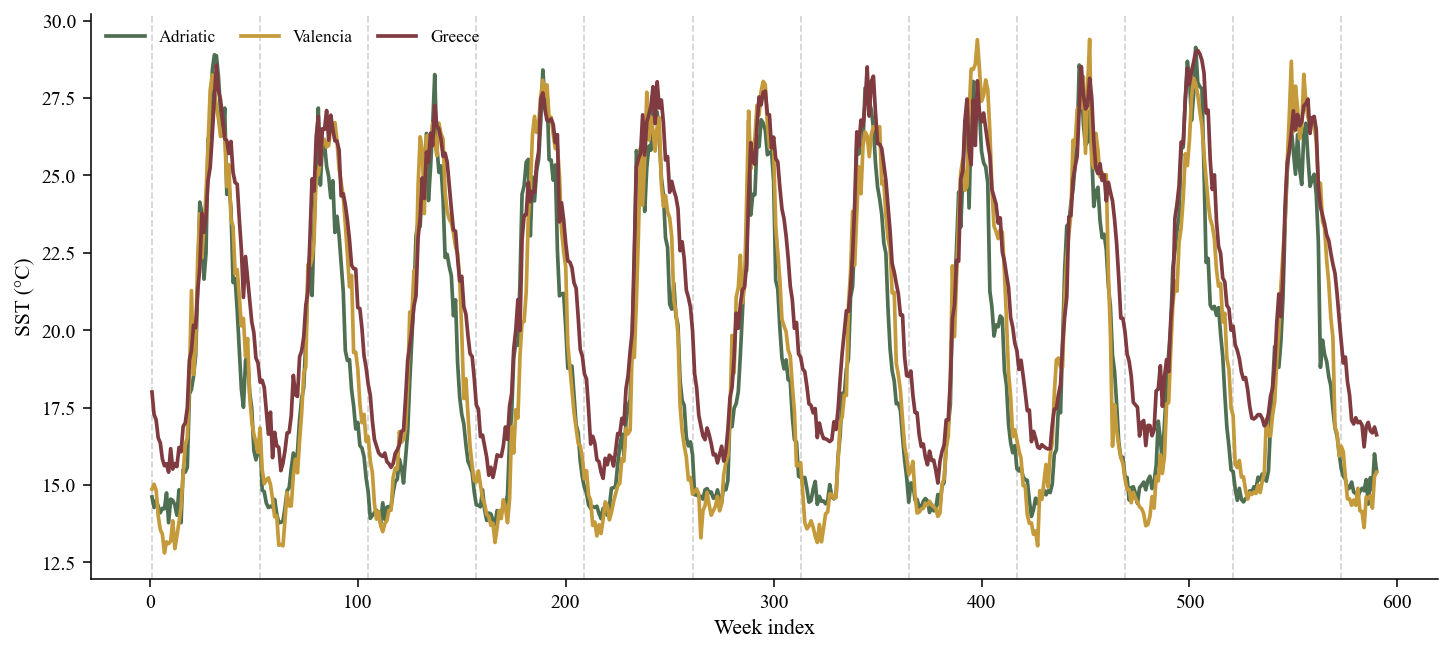

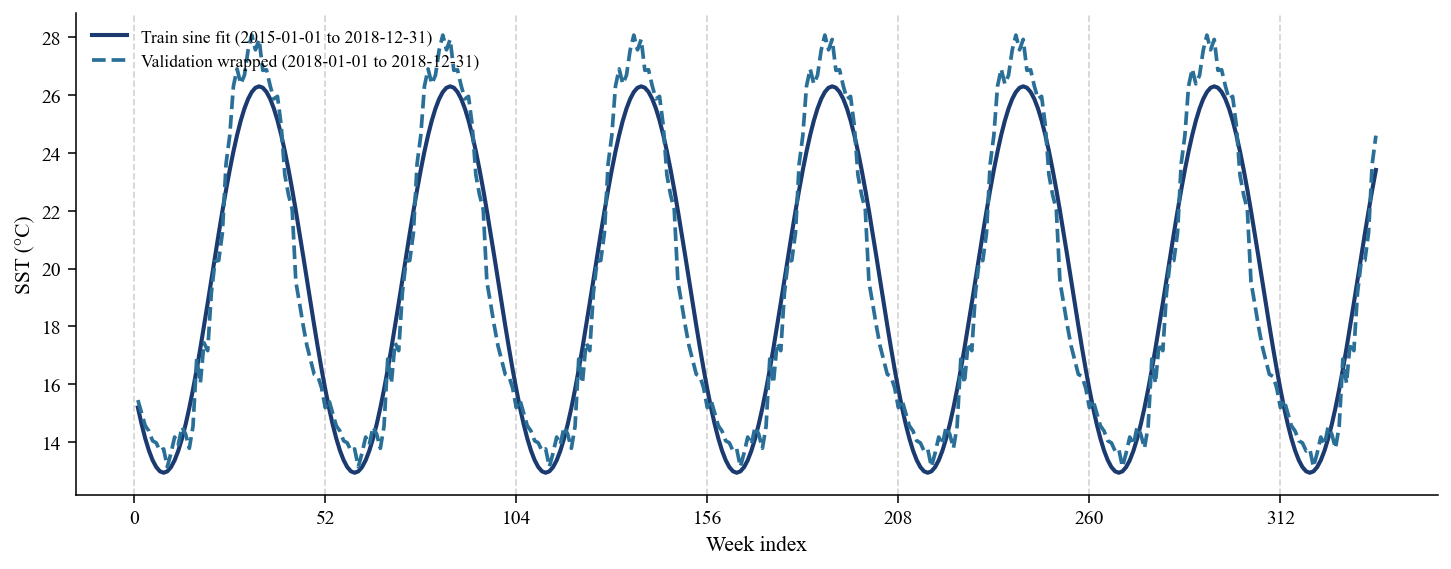

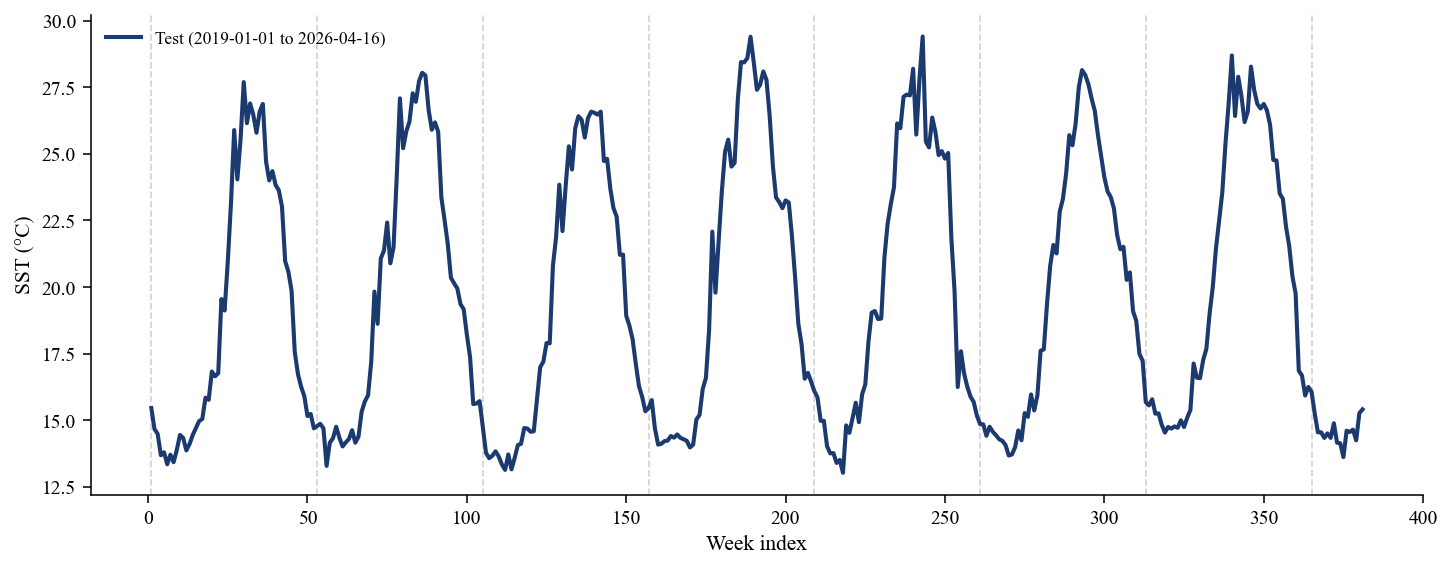

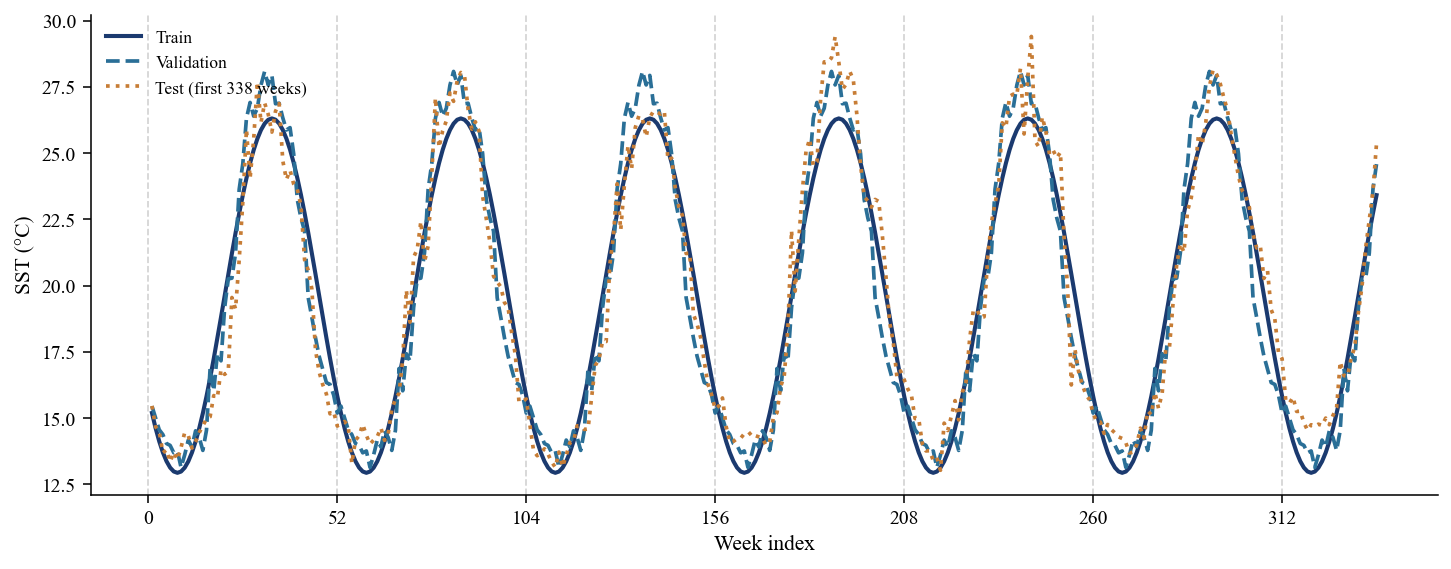

In [20]:
# ==========================================================
# CONFIG
# ==========================================================
REGIONS = ["Adriatico", "Valencia", "Grecia"]

# Select the desire region to train the model
chosen_region = "Valencia"  


chosen_feed_id = "121"
TEMP_CSV = "SST_3loc_weekly.csv"
SALE_PRICES_CSV = "sale_prices.csv"
FEED_RATES_CSV  = "feed_rates.csv"
FEED_PRICES_CSV = "feed_prices.csv"

# --- Temperature splits ---
# TRAIN FIT window: real data used only to estimate sine parameters
TRAIN_FIT_START, TRAIN_FIT_END = "2015-01-01", "2018-12-31"

# VAL base: 2018 data, wrapped/repeated until target length
VAL_START, VAL_END = "2018-01-01", "2018-12-31"

# TEST: real data from 2019 to end of series
TEST_START, TEST_END = "2019-01-01", "2026-04-16"

# Horizon / lengths
H_MAX = 286
START_WEEK_MAX = 52
TRAIN_WEEKS = START_WEEK_MAX + H_MAX   # 338
PERIOD_WEEKS = 52

# ==========================================================
# 1) LOAD DATA
# ==========================================================
df_temp = (
    pd.read_csv(TEMP_CSV, parse_dates=["date"])
      .sort_values("date")
      .reset_index(drop=True)
)

df_sale_prices = pd.read_csv(SALE_PRICES_CSV)
df_feed_rates  = pd.read_csv(FEED_RATES_CSV)
df_feed_prices = pd.read_csv(FEED_PRICES_CSV)

# Clean feed rate identifiers
if "id" not in df_feed_rates.columns:
    raise ValueError("df_feed_rates must contain column 'id' (feed identifier).")
df_feed_rates["id"] = df_feed_rates["id"].astype(str).str.strip()

# Validate region
if chosen_region not in REGIONS:
    raise ValueError(f"Región '{chosen_region}' no válida. Opciones: {REGIONS}")

missing = [c for c in ["date", "Week"] + REGIONS if c not in df_temp.columns]
if missing:
    raise ValueError(f"Faltan columnas en {TEMP_CSV}: {missing}")

print(
    f"[INFO] Loaded df_temp: {df_temp.shape} | "
    f"date range: {df_temp['date'].min().date()}..{df_temp['date'].max().date()}"
)

# ==========================================================
# 2) BUILD TRAIN / VAL / TEST TEMPERATURE ARRAYS (ALL REGIONS)
#     - TRAIN: smooth sine fitted on 2015–2018
#     - VAL  : real 2018 wrapped to 338 observations
#     - TEST : real 2019–2026 with no wrap
# ==========================================================
df_train_fit = df_temp[
    (df_temp["date"] >= TRAIN_FIT_START) & (df_temp["date"] <= TRAIN_FIT_END)
].copy()

df_val = df_temp[
    (df_temp["date"] >= VAL_START) & (df_temp["date"] <= VAL_END)
].copy()

df_test = df_temp[
    (df_temp["date"] >= TEST_START) & (df_temp["date"] <= TEST_END)
].copy()



def to_temp_array(vals_1d):
    """
    Convert a 1D temperature sequence into a two-column array:
    col0 = week index starting at 1
    col1 = temperature
    """
    vals_1d = np.asarray(vals_1d, dtype=float)
    return np.column_stack([
        np.arange(1, len(vals_1d) + 1, dtype=int),
        vals_1d
    ])


def wrap_to_length(values_1d, target_len):
    """
    Repeat a 1D array cyclically until target_len is reached.
    """
    values_1d = np.asarray(values_1d, dtype=float)

    if len(values_1d) == 0:
        raise ValueError("wrap_to_length recibió un array vacío.")

    reps = int(np.ceil(target_len / len(values_1d)))
    return np.tile(values_1d, reps)[:target_len]


def fit_annual_sine_weekly(t_vals, period_weeks=52):
    """
    Fit:
        T(w) = c + a*sin(ωw) + b*cos(ωw)
    and transform to:
        T(w) = Tm + A*sin(ω (w - phi))
    """
    t_vals = np.asarray(t_vals, dtype=float)
    n = len(t_vals)

    if n < 10:
        raise ValueError(f"Serie demasiado corta para ajuste sinusoidal: n={n}")

    w = np.arange(1, n + 1, dtype=float)
    omega = 2.0 * np.pi / float(period_weeks)

    X = np.column_stack([
        np.ones(n, dtype=float),
        np.sin(omega * w),
        np.cos(omega * w),
    ])

    beta, *_ = np.linalg.lstsq(X, t_vals, rcond=None)
    c, a, b = beta

    A = float(np.sqrt(a * a + b * b))
    delta = float(np.arctan2(b, a))
    phi = float((-delta) / omega)
    phi = phi % float(period_weeks)

    return float(c), A, phi


def build_smooth_seasonal_train(Tm, A, phi, n_weeks=338, period_weeks=52):
    """
    Build a deterministic weekly sinusoidal series:
        T(w) = Tm + A*sin(ω(w - phi))
    """
    w = np.arange(1, n_weeks + 1, dtype=float)
    omega = 2.0 * np.pi / float(period_weeks)
    T = Tm + A * np.sin(omega * (w - phi))

    return np.column_stack([
        w.astype(int),
        T.astype(float)
    ])


temperature_train_by_region = {}
temperature_val_by_region   = {}
temperature_test_by_region  = {}
SINE_PARAMS = {}

for region in REGIONS:
    # Real data used to fit sine parameters: 2015–2018
    t_train_fit = df_train_fit[region].astype(float).to_numpy()

    # Validation base: real 2018, then wrapped to TRAIN_WEEKS
    t_val = df_val[region].astype(float).to_numpy()

    # Test: real 2019–2026, no wrap
    t_test = df_test[region].astype(float).to_numpy()

    if len(t_train_fit) < 52:
        raise ValueError(f"[{region}] TRAIN_FIT too short (<52 values): {len(t_train_fit)}")
    if len(t_val) < 40:
        raise ValueError(f"[{region}] VAL too short: {len(t_val)}")
    if len(t_test) < 52:
        raise ValueError(f"[{region}] TEST too short (<52 values): {len(t_test)}")

    # Fit dominant annual seasonality from TRAIN_FIT (2015–2018)
    Tm, A, phi = fit_annual_sine_weekly(
        t_train_fit,
        period_weeks=PERIOD_WEEKS
    )
    SINE_PARAMS[region] = dict(Tm=Tm, A=A, phi=phi)

    # TRAIN: smooth seasonality only, length = 338
    temperature_train_by_region[region] = build_smooth_seasonal_train(
        Tm=Tm,
        A=A,
        phi=phi,
        n_weeks=TRAIN_WEEKS,
        period_weeks=PERIOD_WEEKS
    )

    # VAL: real 2018 wrapped to 338
    t_val_wrap = wrap_to_length(t_val, TRAIN_WEEKS)
    temperature_val_by_region[region] = to_temp_array(t_val_wrap)

    # TEST: real 2019–end, no wrap
    temperature_test_by_region[region] = to_temp_array(t_test)

print("\n[INFO] Sine parameters fitted from TRAIN_FIT (2015–2018):")
for r in REGIONS:
    p = SINE_PARAMS[r]
    print(f"  {r:10s} | Tm={p['Tm']:.2f} | A={p['A']:.2f} | phi={p['phi']:.2f} weeks")

temperature_train = temperature_train_by_region[chosen_region]  # (338, 2)
temperature_val   = temperature_val_by_region[chosen_region]    # (338, 2)
temperature_test  = temperature_test_by_region[chosen_region]   # (N, 2)

print(f"\n[INFO] Using chosen_region='{chosen_region}':")
print(f"  temperature_train: {temperature_train.shape} | Weeks 1..{int(temperature_train[-1, 0])}")
print(f"  temperature_val  : {temperature_val.shape}   | Weeks 1..{int(temperature_val[-1, 0])}")
print(f"  temperature_test : {temperature_test.shape}  | Weeks 1..{int(temperature_test[-1, 0])}")

# ==========================================================
# 3) OTHER DATASETS -> NUMPY + FIXED PRICES
# ==========================================================
sale_prices = df_sale_prices.to_numpy()
feed_rates  = df_feed_rates.to_numpy()
feed_prices = df_feed_prices.to_numpy()

# Strong dtype normalization
sale_prices[:, 0] = sale_prices[:, 0].astype(int)
sale_prices[:, 1:] = sale_prices[:, 1:].astype(float)

feed_prices[:, 0] = feed_prices[:, 0].astype(int)
feed_prices[:, 1:] = feed_prices[:, 1:].astype(float)

feed_rates[:, 0] = feed_rates[:, 0].astype(str)

# Fixed prices
fixed_sale_prices = sale_prices[:, 1:].mean(axis=0).astype(float)
fixed_sale_prices = np.round(fixed_sale_prices, 1)

fixed_feed_prices = feed_prices[0, 1:].astype(float)
fixed_feed_prices = np.round(fixed_feed_prices, 1)

print("\n[INFO] Fixed sale prices (€/kg):", fixed_sale_prices)
print("[INFO] Fixed feed prices (€/kg):", fixed_feed_prices)

# Feed rates for the chosen feed
chosen_feed_rates = feed_rates[feed_rates[:, 0] == str(chosen_feed_id)]
if chosen_feed_rates.size == 0:
    raise ValueError(f"No feed_rates rows found for chosen_feed_id='{chosen_feed_id}'.")

# ==========================================================
# JOURNAL-STYLE CONFIGURATION
# ==========================================================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.9,
    "legend.frameon": False,
})

# ==========================================================
# COLOR PALETTE
# ==========================================================
REGION_COLORS = {
    "Canarias":  "#1F4E79",
    "Valencia":  "#C49A3A",
    "Grecia":    "#7F3B3F",
    "Adriatico": "#4F6F52",
}

MAIN_COLOR = "#1B3A6F"
SECOND_COLOR = "#2A6F97"
THIRD_COLOR = "#C77D36"
YEAR_MARK_COLOR = "#b8b8b8"

# ==========================================================
# STYLE HELPERS
# ==========================================================
def style_axes(ax):
    """Clean scientific journal style."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", length=4, width=0.8)
    return ax


def add_year_dividers(ax, start, end, step=52):
    """Add vertical dashed lines every 52 weeks."""
    for x in range(start, end + 1, step):
        ax.axvline(
            x=x,
            color=YEAR_MARK_COLOR,
            linestyle="--",
            linewidth=0.9,
            alpha=0.6,
            zorder=0
        )

# ==========================================================
# 4) PLOTS
# ==========================================================
REGION_TRANSLATION = {
    "Canarias": "Canary Islands",
    "Valencia": "Valencia",
    "Adriatico": "Adriatic",
    "Grecia": "Greece"
}

# 4.1) Full historical overview for the four regions
fig, ax = plt.subplots(figsize=(10.5, 4.8))

for r in REGIONS:
    ax.plot(
        df_temp["Week"],
        df_temp[r].astype(float),
        label=REGION_TRANSLATION.get(r, r),
        color=REGION_COLORS.get(r, None),
        linewidth=1.9
    )

add_year_dividers(ax, int(df_temp["Week"].min()), int(df_temp["Week"].max()))

ax.set_xlabel("Week index")
ax.set_ylabel("SST (°C)")
style_axes(ax)

ax.legend(
    loc="upper left",
    ncol=4,
    handlelength=2.2,
    columnspacing=1.4
)

plt.tight_layout()
plt.show()

# 4.2) Chosen region: TRAIN (smooth sine) vs VAL (wrapped 2018)
fig, ax = plt.subplots(figsize=(10.5, 4.2))

ax.plot(
    temperature_train[:, 0],
    temperature_train[:, 1],
    label=f"Train sine fit ({TRAIN_FIT_START} to {TRAIN_FIT_END})",
    color=MAIN_COLOR,
    linewidth=2.1
)

ax.plot(
    temperature_val[:, 0],
    temperature_val[:, 1],
    label=f"Validation wrapped ({VAL_START} to {VAL_END})",
    color=SECOND_COLOR,
    linewidth=1.9,
    linestyle="--"
)

add_year_dividers(ax, 0, TRAIN_WEEKS)
ax.set_xticks(np.arange(0, TRAIN_WEEKS + 1, 52))

ax.set_xlabel("Week index")
ax.set_ylabel("SST (°C)")
style_axes(ax)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# 4.3) Chosen region: TEST real
fig, ax = plt.subplots(figsize=(10.5, 4.2))

ax.plot(
    temperature_test[:, 0],
    temperature_test[:, 1],
    label=f"Test ({TEST_START} to {TEST_END})",
    color=MAIN_COLOR,
    linewidth=2.1
)

add_year_dividers(
    ax,
    int(temperature_test[:, 0].min()),
    int(temperature_test[:, 0].max())
)

ax.set_xlabel("Week index")
ax.set_ylabel("SST (°C)")
style_axes(ax)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# 4.4) Visual alignment using the first TRAIN_WEEKS of TEST
n = min(TRAIN_WEEKS, len(temperature_test))

fig, ax = plt.subplots(figsize=(10.5, 4.2))

ax.plot(
    temperature_train[:, 0],
    temperature_train[:, 1],
    label="Train",
    color=MAIN_COLOR,
    linewidth=2.1
)

ax.plot(
    temperature_val[:, 0],
    temperature_val[:, 1],
    label="Validation",
    color=SECOND_COLOR,
    linewidth=1.9,
    linestyle="--"
)

ax.plot(
    temperature_test[:n, 0],
    temperature_test[:n, 1],
    label=f"Test (first {n} weeks)",
    color=THIRD_COLOR,
    linewidth=1.9,
    linestyle=":"
)

add_year_dividers(ax, 0, TRAIN_WEEKS)
ax.set_xticks(np.arange(0, TRAIN_WEEKS + 1, 52))

ax.set_xlabel("Week index")
ax.set_ylabel("SST (°C)")
style_axes(ax)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# **Aquaculture Environment Definition**

This class defines the aquaculture production environment used by the reinforcement learning agent. It combines the biological growth model, feed consumption, mortality, economic reward calculation, and the standard Gym interaction interface.

The problem is formulated as a sequential decision process where the agent chooses the duration of each production lot. For each selected duration, the environment simulates fish growth, feeding requirements, survival, and final economic return.

The class contains the following main methods:

* **`__init__`**  
  Initializes the environment with temperature data, feed-rate tables, sale prices, feed prices, and fixed economic parameters. It also defines the discrete action space, where each action represents a possible lot duration, and the observation space, which includes temporal and environmental information.

* **`reset`**  
  Starts a new episode by setting the planning horizon, current planning week, remaining weeks, and starting week of the year. The horizon and initial week can be either fixed or randomly sampled. The method returns the initial observation and action mask.

* **`step`**  
  Executes the selected action, interpreted as the number of weeks assigned to the next lot. The full lot is biologically simulated, even if it extends beyond the remaining planning horizon. In that case, the reward is scaled according to the fraction of the lot that lies within the visible horizon, while the internal clock only advances by the visible number of weeks.

* **`action_masks`**  
  Returns the set of valid actions. In this implementation, all lot durations are always allowed, since horizon feasibility is handled inside `step` through reward scaling rather than action masking.

* **`_get_observation`**  
  Builds the observation vector. The state includes a sine/cosine encoding of the current week of the year, the normalized remaining planning horizon, and the normalized SST values for the next six weeks. This provides the agent with compact temporal and short-term environmental information.

* **`_simulate_growth_helper`**  
  Simulates lot evolution week by week. For each week, the method reads the SST value, selects the applicable feed-rate row according to temperature and fish weight, applies Mixed-TGC growth, accumulates feed consumption, and updates survival. The simulation can stop early if the temperature series ends, the population becomes extinct, or the maximum lot weight is reached.

* **`_compute_reward`**  
  Computes the economic reward as net profit, defined as sales income minus feed cost. Sales income depends on the final fish weight category, while feed cost is calculated from total feed consumption and fixed feed prices. The profit is scaled and clipped to ensure a non-negative reinforcement signal.

In [21]:
class AquacultureEnv(gym.Env):
    def __init__(
        self,
        temperature_data,
        feed_rates_data,
        sale_prices_data,
        feed_prices_data,
        fixed_sale_prices,
        fixed_feed_prices,
        max_weeks=None,
        start_local_week=None,
        max_seeding=78,
        initial_fish_weight=30,
        initial_population=7100,
        chosen_feed_id="121",
        max_lot_weight_g=1000.0,
    ):
        """
        Initialize the aquaculture production planning environment.

        The constructor loads the environmental, biological, and economic
        datasets required for the simulation, defines the action and observation
        spaces, and stores the main parameters governing the production system.

        :param temperature_data: Weekly temperature series used during the simulation
                                 with format [week_index, temperature].
        :type temperature_data: numpy.ndarray

        :param feed_rates_data: Technical table containing feeding rate, mortality,
                                and weight ranges as a function of temperature.
        :type feed_rates_data: numpy.ndarray

        :param sale_prices_data: Historical sale price dataset by fish size category.
        :type sale_prices_data: numpy.ndarray

        :param feed_prices_data: Dataset containing feed price information.
        :type feed_prices_data: numpy.ndarray

        :param fixed_sale_prices: Fixed sale prices (€/kg) used for reward computation.
        :type fixed_sale_prices: numpy.ndarray

        :param fixed_feed_prices: Fixed feed prices (€/kg) used for feed cost calculation.
        :type fixed_feed_prices: numpy.ndarray

        :param max_weeks: Planning horizon of the episode. If None, it will be sampled
                          during reset.
        :type max_weeks: int or None

        :param start_local_week: Initial week of the year (1–52). If None, it will be
                                 sampled randomly during reset.
        :type start_local_week: int or None

        :param max_seeding: Maximum seeding duration (number of weeks available as actions).
        :type max_seeding: int

        :param initial_fish_weight: Initial fish weight in grams.
        :type initial_fish_weight: float

        :param initial_population: Initial number of fish in the lot.
        :type initial_population: float

        :param chosen_feed_id: Identifier of the feed type used in the simulation.
        :type chosen_feed_id: str

        :param max_lot_weight_g: Maximum allowed fish weight for the lot. If this
                                   threshold is reached before the chosen duration ends,
                                   the lot is stopped early.
        :type max_lot_weight_g: float
        """

        super().__init__()

        # store input datasets
        self.temperature_data = temperature_data
        self.feed_rates_data = feed_rates_data
        self.sale_prices_data = sale_prices_data
        self.feed_prices_data = feed_prices_data

        # store fixed economic parameters
        self.fixed_sale_prices = np.asarray(fixed_sale_prices, dtype=np.float32)
        self.fixed_feed_prices = np.asarray(fixed_feed_prices, dtype=np.float32)

        # compute temperature range for normalization
        self.n_weeks_temp = int(self.temperature_data.shape[0])
        temp_vals = self.temperature_data[:, 1].astype(float)
        self.temp_min = float(temp_vals.min())
        self.temp_max = float(temp_vals.max())

        # store biological and planning parameters
        self.chosen_feed_id = chosen_feed_id
        self.chosen_feed_rates = self.feed_rates_data[self.feed_rates_data[:, 0] == self.chosen_feed_id]

        self.start_local_week_config = start_local_week
        self.start_local_week = None
        self.fixed_max_weeks = max_weeks

        self.max_seeding = int(max_seeding)
        self.initial_fish_weight = float(initial_fish_weight)
        self.initial_population = float(initial_population)
        self.max_lot_weight_g = float(max_lot_weight_g)

        # define action space (seeding duration)
        self.action_space = spaces.Discrete(self.max_seeding)

        # define observation space
        self.observation_space = spaces.Dict({
            "obs": spaces.Box(low=-1.0, high=1.0, shape=(9,), dtype=np.float32),
            "action_mask": spaces.MultiBinary(int(self.action_space.n)),
        })

    def reset(self, seed=None, options=None):
        """
        Reset the environment to start a new episode.

        This method initializes the planning state by defining:
        - episode planning horizon (max_weeks),
        - current planning time index (current_planning_week),
        - remaining weeks in the episode (remaining_weeks),
        - starting week of the year (start_local_week, 1–52).

        :param seed: Random seed used to make the reset stochasticity reproducible.
        :type seed: int or None

        :param options: Optional Gym API argument (unused).
        :type options: dict or None

        :return: A tuple (obs_dict, info) where obs_dict contains the observation vector
                 and the action mask for valid actions, and info is an empty dict.
        :rtype: tuple[dict[str, numpy.ndarray], dict]
        """

        # call Gym reset to register the seed in the base class
        super().reset(seed=seed)

        # set the episode horizon: fixed if provided, otherwise sampled from {104, 117, ..., 208}
        self.max_weeks = (
            int(self.fixed_max_weeks)
            if self.fixed_max_weeks is not None
            else int(self.np_random.choice(np.arange(104, 209, 13)))
        )

        # initialize planning counters
        self.current_planning_week = 0
        self.remaining_weeks = self.max_weeks

        # set the starting local week (1–52): fixed if provided, otherwise sampled uniformly
        self.start_local_week = (
            int(self.start_local_week_config)
            if self.start_local_week_config is not None
            else int(self.np_random.integers(1, 53))
        )

        # build initial observation and action mask
        obs = self._get_observation()
        mask = self.action_masks()

        # return observation dict and empty info dict (Gym API)
        return {"obs": obs, "action_mask": mask}, {}


    def step(self, action):
        """
        Execute one environment step by applying the agent's discrete action
        (lot duration in weeks).

        Horizon logic:
        - every action in [1, max_seeding] is always allowed,
        - the FULL chosen lot is simulated even if it exceeds the remaining
          visible planning horizon,
        - if the executed lot extends beyond the remaining visible horizon,
          the reward is scaled proportionally by:
                remaining_weeks_before / weeks_chosen
        - the internal episode clock only advances by the visible part inside
          the planning horizon.

        :param action: Discrete action in [0, max_seeding - 1], representing
                       weeks_chosen = action + 1.
        :type action: int

        :return: A tuple (obs_dict, reward, done, truncated, info) following the Gym API.
                 obs_dict contains {"obs": obs, "action_mask": mask}.
        :rtype: tuple[dict[str, numpy.ndarray], float, bool, bool, dict]
        """

        # validate that the action is within the discrete action space
        if not (0 <= int(action) < self.action_space.n):
            raise ValueError(f"Invalid action: {action}. Allowed range: 0..{self.action_space.n - 1}")

        # decode action to an actual lot duration in weeks
        weeks_chosen = int(action) + 1

        # store remaining visible horizon BEFORE simulating the lot
        remaining_before = int(self.remaining_weeks)

        # if no horizon remains, terminate consistently
        if remaining_before <= 0:
            obs = self._get_observation()
            mask = self.action_masks()
            return {
                "obs": obs,
                "action_mask": mask,
            }, 0.0, True, False, {
                "weeks_chosen": int(weeks_chosen),
                "weeks_executed": 0,
                "visible_weeks": 0,
                "was_truncated_by_horizon": False,
                "was_truncated_by_weight": False,
                "reward_full_scaled": 0.0,
                "reward_fraction_applied": 0.0,
                "final_fish_weight_g": float(self.initial_fish_weight),
                "max_lot_weight_g": float(self.max_lot_weight_g),
            }

        # compute the "natural" start week index in the temperature series (1-indexed)
        start_week_natural = int(self.start_local_week + self.current_planning_week)

        # simulate the FULL chosen block, ignoring the planning horizon
        fish_weight, total_food_used, current_population, _, weeks_executed = self._simulate_growth_helper(
            chosen_feed_rates=self.chosen_feed_rates,
            temperature=self.temperature_data,
            initial_weight=self.initial_fish_weight,
            initial_population=self.initial_population,
            start_week_natural=start_week_natural,
            num_sowing_weeks=weeks_chosen,
            current_planning_week=self.current_planning_week,
            enforce_planning_horizon=False,
        )

        # compute the FULL economic reward of the simulated block
        reward_full = self._compute_reward(
            fish_weight=fish_weight,
            total_food_used=total_food_used,
            current_population=current_population,
            start_week=start_week_natural,
            feed_prices=self.feed_prices_data,
        )

        # visible part of the block inside the remaining planning horizon
        visible_weeks = min(int(weeks_executed), remaining_before)

        # horizon truncation occurs only if the ACTUALLY executed block extends
        # beyond the remaining visible horizon
        was_truncated_by_horizon = bool(int(weeks_executed) > remaining_before)

        # apply proportional reward only for horizon-truncated blocks
        if was_truncated_by_horizon:
            reward_fraction = float(remaining_before / weeks_chosen)
            reward = float(reward_full) * reward_fraction
        else:
            reward_fraction = 1.0
            reward = float(reward_full)

        # advance only the visible part inside the episode horizon
        self.current_planning_week += int(visible_weeks)
        self.remaining_weeks = max(0, int(self.max_weeks - self.current_planning_week))

        # terminate the episode when the planning horizon is reached or exceeded
        done = (self.remaining_weeks <= 0) or (self.current_planning_week >= self.max_weeks)

        # build next observation and corresponding action mask
        obs = self._get_observation()
        mask = self.action_masks()

        return {
            "obs": obs,
            "action_mask": mask,
        }, float(reward), bool(done), False, {
            "weeks_chosen": int(weeks_chosen),
            "weeks_executed": int(weeks_executed),      # full simulated block
            "visible_weeks": int(visible_weeks),        # part counted inside horizon
            "was_truncated_by_horizon": bool(was_truncated_by_horizon),
            "was_truncated_by_weight": bool(weeks_executed < weeks_chosen),
            "reward_full_scaled": float(reward_full),
            "reward_fraction_applied": float(reward_fraction),
            "final_fish_weight_g": float(fish_weight),
            "max_lot_weight_g": float(self.max_lot_weight_g),
        }


    def action_masks(self):
        """
        Build the binary mask of valid actions at the current environment state.

        In this case all actions are always allowed. The planning horizon is not enforced
        through masking anymore; it is handled inside step() by simulating the
        full chosen lot and, when necessary, scaling the reward proportionally
        for the part of the lot that lies inside the remaining visible horizon.

        :return: Boolean vector of shape (n_actions,) where True indicates that the
                 action is allowed.
        :rtype: numpy.ndarray
        """
        return np.ones(self.action_space.n, dtype=bool)


    def _get_observation(self):
        """
        Observation:
        1) sin/cos encoding of week
        2) remaining weeks
        3) temperatures of next 6 weeks (including current), normalized [-1,1]
        """

        # --- Week handling ---
        local_week = int(self.start_local_week + self.current_planning_week)
        week_global = min(local_week, self.n_weeks_temp)

        idx_est = (week_global - 1) % 52
        sin_week = float(np.sin(2.0 * np.pi * (idx_est / 52.0)))
        cos_week = float(np.cos(2.0 * np.pi * (idx_est / 52.0)))

        # --- Remaining horizon ---
        remaining_weeks_norm = float(2.0 * (self.remaining_weeks / self.max_weeks) - 1.0)
        remaining_weeks_norm = float(np.clip(remaining_weeks_norm, -1.0, 1.0))

        # --- Future temperatures (6 weeks) ---
        start_idx = max(0, week_global - 1)

        temps = []
        for i in range(6):
            idx = start_idx + i
            if idx >= self.n_weeks_temp:
                # si se sale del dataset → repetir último valor
                temp_val = float(self.temperature_data[-1, 1])
            else:
                temp_val = float(self.temperature_data[idx, 1])
            temps.append(temp_val)

        temps = np.array(temps, dtype=float)

        # --- Normalize temperatures to [-1, 1] ---
        if self.temp_max > self.temp_min:
            temps_norm = 2.0 * ((temps - self.temp_min) / (self.temp_max - self.temp_min)) - 1.0
        else:
            temps_norm = np.zeros_like(temps)

        temps_norm = np.clip(temps_norm, -1.0, 1.0)

        # --- Final observation ---
        return np.concatenate([
            np.array([sin_week, cos_week, remaining_weeks_norm], dtype=np.float32),
            temps_norm.astype(np.float32)
        ])

    def _simulate_growth_helper(
        self,
        chosen_feed_rates,
        temperature,
        initial_weight,
        initial_population,
        start_week_natural,
        num_sowing_weeks,
        current_planning_week,
        enforce_planning_horizon=False,
    ):
        """
        Simulate lot growth, feed consumption, and mortality over a given number of weeks.

        The simulation evolves the lot week-by-week. Each week:
        - the weekly temperature is read from the temperature series,
        - an applicable row in the feed-rate table is selected based on (temperature, fish_weight),
        - daily weight growth is applied using a Mixed-TGC formulation,
        - feed consumption is accumulated,
        - weekly survival is applied using the mortality rate from the table.

        The simulation stops early if:
        - the planning horizon is exceeded AND enforce_planning_horizon=True,
        - the temperature series ends,
        - the maximum lot weight threshold is reached.

        :param chosen_feed_rates: Filtered feed-rate table for the selected feed id.
                                 Expected columns include temperature bounds, weight bounds,
                                 feeding rate, and mortality rate.
        :type chosen_feed_rates: numpy.ndarray

        :param temperature: Weekly temperature series with format [week_index, temperature].
        :type temperature: numpy.ndarray

        :param initial_weight: Initial fish weight in grams.
        :type initial_weight: float

        :param initial_population: Initial number of fish in the lot.
        :type initial_population: float

        :param start_week_natural: Natural start week index in the temperature series (1-indexed).
        :type start_week_natural: int

        :param num_sowing_weeks: Requested number of weeks to simulate (lot duration).
        :type num_sowing_weeks: int

        :param current_planning_week: Current planning time index within the episode horizon.
        :type current_planning_week: int

        :param enforce_planning_horizon: If True, stop the simulation when the planning horizon
                                         is reached. If False, ignore the episode horizon and
                                         simulate the full chosen lot subject only to biological
                                         and data limits.
        :type enforce_planning_horizon: bool

        :return: Tuple with final fish weight (g), total feed used (g), final population (fish),
                 the natural week index (1-indexed) reached at the end of the simulation,
                 and the number of weeks actually executed.
        :rtype: tuple[float, float, float, int, int]
        """

        # Mixed-TGC growth parameters
        TGC_1_3 = 0.001646
        TGC_2_3 = 0.016095
        critic_weight = 117.0
        temp_umbral = 12.0

        # initialize lot state
        fish_weight = float(initial_weight)
        current_population = float(initial_population)
        total_food_used = 0.0
        week = int(start_week_natural)
        weeks_executed = 0

        # extract technical table vectors
        temp_min = chosen_feed_rates[:, 1].astype(float)
        temp_max = chosen_feed_rates[:, 2].astype(float)
        weight_min = chosen_feed_rates[:, 3].astype(float)
        weight_max = chosen_feed_rates[:, 4].astype(float)
        feeding_rate = chosen_feed_rates[:, 5].astype(float)
        death_rate = chosen_feed_rates[:, 7].astype(float)

        # number of available temperature weeks
        n_temp = int(temperature.shape[0])

        # simulate week-by-week for the requested lot duration
        for _ in range(int(num_sowing_weeks)):

            # compute how many weeks have elapsed since the lot start (natural time)
            weeks_passed = week - int(start_week_natural)

            # map elapsed natural weeks to the planning week index within the episode
            plan_week = int(current_planning_week) + weeks_passed

            # optionally stop if the planning horizon is reached
            if enforce_planning_horizon and plan_week >= int(self.max_weeks):
                break

            # stop if temperature data is exhausted (week is 1-indexed)
            if week > n_temp:
                break

            # read weekly temperature
            temp_val = float(temperature[week - 1, 1])

            # select the first applicable feed-rate row matching (temperature, weight)
            cond = (
                (temp_min <= temp_val) & (temp_val <= temp_max) &
                (weight_min <= fish_weight) & (fish_weight <= weight_max)
            )

            if np.any(cond):
                idx = int(np.nonzero(cond)[0][0])

                # convert daily feeding rate (%) to an approximate weekly fraction
                frate_week = (feeding_rate[idx] / 100.0) * 7.0

                # convert daily mortality (%) to weekly survival probability
                surv_week = (1.0 - death_rate[idx] / 100.0) ** 7.0
            else:
                # if no technical row applies, assume no feeding and no mortality
                frate_week = 0.0
                surv_week = 1.0

            # apply daily growth and feed consumption over 7 days
            for _day in range(7):

                # apply growth only above the temperature threshold
                if temp_val > temp_umbral:

                    # choose Mixed-TGC regime depending on the current weight
                    if fish_weight < critic_weight:
                        b = 1.0 / 3.0
                        TGC = TGC_1_3
                    else:
                        b = 2.0 / 3.0
                        TGC = TGC_2_3

                    # update fish weight (Mixed-TGC formulation)
                    fish_weight = (fish_weight ** b + TGC * (temp_val - temp_umbral)) ** (1.0 / b)

                # accumulate daily feed consumption (weekly fraction divided by 7)
                total_food_used += (frate_week / 7.0) * fish_weight * current_population

            # apply weekly survival (mortality)
            current_population *= surv_week

            # count the week as executed once growth, feeding, and mortality have been applied
            weeks_executed += 1

            # stop if the lot is extinct
            if current_population <= 0.0:
                current_population = 0.0
                week += 1
                break

            # stop if the maximum lot weight threshold is reached
            if fish_weight >= self.max_lot_weight_g:
                week += 1
                break

            # advance to the next natural week
            week += 1

        # return final lot state, the ending week index, and executed duration
        return fish_weight, total_food_used, current_population, week, weeks_executed


    def _compute_reward(
        self,
        fish_weight,
        total_food_used,
        current_population,
        start_week,
        feed_prices,
    ):
        """
        Compute the economic reward of a lot at the end of the simulated duration.

        The reward is defined as net profit:
            profit = income_from_sales - feed_cost

        Current assumptions:
        - Sale price is fixed and depends only on the final fish weight category:
            * 300–400 g, 400–600 g, 600+ g
          If fish_weight < 300 g, income is zero (non-commercial).
        - Feed price is fixed and taken from ``self.fixed_feed_prices[0]``.
        - ``total_food_used`` is provided in grams and is converted to kilograms for costing.

        :param fish_weight: Final fish weight in grams.
        :type fish_weight: float

        :param total_food_used: Total feed consumed during the lot in grams.
        :type total_food_used: float

        :param current_population: Final number of fish at harvest time.
        :type current_population: float

        :param start_week: Natural start week index. Unused in the fixed-price setting.
        :type start_week: int

        :param feed_prices: Feed price dataset. Unused in the fixed-price setting.
        :type feed_prices: numpy.ndarray

        :return: Non-negative scaled net profit (profit / 1000).
        :rtype: float
        """

        # Compute sales income only if the lot reaches commercial size
        if fish_weight < 300.0:
            income = 0.0
        else:
            # Select the fixed sale price according to the final weight category
            if fish_weight < 400.0:
                sales_price = float(self.fixed_sale_prices[0])
            elif fish_weight < 600.0:
                sales_price = float(self.fixed_sale_prices[1])
            else:
                sales_price = float(self.fixed_sale_prices[2])

            # Compute harvest biomass in kg and corresponding sales income
            biomass_kg = current_population * (fish_weight / 1000.0)
            income = biomass_kg * sales_price

        # Compute feed cost using the fixed feed price (€/kg)
        feed_price = float(self.fixed_feed_prices[0])
        cost = (total_food_used / 1000.0) * feed_price

        # Net profit, scaled for numerical stability
        profit = income - cost
        return max(0.0, float(profit / 1000.0))

# **Hyperparameter Optimization with Optuna**

This section performs hyperparameter optimization of the `MaskablePPO` agent using `Optuna`. The objective is to maximize the **mean deterministic validation return**.

The optimized hyperparameters are:

- `learning_rate`
- `gamma`
- `gae_lambda`
- `clip_range`
- `ent_coef`
- `vf_coef`

The remaining training parameters are fixed to match the final protocol, with `n_steps = 256`, `batch_size = 256`, and `net_arch = [512, 512]`.

Each trial trains the agent using **four parallel training environments** with the training temperature series, a fixed planning horizon of **208 weeks**, stochastic starting weeks, and a maximum lot weight of **1000 g**. All actions remain valid at every step; horizon feasibility is handled inside the environment through full-lot simulation and proportional reward scaling.

After training, the policy is evaluated deterministically on the validation temperature series. The evaluation runs one episode for each starting week from **1 to 52**, using a fixed horizon of **208 weeks** and the same environment dynamics as in training.

The final objective value is the **average validation return across all starting weeks**, providing a robust measure of policy performance over the annual cycle. The search is run for **50 trials** using a `TPESampler` and a `HyperbandPruner`.

In [ ]:
# 0) GLOBAL SETTINGS
N_ENVS = 4
TOTAL_TIMESTEPS = 200_000
EVAL_START_WEEKS = list(range(1, 53))
EVAL_MAX_WEEKS = 208

# Constant base seed to reduce between-trial noise while still allowing reproducibility
BASE_SEED = 123

# Fixed training setup to match the final training protocol
TRAIN_ENV_WEIGHT_CAPS = [1000.0, 1000.0, 1000.0, 1000.0]

# Fixed validation setup to match the final training protocol
VAL_MAX_LOT_WEIGHT_G = 1000.0


# 1) REPRODUCIBILITY HELPER
def set_global_seed(seed):
    """
    Set global random seeds to improve experiment reproducibility.

    This function initializes the random number generators used by
    Python, NumPy, and PyTorch. It also configures CUDA/CuDNN to use
    deterministic implementations when available, reducing variability
    across runs.

    :param seed: Seed value used to initialize all random generators.
    :type seed: int

    :return: None
    :rtype: None
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# 2) MASK + ENV FACTORIES (TRAIN vs VAL)
def mask_fn(env):
    """
    Return the action mask associated with the current environment state.

    With the current environment logic, all actions are always allowed.
    This function is kept because MaskablePPO / ActionMasker are still used.

    :param env: Environment instance providing the action mask.
    :type env: gym.Env

    :return: Boolean vector indicating valid actions.
    :rtype: numpy.ndarray
    """
    return env.action_masks()


def make_env_train(rank, seed):
    """
    Create a factory function that builds a training environment instance.

    The returned callable is used by vectorized environments (e.g., DummyVecEnv)
    to create multiple independent training environments. Each environment uses
    the training temperature series and fixed episode conditions matching the
    final training protocol.

    In this setup, each parallel environment is assigned:
    - a stochastic start week (start_local_week=None)
    - a fixed planning horizon of 208 weeks
    - a fixed maximum lot weight threshold from TRAIN_ENV_WEIGHT_CAPS

    The planning horizon is NOT enforced through masking anymore.
    Instead, the full chosen lot is simulated inside env.step(), and if the
    lot exceeds the remaining visible horizon, the reward is scaled
    proportionally there.

    :param rank: Index of the environment instance in the vectorized setup.
    :type rank: int

    :param seed: Base random seed used to initialize the environment.
    :type seed: int

    :return: Callable that creates and returns a fully wrapped training environment.
    :rtype: Callable[[], gym.Env]
    """

    def _init():
        # create the base aquaculture environment using the training temperature data
        env = AquacultureEnv(
            temperature_data=temperature_train,
            feed_rates_data=feed_rates,
            sale_prices_data=sale_prices,
            feed_prices_data=feed_prices,
            fixed_sale_prices=fixed_sale_prices,
            fixed_feed_prices=fixed_feed_prices,
            max_weeks=208,                    # fixed training horizon
            start_local_week=None,            # stochastic start week during training
            max_seeding=78,
            initial_fish_weight=30,
            initial_population=7100,
            chosen_feed_id=chosen_feed_id,
            max_lot_weight_g=float(TRAIN_ENV_WEIGHT_CAPS[rank]),
        )

        # wrap the environment with an action masker
        env = ActionMasker(env, mask_fn)

        # wrap with Monitor to record episode statistics (reward, length)
        env = Monitor(env)

        # perform an initial reset with a seed specific to this environment instance
        env.reset(seed=seed + rank)

        return env

    # return the factory function used by DummyVecEnv
    return _init


def make_env_val(seed):
    """
    Create the validation environment used for deterministic policy evaluation.

    The environment uses the validation temperature dataset and a fixed
    planning horizon. During evaluation, the starting week will be manually
    overwritten in each episode through `start_local_week_config` before reset.

    Validation uses the SAME logic as the final training code:
    - any action can be chosen,
    - the full chosen lot is simulated,
    - if the lot exceeds the remaining visible horizon, the reward is scaled
      proportionally inside env.step().

    Validation uses a fixed maximum lot weight threshold of 1000 g. If the
    fish reach that threshold before the chosen lot duration ends, the lot
    is stopped early.

    :param seed: Random seed used to initialize the environment.
    :type seed: int

    :return: Wrapped validation environment ready for evaluation.
    :rtype: gym.Env
    """

    # create the base environment using validation temperature data
    env = AquacultureEnv(
        temperature_data=temperature_val,
        feed_rates_data=feed_rates,
        sale_prices_data=sale_prices,
        feed_prices_data=feed_prices,
        fixed_sale_prices=fixed_sale_prices,
        fixed_feed_prices=fixed_feed_prices,
        max_weeks=208,                    # fixed evaluation horizon
        start_local_week=1,               # placeholder start week (overwritten later)
        max_seeding=78,
        initial_fish_weight=30,
        initial_population=7100,
        chosen_feed_id=chosen_feed_id,
        max_lot_weight_g=float(VAL_MAX_LOT_WEIGHT_G),
    )

    # apply the same wrappers used during training
    env = ActionMasker(env, mask_fn)
    env = Monitor(env)

    # initialize the environment with a fixed evaluation seed
    env.reset(seed=seed)

    return env


# 3) OFF-POLICY HELPERS FOR GANTT-STYLE VALIDATION
def simulate_block(env_base, start_week_natural, num_weeks):
    """
    Simulate a production block for a given number of weeks *without* advancing
    the environment via ``step()``.

    The simulation respects the environment logic, including the maximum lot
    weight threshold. Therefore, the actually executed duration may be smaller
    than the requested number of weeks if the threshold is reached early.

    :param env_base: Base AquacultureEnv instance.
    :type env_base: AquacultureEnv

    :param start_week_natural: Natural start week index (1-indexed).
    :type start_week_natural: int

    :param num_weeks: Number of weeks to simulate.
    :type num_weeks: int

    :return: Tuple
             (
                 fish_weight_g,
                 total_food_used_g,
                 current_population,
                 reward_scaled,
                 weeks_executed,
             )
             where reward_scaled is in k€.
    :rtype: tuple[float, float, float, float, int]
    """

    fish_weight, total_food_used, current_population, _, weeks_executed = env_base._simulate_growth_helper(
        chosen_feed_rates=env_base.chosen_feed_rates,
        temperature=env_base.temperature_data,
        initial_weight=env_base.initial_fish_weight,
        initial_population=env_base.initial_population,
        start_week_natural=int(start_week_natural),
        num_sowing_weeks=int(num_weeks),
        current_planning_week=int(env_base.current_planning_week),
        enforce_planning_horizon=False,
    )

    reward = env_base._compute_reward(
        fish_weight=float(fish_weight),
        total_food_used=float(total_food_used),
        current_population=float(current_population),
        start_week=int(start_week_natural),
        feed_prices=env_base.feed_prices_data,
    )

    return (
        float(fish_weight),
        float(total_food_used),
        float(current_population),
        float(reward),
        int(weeks_executed),
    )


def compute_truncated_reward_scaled(
    env_base,
    start_week_natural,
    weeks_exec,
    weeks_chosen,
):
    """
    Compute the proportional truncated economic contribution (scaled, in k€)
    of a block that exceeds the visible validation horizon.

    Current logic:
      - simulate the FULL chosen block,
      - compute its full reward,
      - if the actually executed block exceeds the visible horizon,
        scale the reward proportionally by:
              weeks_exec / weeks_chosen
      - otherwise, keep the full reward.

    :param env_base: Base AquacultureEnv instance.
    :type env_base: AquacultureEnv

    :param start_week_natural: Natural start week index (1-indexed).
    :type start_week_natural: int

    :param weeks_exec: Visible truncated duration.
    :type weeks_exec: int

    :param weeks_chosen: Full intended duration selected by the agent.
    :type weeks_chosen: int

    :return: Tuple
             (
                 reward_scaled,
                 fish_weight_visible_proxy,
                 was_truncated_by_horizon,
                 was_truncated_by_weight,
             )
    :rtype: tuple[float, float, bool, bool]
    """

    fish_weight_full, total_food_used_full, current_population_full, reward_full, weeks_executed_full = simulate_block(
        env_base=env_base,
        start_week_natural=int(start_week_natural),
        num_weeks=int(weeks_chosen),
    )

    was_truncated_by_horizon = bool(int(weeks_executed_full) > int(weeks_exec))
    was_truncated_by_weight = bool(int(weeks_executed_full) < int(weeks_chosen))

    if was_truncated_by_horizon:
        reward_scaled = float(reward_full) * float(weeks_exec / weeks_chosen)
    else:
        reward_scaled = float(reward_full)

    return (
        float(reward_scaled),
        float(fish_weight_full),
        bool(was_truncated_by_horizon),
        bool(was_truncated_by_weight),
    )


# 4) DETERMINISTIC VALIDATION FUNCTION (post-train)
def deterministic_validate(model, eval_env, seed):
    """
    Evaluate a trained MaskablePPO policy deterministically on the validation environment.

    The evaluation protocol is fixed to ensure comparability across hyperparameter trials:
    - One episode is run for each start week in EVAL_START_WEEKS.
    - The episode horizon is forced to EVAL_MAX_WEEKS for every episode.
    - The policy is executed with deterministic=True.
    - A fixed evaluation seed schedule (seed + i) is used to reduce evaluation noise.
    - Validation follows EXACTLY the same horizon logic used in the final training code.

    Therefore:
    - any action may be chosen,
    - the full chosen block is simulated inside env.step(),
    - if the block exceeds the remaining visible horizon, the reward is scaled
      proportionally there.

    The validation environment uses a fixed maximum lot weight threshold of 1000 g.
    Thus, blocks may stop early if that threshold is reached before the chosen duration ends.

    :param model: Trained MaskablePPO model to be evaluated.
    :type model: sb3_contrib.ppo_mask.MaskablePPO

    :param eval_env: Wrapped validation environment (typically Monitor(ActionMasker(AquacultureEnv))).
    :type eval_env: gym.Env

    :param seed: Base seed used to reset the validation environment deterministically.
    :type seed: int

    :return: Mean episode return across all evaluated start weeks.
    :rtype: float
    """

    # store episode returns for each forced start week
    rewards = []

    # access the base environment beneath wrappers (Monitor -> ActionMasker -> base)
    base_env = eval_env.env.env

    # run one evaluation episode per start week (fixed protocol)
    for i, start_week in enumerate(EVAL_START_WEEKS):

        # force episode conditions: fixed start week and fixed horizon
        base_env.start_local_week_config = int(start_week)
        base_env.fixed_max_weeks = int(EVAL_MAX_WEEKS)
        base_env.max_lot_weight_g = float(VAL_MAX_LOT_WEIGHT_G)

        # reset the environment with a reproducible seed
        obs, _ = eval_env.reset(seed=seed + i)

        # roll out the episode until termination
        ep_return = 0.0

        while True:
            remaining_window = int(EVAL_MAX_WEEKS - base_env.current_planning_week)

            # no visible time left inside the validation window
            if remaining_window <= 0:
                break

            # select an action deterministically while respecting the action mask
            action, _ = model.predict(
                obs,
                deterministic=True,
                action_masks=obs["action_mask"],
            )

            # apply the action directly to the environment
            obs, r, done, truncated, _ = eval_env.step(action)

            # accumulate return
            ep_return += float(r)

            # stop the episode when the environment ends
            if done or truncated:
                break

        # store the episode return for this start week
        rewards.append(ep_return)

    # return the mean return across all start weeks
    return float(np.mean(rewards))


# 5) OPTUNA OBJECTIVE
def optimize_agent(trial):
    """
    Optuna objective function to train and evaluate a MaskablePPO agent.

    :param trial: Optuna trial object used to sample hyperparameters.
    :return: Mean deterministic validation return.
    """

    seed = BASE_SEED

    # reproducibility
    set_global_seed(seed)

    # -------------------
    # OPTUNA PARAMS (DISCRETE SEARCH)
    # -------------------
    learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 2.5e-4, 5e-4, 1e-3, 2.5e-3, 5e-3])
    gamma = trial.suggest_float("gamma", 0.95, 1.0, step=0.005)
    gae_lambda = trial.suggest_float("gae_lambda", 0.95, 1.0, step=0.005)
    clip_range = trial.suggest_float("clip_range", 0.1, 0.3, step=0.01)
    ent_coef = trial.suggest_float("ent_coef", 0.01, 0.03, step=0.001)
    vf_coef = trial.suggest_float("vf_coef", 0.3, 0.6, step=0.05)

    # -------------------
    # FIXED PARAMS
    # -------------------
    n_steps = 256
    batch_size = 256
    net_arch = [512, 512]

    # prune invalid configurations
    if (n_steps * N_ENVS) % batch_size != 0:
        raise optuna.exceptions.TrialPruned()

    train_env = None
    eval_env = None
    model = None

    try:
        # TRAIN ENV
        train_env = DummyVecEnv([
            make_env_train(rank=i, seed=seed) for i in range(N_ENVS)
        ])

        # MODEL
        model = MaskablePPO(
            policy="MultiInputPolicy",
            env=train_env,
            policy_kwargs=dict(net_arch=net_arch),
            learning_rate=learning_rate,
            n_steps=n_steps,
            batch_size=batch_size,
            gamma=gamma,
            gae_lambda=gae_lambda,
            clip_range=clip_range,
            ent_coef=ent_coef,
            vf_coef=vf_coef,
            max_grad_norm=100,
            seed=seed,
            verbose=0,
        )

        # TRAIN
        model.learn(total_timesteps=TOTAL_TIMESTEPS)

        # VALIDATION
        eval_env = make_env_val(seed=BASE_SEED)
        mean_val_return = deterministic_validate(model, eval_env, seed=BASE_SEED)

        # REPORT
        trial.report(mean_val_return, step=TOTAL_TIMESTEPS)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        return float(mean_val_return)

    finally:
        if train_env is not None:
            try:
                train_env.close()
            except Exception:
                pass

        if eval_env is not None:
            try:
                eval_env.close()
            except Exception:
                pass


# 6) RUN OPTUNA STUDY (HYPERPARAMETER OPTIMIZATION)

# create the Optuna study object that will manage the hyperparameter search
study = optuna.create_study(

    # define the optimization direction: we want to maximize the validation return
    direction="maximize",

    # define the sampling strategy used to propose new hyperparameter configurations
    sampler=TPESampler(
        n_startup_trials=30,   # number of purely random trials before TPE starts using its model
        seed=BASE_SEED         # seed for reproducibility of the hyperparameter search process
    ),

    # define the pruning strategy used to stop poorly performing trials early
    pruner=HyperbandPruner(
        min_resource=20_000,   # minimum training resource (timesteps) before pruning decisions can occur
        reduction_factor=2     # controls how aggressively trials are pruned across successive brackets
    ),
)


# run the hyperparameter optimization
study.optimize(
    optimize_agent,           # objective function that trains and evaluates the RL agent
    n_trials=50,              # total number of hyperparameter configurations to evaluate
    show_progress_bar=True    # display progress bar during the search
)


print("\n=== Best hyperparameters (objective = mean deterministic VAL return) ===")
print("Best value:", study.best_value)

# print the hyperparameter configuration that produced the best result
for k, v in study.best_params.items():
    print(f"{k}: {v}")

In [11]:
# Best hyperparameters configuration for each region
best_params_Valencia = {'learning_rate': 0.00025, 'gamma': 0.975, 'gae_lambda': 0.955, 'clip_range': 0.16, 'ent_coef': 0.027, 'vf_coef': 0.35, 'n_steps': 256, 'batch_size': 256, 'net_arch': [512, 512]}
best_params_Adriatico = {'learning_rate': 0.0001, 'gamma': 1.0, 'gae_lambda': 0.97, 'clip_range': 0.18, 'ent_coef': 0.021, 'vf_coef': 0.6, 'n_steps': 256, 'batch_size': 256, 'net_arch': [512, 512]}
best_params_Grecia = {'learning_rate': 0.00025, 'gamma': 1.0, 'gae_lambda': 0.97, 'clip_range': 0.19, 'ent_coef': 0.013, 'vf_coef': 0.55, 'n_steps': 256, 'batch_size': 256, 'net_arch': [512, 512]}

best_params = {
    "Valencia": best_params_Valencia,
    "Adriatico": best_params_Adriatico,
    "Grecia": best_params_Grecia
}

# **Model Training**

After defining the environment and selecting the best hyperparameters, the final production planning policy is trained using `MaskablePPO`.

Training is carried out in the custom `AquacultureEnv`, where the agent chooses the duration of each production lot. The environment then simulates fish growth, feed consumption, mortality, and the resulting economic return. All actions are always available, while planning-horizon feasibility is handled internally through full-lot simulation and proportional reward scaling.

The training setup uses **4 parallel environments** with a fixed horizon of **208 weeks**, stochastic starting weeks, and a maximum lot weight of **1000 g**. The policy is defined as a `MultiInputPolicy` and configured with the **best hyperparameters obtained from Optuna** for the selected region.

Two callbacks are used during training:

- `RewardLoggerCallback`: records episode returns and selected action sequences.
- `DeterministicValEarlyStopAndSaveCallback`: periodically evaluates the policy on the validation environment across all **52 possible starting weeks**, saves the best validation model, and applies early stopping if performance does not improve.

The model is trained for up to **1,000,000 timesteps**. At the end, both the **final model** and the **best validation model** are saved, and training/validation curves are plotted to inspect learning performance.


In [ ]:
# Reproducibility (global seed)
SEED = 123

def set_global_seed(seed):
    """
    Set global random seeds to improve experiment reproducibility.

    This function initializes the random number generators used by
    Python, NumPy, and PyTorch. It also configures CUDA/CuDNN to use
    deterministic implementations when available, reducing variability
    across runs.

    :param seed: Seed value used to initialize all random generators.
    :type seed: int

    :return: None
    :rtype: None
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# apply the global seed configuration
set_global_seed(SEED)


# ==========================================================
# 1) MASK + ENV FACTORIES (TRAIN vs VAL)
# ==========================================================

# maximum lot weight used by each parallel training environment
TRAIN_ENV_WEIGHT_CAPS = [1000, 1000, 1000, 1000]

# fixed maximum lot weight used during validation
VAL_MAX_LOT_WEIGHT_G = 1000


def mask_fn(env):
    """
    Return the action mask associated with the current environment state.

    With the new environment logic, all actions are always allowed.
    This function is kept only because MaskablePPO / ActionMasker are still used.
    """
    return env.action_masks()


def make_env_train(rank, seed):
    """
    Create a factory function that builds a training environment instance.

    The returned callable is used by vectorized environments (e.g., DummyVecEnv)
    to create multiple independent training environments. Each environment uses
    the training temperature series and may sample stochastic episode conditions
    (start week and planning horizon) depending on the environment configuration.

    In this setup, each parallel environment is also assigned a potentially
    different maximum lot weight threshold. If the fish reach that threshold
    before the chosen lot duration ends, the lot is stopped early.

    The horizon is no longer enforced via action masking. Instead, the full chosen
    lot is simulated and, if it exceeds the remaining visible horizon, the reward
    is scaled proportionally inside env.step().

    :param rank: Index of the environment instance in the vectorized setup.
    :type rank: int

    :param seed: Base random seed used to initialize the environment.
    :type seed: int

    :return: Callable that creates and returns a fully wrapped training environment.
    :rtype: Callable[[], gym.Env]
    """
    def _init():
        env = AquacultureEnv(
            temperature_data=temperature_train,
            feed_rates_data=feed_rates,
            sale_prices_data=sale_prices,
            feed_prices_data=feed_prices,
            fixed_sale_prices=fixed_sale_prices,
            fixed_feed_prices=fixed_feed_prices,
            max_weeks=208,               # fixed training horizon
            start_local_week=None,       # stochastic start week during training
            max_seeding=78,
            initial_fish_weight=30,
            initial_population=7100,
            chosen_feed_id=chosen_feed_id,
            max_lot_weight_g=float(TRAIN_ENV_WEIGHT_CAPS[rank]),
        )

        env = ActionMasker(env, mask_fn)
        env = Monitor(env)

        # Initial reset with env-specific seed
        env.reset(seed=seed + rank)
        return env

    return _init


def make_env_val(seed):
    """
    Create the validation environment used for deterministic policy evaluation.

    The environment uses the validation temperature dataset and a fixed
    planning horizon. During evaluation, the starting week will be manually
    overwritten in each episode through start_local_week_config before reset.

    Validation uses the same truncation logic as training:
    - the full chosen block is simulated,
    - if the block extends beyond the remaining visible horizon,
      the reward is scaled proportionally inside env.step().

    :param seed: Random seed used to initialize the environment.
    :type seed: int

    :return: Wrapped validation environment ready for evaluation.
    :rtype: gym.Env
    """
    env = AquacultureEnv(
        temperature_data=temperature_val,
        feed_rates_data=feed_rates,
        sale_prices_data=sale_prices,
        feed_prices_data=feed_prices,
        fixed_sale_prices=fixed_sale_prices,
        fixed_feed_prices=fixed_feed_prices,
        max_weeks=208,           # fixed validation horizon
        start_local_week=1,      # placeholder, overwritten via start_local_week_config
        max_seeding=78,
        initial_fish_weight=30,
        initial_population=7100,
        chosen_feed_id=chosen_feed_id,
        max_lot_weight_g=float(VAL_MAX_LOT_WEIGHT_G),
    )

    env = ActionMasker(env, mask_fn)
    env = Monitor(env)

    env.reset(seed=seed)
    return env


# ==========================================================
# CALLBACK: episode logging to CSV
# ==========================================================
class RewardLoggerCallback(BaseCallback):
    """
    Callback to log episode rewards and action sequences to a CSV file during training.

    The callback records, for each finished episode:
    - the total episode return (as reported by the Monitor wrapper),
    - the timestep at which the episode ended,
    - the sequence of actions taken in the episode (stored as weeks_chosen = action + 1).

    It also stores episode returns in memory and provides helper methods to plot
    per-episode rewards and rolling-average rewards.

    :param log_path: Path to the output CSV file.
    :type log_path: str

    :param print_every: Print episode information every N timesteps. Set to 0 to disable.
    :type print_every: int

    :param verbose: Verbosity level passed to BaseCallback.
    :type verbose: int
    """

    def __init__(self, log_path="episode_actions.csv", print_every=500, verbose=1):
        super().__init__(verbose)

        self.log_path = str(log_path)
        self.print_every = int(print_every)

        self.episode_rewards = []
        self.episode_actions = []
        self.current_episode_actions = []

        self.episode_count = 0

        with open(self.log_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["episode", "timesteps", "reward", "num_actions", "actions_plus_1"])

    def _on_training_start(self):
        self.current_episode_actions = []

    def _on_step(self):
        infos = self.locals.get("infos", [])
        actions = self.locals.get("actions", None)

        if actions is not None:
            self.current_episode_actions.append(int(actions[0]) + 1)

        if infos:
            info0 = infos[0]

            if "episode" in info0:
                reward = float(info0["episode"]["r"])
                acciones = self.current_episode_actions.copy()

                self.episode_rewards.append(reward)
                self.episode_actions.append(acciones)

                with open(self.log_path, "a", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow([
                        self.episode_count,
                        int(self.num_timesteps),
                        reward,
                        len(acciones),
                        str(acciones),
                    ])

                if self.print_every > 0 and (self.num_timesteps % self.print_every == 0):
                    print(f"\nEpisode {self.episode_count} | Timestep {self.num_timesteps}")
                    print(f"  Return: {reward:.4f} | Actions ({len(acciones)}): {acciones}")

                self.episode_count += 1
                self.current_episode_actions = []

        return True

    def plot_rewards(self):
        plt.figure(figsize=(10, 4))
        plt.plot(self.episode_rewards, label="Episode return", alpha=0.8)
        plt.xlabel("Episode")
        plt.ylabel("Scaled return")
        plt.title("Episode return over training")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_avg_rewards(self, episodes_interval=50):
        if len(self.episode_rewards) < int(episodes_interval):
            print("Not enough episodes to compute the rolling average.")
            return

        rolling = np.convolve(
            np.array(self.episode_rewards, dtype=float),
            np.ones(int(episodes_interval)) / float(episodes_interval),
            mode="valid",
        )

        plt.figure(figsize=(10, 4))
        plt.plot(rolling, label=f"Moving average ({episodes_interval} episodes)")
        plt.xlabel("Episode blocks")
        plt.ylabel("Mean return")
        plt.title("Rolling mean episode return")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# ======================================================================
# CALLBACK: deterministic validation + early stopping + save best model
# ======================================================================
class DeterministicValEarlyStopAndSaveCallback(BaseCallback):
    """
    Callback to periodically evaluate the policy deterministically on a validation environment.

    Every eval_freq timesteps, the callback:
    - runs a deterministic evaluation on eval_env across a fixed set of start weeks,
    - computes the mean episode return across those evaluation episodes,
    - saves the model whenever a new best mean return is achieved,
    - triggers early stopping if the mean return does not improve for patience_evals
      consecutive evaluations.

    Validation follows the SAME horizon logic as training:
    - any action may be chosen,
    - the full chosen block is simulated,
    - if the block exceeds the remaining visible horizon, the reward used in the
      episode return is scaled proportionally inside env.step().

    :param eval_env: Wrapped validation environment used for evaluation.
    :type eval_env: gym.Env

    :param best_model_path: Path prefix where the best model will be saved.
    :type best_model_path: str

    :param eval_freq: Number of training timesteps between evaluations.
    :type eval_freq: int

    :param eval_start_weeks: List of start weeks used in the evaluation protocol.
    :type eval_start_weeks: list[int]

    :param eval_max_weeks: Fixed planning horizon forced during validation episodes.
    :type eval_max_weeks: int

    :param patience_evals: Number of evaluations without improvement allowed before stopping training.
    :type patience_evals: int

    :param min_delta: Minimum improvement required to reset the patience counter.
    :type min_delta: float

    :param verbose: Verbosity level passed to BaseCallback.
    :type verbose: int
    """

    def __init__(
        self,
        eval_env,
        best_model_path,
        eval_freq=1_000,
        eval_start_weeks=list(range(1, 53)),
        eval_max_weeks=208,
        patience_evals=20,
        min_delta=1e-6,
        verbose=1,
    ):
        super().__init__(verbose)

        self.eval_env = eval_env
        self.best_model_path = str(best_model_path)

        self.eval_freq = int(eval_freq)
        self.eval_start_weeks = list(eval_start_weeks)
        self.eval_max_weeks = int(eval_max_weeks)

        self.patience_evals = int(patience_evals)
        self.min_delta = float(min_delta)

        self.best_mean_reward = -np.inf
        self.no_improve_count = 0
        self.last_eval_step = 0

        self.eval_history = []

        best_dir = os.path.dirname(self.best_model_path)
        if best_dir:
            os.makedirs(best_dir, exist_ok=True)

    def _eval_once(self):
        """
        Run one full validation pass across all configured start weeks.
        """
        rewards = []

        # Access base env: Monitor -> ActionMasker -> AquacultureEnv
        base_env = self.eval_env.env.env

        for i, start_week in enumerate(self.eval_start_weeks):
            base_env.start_local_week_config = int(start_week)
            base_env.fixed_max_weeks = int(self.eval_max_weeks)
            base_env.max_lot_weight_g = float(VAL_MAX_LOT_WEIGHT_G)

            obs, _ = self.eval_env.reset(seed=10_000 + i)

            ep_return = 0.0

            while True:
                remaining_window = int(self.eval_max_weeks - base_env.current_planning_week)

                if remaining_window <= 0:
                    break

                action, _ = self.model.predict(
                    obs,
                    deterministic=True,
                    action_masks=obs["action_mask"],
                )

                obs, r, done, truncated, info = self.eval_env.step(action)
                ep_return += float(r)

                if done or truncated:
                    break

            rewards.append(ep_return)

        return float(np.mean(rewards))

    def _on_step(self):
        if (self.num_timesteps - self.last_eval_step) < self.eval_freq:
            return True

        self.last_eval_step = int(self.num_timesteps)

        mean_r = self._eval_once()
        self.eval_history.append((int(self.num_timesteps), float(mean_r)))

        improved = mean_r > (self.best_mean_reward + self.min_delta)

        if improved:
            self.best_mean_reward = float(mean_r)
            self.no_improve_count = 0

            self.model.save(self.best_model_path)

            if self.verbose:
                print(
                    f"[VAL @ {self.num_timesteps}] NEW BEST mean_return={mean_r:.4f} "
                    f"-> saved: {self.best_model_path}"
                )
        else:
            self.no_improve_count += 1

            if self.verbose:
                print(
                    f"[VAL @ {self.num_timesteps}] mean_return={mean_r:.4f} | "
                    f"best={self.best_mean_reward:.4f} | "
                    f"no_improve={self.no_improve_count}/{self.patience_evals}"
                )

        if self.no_improve_count >= self.patience_evals:
            if self.verbose:
                print(
                    f"[EARLY STOP] No improvement in {self.patience_evals} evals. "
                    f"Stopping training."
                )
            return False

        return True


# ==========================================================
# 1) BUILD TRAINING AND VALIDATION ENVIRONMENTS
# ==========================================================
N_ENVS = 4
vec_env = DummyVecEnv([make_env_train(rank=i, seed=SEED) for i in range(N_ENVS)])
eval_env = make_env_val(seed=SEED)


# ==========================================================
# 2) MODEL AND CALLBACKS
# ==========================================================
hp = best_params[chosen_region]

callback_logger = RewardLoggerCallback(verbose=1)

best_model_path = f"best_model_val_fixed_price_{chosen_region}"

callback_val = DeterministicValEarlyStopAndSaveCallback(
    eval_env=eval_env,
    best_model_path=best_model_path,
    eval_freq=5_000,
    eval_start_weeks=list(range(1, 53)),
    eval_max_weeks=208,
    patience_evals=200,
    min_delta=1e-4,
    verbose=1,
)

model = MaskablePPO(
    policy="MultiInputPolicy",
    env=vec_env,
    policy_kwargs=dict(
        net_arch=list(hp["net_arch"]),
    ),
    learning_rate=hp["learning_rate"],
    n_steps=hp["n_steps"],
    batch_size=hp["batch_size"],
    gamma=hp["gamma"],
    gae_lambda=hp["gae_lambda"],
    clip_range=hp["clip_range"],
    ent_coef=hp["ent_coef"],
    vf_coef=hp["vf_coef"],
    max_grad_norm=100,
    seed=SEED,
    verbose=1,
)


# ==========================================================
# 3) TRAINING
# ==========================================================
TOTAL_TIMESTEPS = 1_000_000

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[callback_logger, callback_val],
)


# ==========================================================
# 4) SAVE FINAL MODEL AND PLOT RESULTS
# ==========================================================
final_model_path = f"final_model_fixed_price{chosen_region}"
model.save(final_model_path)

print(f"Final model saved: {final_model_path}.zip")
print(
    f"Best VAL model saved: {best_model_path}.zip "
    f"(best mean_return={callback_val.best_mean_reward:.4f})"
)

callback_logger.plot_rewards()
callback_logger.plot_avg_rewards(episodes_interval=100)

if callback_val.eval_history:
    steps = [s for s, _ in callback_val.eval_history]
    vals = [v for _, v in callback_val.eval_history]

    plt.figure(figsize=(10, 4))
    plt.plot(steps, vals, linewidth=2.0, label="Deterministic VAL mean return")
    plt.xlabel("Timesteps")
    plt.ylabel("Mean return")
    plt.title("Validation performance during training")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# **Model Test**

In this section, the trained policy is evaluated on the **test SST dataset** using deterministic inference. The best validation model is loaded and tested over a fixed planning horizon of **208 weeks** for all possible starting weeks of the year (**1–52**).

For each starting week, a new `AquacultureEnv` instance is created using the test temperature series. The policy sequentially selects production lot durations, while the environment simulates fish growth, feed consumption, mortality, and economic return following the same dynamics used during training and validation.

The evaluation uses the same horizon management logic as the training phase:
- the full selected lot is always simulated,
- if the lot extends beyond the remaining visible horizon, the reward is proportionally scaled according to the visible fraction.

The resulting production plans are aggregated and represented through a **Gantt-style visualization**, where each bar corresponds to a production cycle within the planning horizon. The figure also reports the total profit obtained for each starting week, allowing the seasonal behavior of the learned policy to be analyzed under realistic environmental conditions.

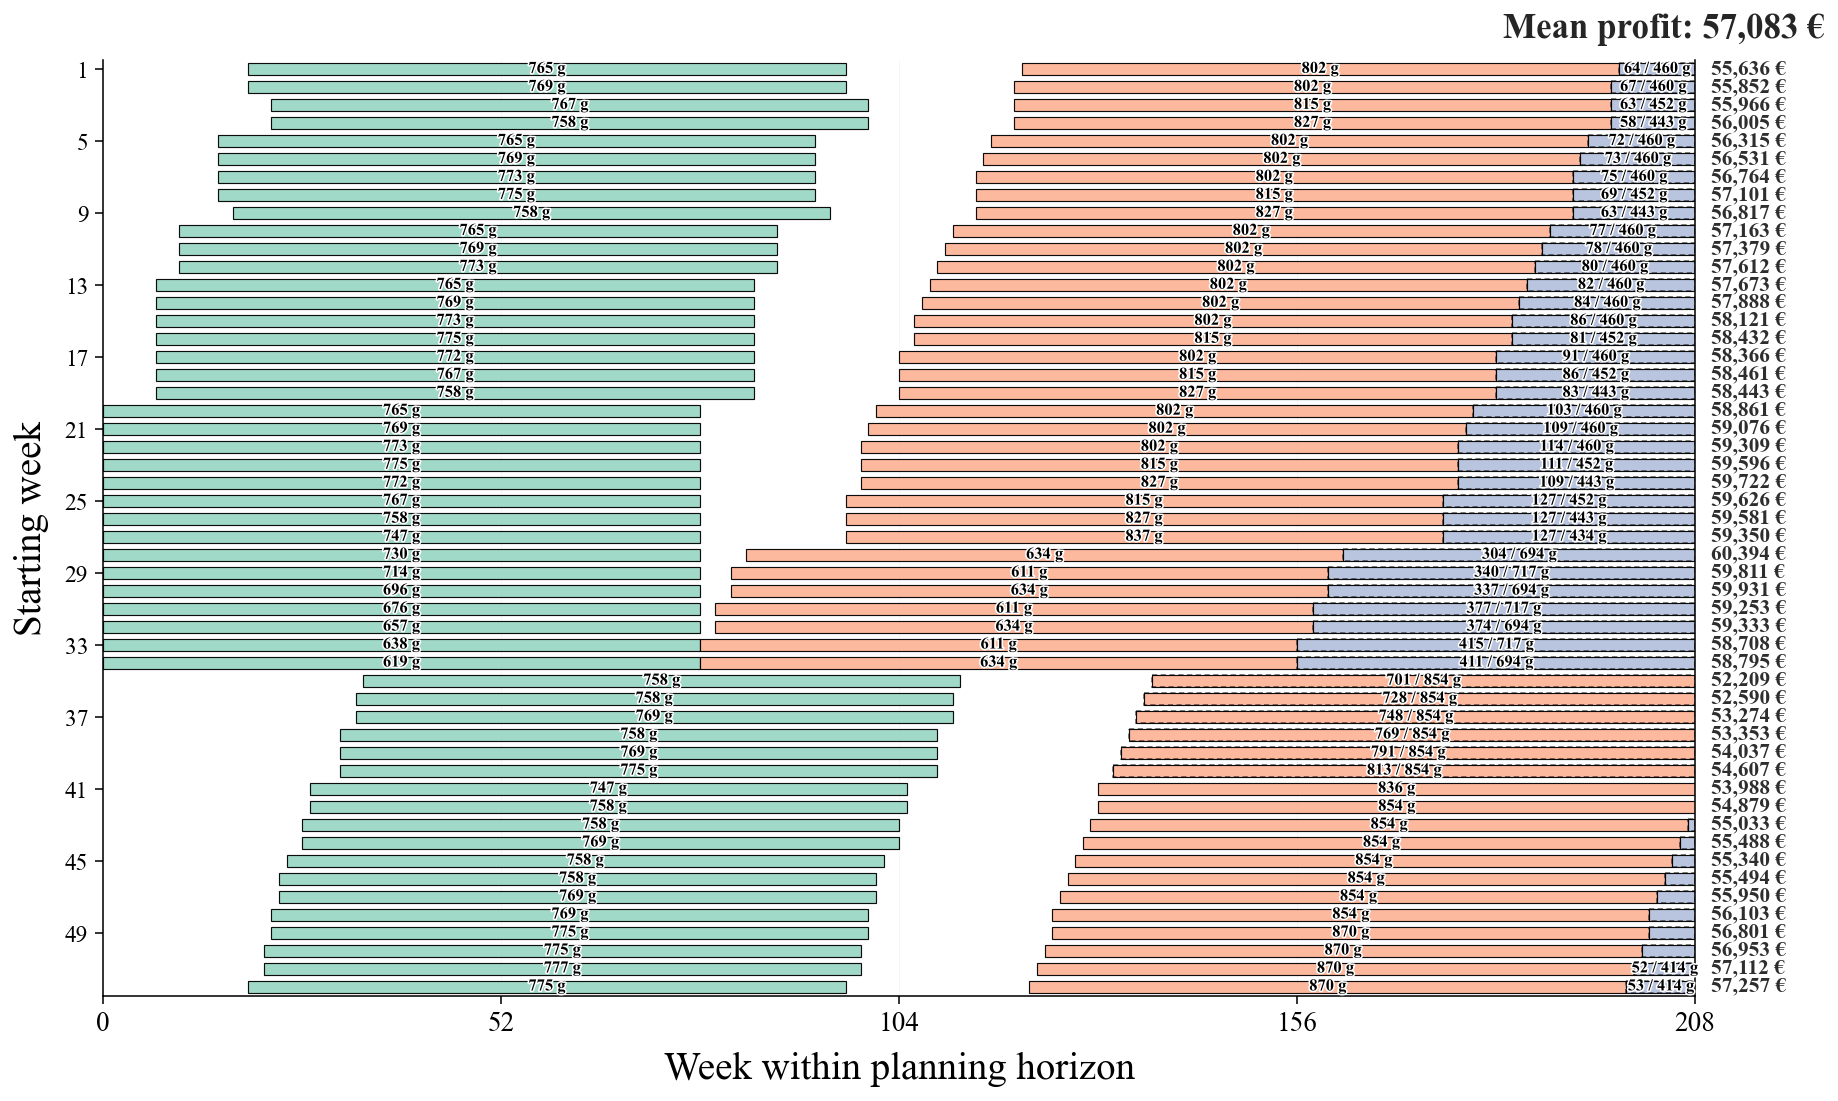

In [23]:
# =============================================================================
# MODEL LOADING
# =============================================================================
SEED = 123

model = MaskablePPO.load(f"best_model_val_fixed_price_{chosen_region}")


# =============================================================================
# SIMULATION + GANTT DATA (ENV-ALIGNED ROLLING TEST)
# =============================================================================
max_horizon = 208      # planning horizon shown in the Gantt (weeks)
policy_max_weeks = 78  # maximum action duration represented by the policy

gantt_rows = []              # list of "segments" per start_week row
total_profit_by_start = []   # total visible profit (€) per start_week row


for start_week in range(1, 53):

    # -------------------------------------------------------------------------
    # Rolling environment
    # -------------------------------------------------------------------------
    env_roll = AquacultureEnv(
        temperature_data=temperature_test,
        feed_rates_data=feed_rates,
        sale_prices_data=sale_prices,
        feed_prices_data=feed_prices,
        fixed_sale_prices=fixed_sale_prices,
        fixed_feed_prices=fixed_feed_prices,
        max_weeks=208,
        start_local_week=start_week,
        max_seeding=78,
        initial_fish_weight=30,
        initial_population=7100,
        chosen_feed_id="121",
        max_lot_weight_g=1000,
    )

    # Reset for reproducibility
    obs, _ = env_roll.reset(seed=SEED + start_week)

    # Row-level bookkeeping
    t = 0
    lote_id = 0
    segments = []
    profit_total = 0.0

    # -------------------------------------------------------------------------
    # Unmasked rolling simulation (true env dynamics)
    # -------------------------------------------------------------------------
    while t < max_horizon:

        remaining_visible = int(max_horizon - t)
        if remaining_visible <= 0:
            break

        action, _ = model.predict(
            obs,
            deterministic=True,
        )

        weeks_chosen = int(action) + 1
        weeks_chosen = max(1, min(weeks_chosen, policy_max_weeks))

        # ---------------------------------------------------------------------
        # ENV STEP (ground-truth logic)
        # ---------------------------------------------------------------------
        prev_planning_week = int(env_roll.current_planning_week)

        obs, reward, done, truncated, info = env_roll.step(action)

        visible_weeks = int(info["visible_weeks"])
        weeks_executed_full = int(info["weeks_executed"])
        was_truncated_by_horizon = bool(info["was_truncated_by_horizon"])
        fish_weight_full = float(info["final_fish_weight_g"])

        # ---------------------------------------------------------------------
        # Compute visible (truncated) fish weight when needed
        # ---------------------------------------------------------------------
        if was_truncated_by_horizon:

            start_week_natural = int(env_roll.start_local_week + prev_planning_week)

            fish_weight_visible, _, _, _, _ = env_roll._simulate_growth_helper(
                chosen_feed_rates=env_roll.chosen_feed_rates,
                temperature=env_roll.temperature_data,
                initial_weight=env_roll.initial_fish_weight,
                initial_population=env_roll.initial_population,
                start_week_natural=start_week_natural,
                num_sowing_weeks=visible_weeks,
                current_planning_week=prev_planning_week,
                enforce_planning_horizon=False,
            )
        else:
            fish_weight_visible = fish_weight_full

        # Commercial viability (based on full lot)
        sellable_full = bool(fish_weight_full >= 300.0)

        # Safety condition
        if weeks_executed_full <= 0 or visible_weeks <= 0:
            break

        # ---------------------------------------------------------------------
        # Store segment for Gantt
        # ---------------------------------------------------------------------
        if sellable_full:
            segments.append({
                "start": int(t),
                "dur": int(visible_weeks),
                "sellable": True,
                "weight_full": float(fish_weight_full),
                "weight_visible": float(fish_weight_visible),
                "lote_id": int(lote_id),
                "continuation": bool(was_truncated_by_horizon),
            })
            lote_id += 1

            # reward already scaled by env.step() -> convert to €
            profit_total += float(reward) * 1000.0

        # Advance timeline
        t += int(visible_weeks)

        # If horizon is exceeded, stop
        if done or was_truncated_by_horizon:
            break

    # Store row-level results
    gantt_rows.append(segments)
    total_profit_by_start.append(profit_total)


# ==========================================================
# JOURNAL-STYLE CONFIGURATION
# ==========================================================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 14,
    "ytick.labelsize": 12,
    "legend.fontsize": 16,
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
})


# ==========================================================
# HELPERS
# ==========================================================
def lighten_color(color, amount=0.35):
    """
    Lighten a color by mixing it with white.
    """
    c = np.array(mcolors.to_rgb(color), dtype=float)
    white = np.array([1.0, 1.0, 1.0], dtype=float)
    return tuple(c + (white - c) * float(amount))


def style_axes(ax):
    """
    Clean scientific journal style, preserving right spine.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(0.8)
    ax.tick_params(axis="both", which="major", length=4, width=0.8)
    return ax


# ==========================================================
# SUMMARY METRIC
# ==========================================================
mean_profit = float(np.mean(total_profit_by_start))


# ==========================================================
# FIGURE / AXES
# ==========================================================
fig, ax = plt.subplots(figsize=(13.5, 8.2))

# Leave room on the right for profit labels
plt.subplots_adjust(right=0.86)


# ==========================================================
# COLOR PALETTE AND BAR GEOMETRY
# ==========================================================
base_cmap = plt.colormaps["Set2"]
BAR_H = 0.68


# ==========================================================
# DRAW EACH ROW (one row per start_week)
# ==========================================================
for row_idx, segments in enumerate(gantt_rows, start=1):

    y = row_idx

    for seg in segments:

        base_color = base_cmap(seg["lote_id"] % base_cmap.N)
        color = lighten_color(base_color, amount=0.35)

        x0 = seg["start"]
        dur = seg["dur"]
        cont = seg["continuation"]

        w_full = seg["weight_full"]
        w_vis = seg["weight_visible"]

        ax.barh(
            y=y,
            width=dur,
            left=x0,
            height=BAR_H,
            color=color,
            edgecolor=(0, 0, 0, 0.22),
            linewidth=0.6,
            alpha=0.95,
            zorder=2,
        )

        # Outline for truncated blocks
        if cont:
            rect = Rectangle(
                (x0, y - BAR_H / 2),
                dur,
                BAR_H,
                fill=False,
                edgecolor=(0, 0, 0, 0.55),
                linewidth=0.9,
                linestyle=(0, (3, 2)),
                zorder=3,
            )
            ax.add_patch(rect)

        # Label (visible/full for truncated)
        if dur >= 8:
            if cont:
                label = f"{w_vis:.0f} / {w_full:.0f} g"
            else:
                label = f"{w_full:.0f} g"

            ax.text(
                x0 + dur / 2.0,
                y,
                label,
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="semibold",
                color="black",
                zorder=5,
                path_effects=[
                    pe.withStroke(linewidth=1.6, foreground="white")
                ],
            )
    # Profit label at right margin
    profit = total_profit_by_start[row_idx - 1]

    ax.text(
        1.01,
        y,
        f"{profit:,.0f} €",
        transform=ax.get_yaxis_transform(),
        ha="left",
        va="center",
        fontsize=11,
        fontweight="semibold",
        color=(0, 0, 0, 0.82),
    )


# ==========================================================
# AXES FORMATTING
# ==========================================================
ax.set_xlim(0, max_horizon - 1)
ax.set_ylim(0.5, 52.5)

yticks = np.arange(1, 53, 4)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)

ax.invert_yaxis()

# Ticks each year (52 weeks)
ax.set_xticks(np.arange(0, max_horizon + 1, 52))

ax.set_xlabel("Week within planning horizon", labelpad=8)
ax.set_ylabel("Starting week", labelpad=8)
style_axes(ax)

# Subtle grid only on x-axis
ax.grid(True, axis="x", linewidth=0.45, alpha=0.12)
ax.grid(False, axis="y")

# Mean profit annotation
ax.text(
    0.98,
    1.015,
    f"Mean profit: {mean_profit:,.0f} €",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=18,
    fontweight="semibold",
    color=(0, 0, 0, 0.85),
)

plt.tight_layout()
plt.show()

# **Heuristic Optimization**

This section optimizes a benchmark heuristic policy to compare against the DeepRL strategy.

The heuristic follows a temperature-based seeding rule: a new lot is started only when the current SST is above a selected threshold and the SST **three weeks ahead** also remains above that threshold. Once started, the lot is grown until it reaches a target harvest weight or the maximum duration of **78 weeks**.

The heuristic is calibrated using a **grid search on the validation set**. The searched parameters are:

- temperature threshold: **15.0–17.5 °C**, in steps of **0.5 °C**;
- target harvest weight: **300–1000 g**, in steps of **50 g**.

For each parameter combination, the heuristic is evaluated over all starting weeks from **1 to 52**, using a fixed planning horizon of **208 weeks** and the same economic and biological logic as the DeepRL environment, including proportional reward scaling for horizon-truncated lots.

The optimization metric is the **mean profit across all validation starting weeks**. For each region, the parameter combination with the highest mean validation profit is selected and saved for the final test comparison against the trained DeepRL policy.

In [14]:
# =============================================================================
# HEURISTIC GRID SEARCH (VAL) + TEST COMPARISON VS DEEPRL
#   - heuristic start rule:
#       * current temperature >= threshold
#       * temperature after 3 weeks also >= threshold
#   - grid search on validation:
#       * threshold in [15.0, 15.5, ..., 17.5]
#       * target weight in [300, 350, 400, ..., 1000]
#   - metric:
#       * mean profit over start weeks 1..52
#   - test:
#       * apply best heuristic params found on validation
#   - truncated lots:
#       * the FULL intended lot is simulated
#       * if the ACTUALLY executed full lot exceeds the visible horizon,
#         the visible contribution is:
#             full_profit * (remaining_visible_weeks / intended_duration)
#   - DeepRL:
#       * same unmasked rolling logic used in the modified test/Gantt
# =============================================================================


warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client"
)

MODEL_PATHS = {
    "Valencia": "best_model_val_fixed_price_Valencia",
    "Adriatico": "best_model_val_fixed_price_Adriatico",
    "Grecia": "best_model_val_fixed_price_Grecia",
}

# ==========================================================
# 0) JOURNAL-STYLE CONFIGURATION
# ==========================================================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
})

POLICY_COLORS = {
    "Heuristic": "#C77D36",   # muted orange
    "DeepRL": "#1B3A6F",      # deep blue
}


def style_axes(ax):
    """
    Apply a clean scientific-journal style to axes.

    :param ax: Matplotlib axis.
    :type ax: matplotlib.axes.Axes

    :return: Styled axis.
    :rtype: matplotlib.axes.Axes
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", length=4, width=0.8)
    return ax


def set_clean_time_axis(ax, x_min, x_max, step=52):
    """
    Set a clean time axis with annual ticks.

    :param ax: Matplotlib axis.
    :type ax: matplotlib.axes.Axes

    :param x_min: Minimum x value.
    :type x_min: int

    :param x_max: Maximum x value.
    :type x_max: int

    :param step: Tick spacing.
    :type step: int

    :return: None
    :rtype: None
    """
    ax.set_xlim(int(x_min), int(x_max))
    ax.set_xticks(np.arange(int(x_min), int(x_max) + 1, int(step)))


# ==========================================================
# 1) CONFIGURATION
# ==========================================================
EVAL_START_WEEKS = list(range(1, 53))
EVAL_MAX_WEEKS = 208
SEED = 123

MODEL_PATHS = {
    "Canarias": "best_model_val_Canarias",
    "Valencia": "best_model_val_Valencia",
    "Adriatico": "best_model_val_Adriatico",
    "Grecia": "best_model_val_Grecia",
}

# Grid search space for the heuristic
GRID_TEMP_THRESHOLDS = np.arange(15.0, 17.5 + 0.001, 0.5)
GRID_TARGET_WEIGHTS_G = np.arange(300.0, 1000.0 + 0.001, 50.0)

# New start rule:
#   seed if T(t) >= threshold and T(t + LOOKAHEAD_WEEKS) >= threshold
LOOKAHEAD_WEEKS = 3


# =========================================================
# 2) DATASET-SPECIFIC ENV / TEMPERATURE HELPERS
# =========================================================
def prepare_temperature_dataset(region, dataset_type, start_week, max_weeks, extra_weeks=118):
    """
    Prepare a temperature series long enough for rolling evaluation.

    The base series is cyclically wrapped so that:
      - validation episodes can probe beyond week 260 if needed,
      - test episodes can also look ahead safely.

    :param region: Region name.
    :type region: str

    :param dataset_type: Dataset split to use ("val" or "test").
    :type dataset_type: str

    :param start_week: Episode starting week.
    :type start_week: int

    :param max_weeks: Planning horizon.
    :type max_weeks: int

    :param extra_weeks: Additional safety margin for lookahead / long lots.
    :type extra_weeks: int

    :return: Temperature array [week_index, temperature].
    :rtype: numpy.ndarray
    """

    if dataset_type == "val":
        temperature_data_raw = temperature_val_by_region[region]
    elif dataset_type == "test":
        temperature_data_raw = temperature_test_by_region[region]
    else:
        raise ValueError(f"Unknown dataset_type='{dataset_type}'. Use 'val' or 'test'.")

    needed_len = int(start_week + max_weeks + extra_weeks)
    vals_1d = np.asarray(temperature_data_raw[:, 1], dtype=float)
    vals_long = wrap_to_length(vals_1d, needed_len)
    return to_temp_array(vals_long)


def make_env_dataset(region, dataset_type, start_week, max_weeks=208, internal_horizon=None):
    """
    Build a fixed-horizon base environment for a given region, dataset split and start week.

    :param region: Region name.
    :type region: str

    :param dataset_type: Dataset split to use ("val" or "test").
    :type dataset_type: str

    :param start_week: Episode starting week.
    :type start_week: int

    :param max_weeks: Visible planning horizon.
    :type max_weeks: int

    :param internal_horizon: Internal environment horizon. If None, uses max_weeks.
    :type internal_horizon: int or None

    :return: Base environment.
    :rtype: AquacultureEnv
    """

    temperature_data = prepare_temperature_dataset(
        region=region,
        dataset_type=dataset_type,
        start_week=int(start_week),
        max_weeks=int(max_weeks),
        extra_weeks=118,
    )

    env = AquacultureEnv(
        temperature_data=temperature_data,
        feed_rates_data=feed_rates,
        sale_prices_data=sale_prices,
        feed_prices_data=feed_prices,
        fixed_sale_prices=fixed_sale_prices,
        fixed_feed_prices=fixed_feed_prices,
        max_weeks=int(max_weeks if internal_horizon is None else internal_horizon),
        start_local_week=int(start_week),
        max_seeding=78,
        initial_fish_weight=30,
        initial_population=7100,
        chosen_feed_id=chosen_feed_id,
    )
    return env


# ==========================================================
# 3) BASIC HELPERS
# ==========================================================
def simulate_block(env_base, start_week_natural, num_weeks):
    """
    Simulate a production block without advancing the environment state.

    The full chosen block is simulated ignoring the episode planning horizon,
    matching the new environment logic.

    :param env_base: Base AquacultureEnv instance.
    :type env_base: AquacultureEnv

    :param start_week_natural: Natural start week index (1-indexed).
    :type start_week_natural: int

    :param num_weeks: Number of weeks to simulate.
    :type num_weeks: int

    :return: Tuple
             (
                 fish_weight_g,
                 total_food_used_g,
                 current_population,
                 reward_scaled,
                 weeks_executed,
             )
             where reward_scaled is in k€.
    :rtype: tuple[float, float, float, float, int]
    """

    fish_weight, total_food_used, current_population, _, weeks_executed = env_base._simulate_growth_helper(
        chosen_feed_rates=env_base.chosen_feed_rates,
        temperature=env_base.temperature_data,
        initial_weight=env_base.initial_fish_weight,
        initial_population=env_base.initial_population,
        start_week_natural=int(start_week_natural),
        num_sowing_weeks=int(num_weeks),
        current_planning_week=int(env_base.current_planning_week),
        enforce_planning_horizon=False,
    )

    reward = env_base._compute_reward(
        fish_weight=float(fish_weight),
        total_food_used=float(total_food_used),
        current_population=float(current_population),
        start_week=int(start_week_natural),
        feed_prices=env_base.feed_prices_data,
    )

    return (
        float(fish_weight),
        float(total_food_used),
        float(current_population),
        float(reward),
        int(weeks_executed),
    )


def get_temp_from_series(temperature_data, natural_week):
    """
    Retrieve the temperature for a natural week index (1-indexed).

    If the requested week exceeds the available series length, the last
    temperature value is repeated.

    :param temperature_data: Temperature array [week_index, temperature].
    :type temperature_data: numpy.ndarray

    :param natural_week: Natural week index.
    :type natural_week: int

    :return: Temperature value.
    :rtype: float
    """

    natural_week = int(natural_week)
    n_temp = int(temperature_data.shape[0])

    if natural_week < 1:
        natural_week = 1

    if natural_week > n_temp:
        return float(temperature_data[-1, 1])

    return float(temperature_data[natural_week - 1, 1])


def should_start_heuristic_lot(
    temperature_data,
    natural_week,
    start_temp_threshold,
    lookahead_weeks=3,
):
    """
    Decide whether the heuristic starts a lot in the current week.

    New rule:
      - current temperature must be at least start_temp_threshold
      - temperature after lookahead_weeks must also be at least start_temp_threshold

    :param temperature_data: Temperature array [week_index, temperature].
    :type temperature_data: numpy.ndarray

    :param natural_week: Current natural week index.
    :type natural_week: int

    :param start_temp_threshold: Minimum temperature required to start a lot.
    :type start_temp_threshold: float

    :param lookahead_weeks: Weeks ahead used to verify that temperature remains above threshold.
    :type lookahead_weeks: int

    :return: Whether a lot should be started.
    :rtype: bool
    """
    n_temp = temperature_data.shape[0]

    # Do not start if future temperature is not in dataset
    if natural_week + lookahead_weeks > n_temp:
        return False

    temp_now = float(temperature_data[natural_week - 1, 1])
    temp_future = float(temperature_data[natural_week + lookahead_weeks - 1, 1])

    return (
        temp_now >= start_temp_threshold and
        temp_future >= start_temp_threshold
    )


def compute_lot_reward_scaled(env_base, df_lot):
    """
    Compute the economic reward of a lot using the same reward function as the environment.

    :param env_base: Base AquacultureEnv instance.
    :type env_base: AquacultureEnv

    :param df_lot: Weekly DataFrame of one lot.
    :type df_lot: pandas.DataFrame

    :return: Reward scaled as in the environment (profit / 1000).
    :rtype: float
    """

    if df_lot is None or df_lot.empty:
        return 0.0

    final_row = df_lot.iloc[-1]

    return float(env_base._compute_reward(
        fish_weight=float(final_row["Weight_end_g"]),
        total_food_used=float(df_lot["Feed_week_g"].sum()),
        current_population=float(final_row["Population"]),
        start_week=int(df_lot.iloc[0]["Week"]),
        feed_prices=env_base.feed_prices_data,
    ))


def final_lot_profit_eur(df_lot):
    """
    Return the final profit of a weekly lot trace in euros.

    :param df_lot: Weekly DataFrame of one lot.
    :type df_lot: pandas.DataFrame

    :return: Final profit in euros.
    :rtype: float
    """
    if df_lot is None or df_lot.empty:
        return 0.0
    return float(df_lot["Profit_potential_eur"].iloc[-1])


def final_lot_weight_g(df_lot):
    """
    Return the final visible weight of a weekly lot trace in grams.

    :param df_lot: Weekly DataFrame of one lot.
    :type df_lot: pandas.DataFrame

    :return: Final weight in grams.
    :rtype: float
    """
    if df_lot is None or df_lot.empty:
        return 0.0
    return float(df_lot["Weight_end_g"].iloc[-1])


def is_sellable_df(df_lot):
    """
    Check whether a lot reaches commercial size at its visible end.

    :param df_lot: Weekly DataFrame of one lot.
    :type df_lot: pandas.DataFrame

    :return: Whether the lot is sellable.
    :rtype: bool
    """
    return final_lot_weight_g(df_lot) >= 300.0


def apply_proportional_truncated_reward_logic(df_visible, df_full, intended_duration):
    """
    Apply the new proportional truncation rule to a visible truncated trace.

    Rule:
      - compute the FULL intended lot profit,
      - if the FULL executed lot exceeds the visible horizon, assign:
            contribution_eur = full_profit_eur * (visible_weeks / intended_duration)
      - otherwise keep the full profit unchanged.

    Notes:
      - if the full lot is not sellable, full_profit_eur is already 0 and the
        proportional contribution is also 0.
      - this replaces the previous "sell at truncation / positive cost" logic.

    :param df_visible: Weekly DataFrame of the visible truncated part.
    :type df_visible: pandas.DataFrame

    :param df_full: Weekly DataFrame of the FULL intended lot.
    :type df_full: pandas.DataFrame

    :param intended_duration: Intended duration chosen for the lot.
    :type intended_duration: int

    :return: Tuple
             (
                 df_adjusted,
                 contribution_eur,
                 sellable_visible,
                 sellable_full,
                 reward_fraction_applied,
                 was_truncated_by_horizon,
             )
    :rtype: tuple[pandas.DataFrame, float, bool, bool, float, bool]
    """

    if df_visible is None or df_visible.empty:
        sellable_full = is_sellable_df(df_full)
        return df_visible, 0.0, False, bool(sellable_full), 0.0, False

    df_adj = df_visible.copy()

    sellable_visible = is_sellable_df(df_visible)
    sellable_full = is_sellable_df(df_full)

    full_profit_eur = final_lot_profit_eur(df_full)
    visible_weeks = int(len(df_visible))
    full_executed_weeks = int(len(df_full))
    intended_duration = int(intended_duration)

    was_truncated_by_horizon = bool(full_executed_weeks > visible_weeks)

    if was_truncated_by_horizon:
        reward_fraction = float(visible_weeks / intended_duration)
        contribution_eur = float(full_profit_eur) * reward_fraction
        df_adj["Reward_rule"] = "proportional_truncation"
    else:
        reward_fraction = 1.0
        contribution_eur = float(full_profit_eur)
        df_adj["Reward_rule"] = "full_profit"

    df_adj["Reward_fraction_applied"] = float(reward_fraction)

    return (
        df_adj,
        float(contribution_eur),
        bool(sellable_visible),
        bool(sellable_full),
        float(reward_fraction),
        bool(was_truncated_by_horizon),
    )


def add_counted_lot(
    parts,
    df_lot,
    policy_name,
    lot_contribution_eur,
    extra_cols=None,
):
    """
    Store a counted lot together with its assigned economic contribution.

    :param parts: List of stored lot DataFrames.
    :type parts: list[pandas.DataFrame]

    :param df_lot: Weekly DataFrame of the lot.
    :type df_lot: pandas.DataFrame

    :param policy_name: Policy label.
    :type policy_name: str

    :param lot_contribution_eur: Economic contribution assigned to the lot.
    :type lot_contribution_eur: float

    :param extra_cols: Optional extra columns to append.
    :type extra_cols: dict or None

    :return: None
    :rtype: None
    """

    if df_lot is None or df_lot.empty:
        return

    df_store = df_lot.copy()
    df_store["Policy"] = str(policy_name)
    df_store["Block_profit_eur"] = float(lot_contribution_eur)

    if extra_cols is not None:
        for k, v in extra_cols.items():
            df_store[k] = v

    parts.append(df_store)


def clamp_df_to_horizon(df, start_week, max_horizon):
    """
    Keep only rows within the displayed horizon [start_week, start_week + max_horizon - 1].

    :param df: Weekly simulation DataFrame.
    :type df: pandas.DataFrame

    :param start_week: Natural start week of the plot window.
    :type start_week: int

    :param max_horizon: Horizon length in weeks.
    :type max_horizon: int

    :return: Clamped DataFrame.
    :rtype: pandas.DataFrame
    """
    if df is None or df.empty:
        return df
    w0 = int(start_week)
    w1 = int(start_week + max_horizon - 1)
    return df[(df["Week"] >= w0) & (df["Week"] <= w1)].copy()


# ==========================================================
# 4) WEEKLY LOT SIMULATION
# ==========================================================
def simulate_lot_weekly(
    start_week_natural,
    num_weeks,
    initial_weight_g,
    initial_population,
    lot_id,
    temperature_data,
    chosen_feed_rates,
    fixed_sale_prices,
    fixed_feed_price_eur_per_kg,
):
    """
    Simulate a lot week-by-week using the same Mixed-TGC + feed-rate logic.

    IMPORTANT:
      - Simulation STOPS if temperature dataset is exhausted
        (aligned with DeepRL environment behavior).
    """

    # Mixed-TGC parameters
    TGC_1_3 = 0.001646
    TGC_2_3 = 0.016095
    critic_weight = 117.0
    temp_umbral = 12.0

    chosen_feed_rates = np.asarray(chosen_feed_rates, dtype=object)
    temperature_data = np.asarray(temperature_data, dtype=float)

    temp_min = chosen_feed_rates[:, 1].astype(float)
    temp_max = chosen_feed_rates[:, 2].astype(float)
    weight_min = chosen_feed_rates[:, 3].astype(float)
    weight_max = chosen_feed_rates[:, 4].astype(float)
    feeding_rate = chosen_feed_rates[:, 5].astype(float)
    death_rate = chosen_feed_rates[:, 7].astype(float)

    fish_weight = float(initial_weight_g)
    population = float(initial_population)

    cost_acc = 0.0
    n_temp = int(temperature_data.shape[0])

    rows = []

    for w in range(int(num_weeks)):
        week_natural = int(start_week_natural + w)

        # --------------------------------------------------
        # STOP if dataset exhausted (DeepRL-aligned behavior)
        # --------------------------------------------------
        if week_natural > n_temp:
            break

        temp_val = float(temperature_data[week_natural - 1, 1])

        weight_start = float(fish_weight)

        cond = (
            (temp_min <= temp_val) & (temp_val <= temp_max) &
            (weight_min <= fish_weight) & (fish_weight <= weight_max)
        )

        if np.any(cond):
            idx = int(np.nonzero(cond)[0][0])
            frate_week = (feeding_rate[idx] / 100.0) * 7.0
            surv_week = (1.0 - death_rate[idx] / 100.0) ** 7.0
        else:
            frate_week = 0.0
            surv_week = 1.0

        food_week = 0.0
        for _ in range(7):

            if temp_val > temp_umbral:
                if fish_weight < critic_weight:
                    b = 1.0 / 3.0
                    TGC = TGC_1_3
                else:
                    b = 2.0 / 3.0
                    TGC = TGC_2_3

                fish_weight = (fish_weight ** b + TGC * (temp_val - temp_umbral)) ** (1.0 / b)

            food_day = (frate_week / 7.0) * fish_weight * population
            food_week += float(food_day)

        population *= float(surv_week)
        population = max(0.0, float(population))

        cost_week = (food_week / 1000.0) * float(fixed_feed_price_eur_per_kg)
        cost_acc += float(cost_week)

        # Income
        if fish_weight < 300.0:
            income = 0.0
        else:
            if fish_weight < 400.0:
                sales_price = float(fixed_sale_prices[0])
            elif fish_weight < 600.0:
                sales_price = float(fixed_sale_prices[1])
            else:
                sales_price = float(fixed_sale_prices[2])

            biomass_kg = population * (fish_weight / 1000.0)
            income = float(biomass_kg * sales_price)

        profit = float(income - cost_acc)

        rows.append({
            "Week": week_natural,
            "Lot": int(lot_id),
            "Temperature": float(temp_val),
            "Weight_start_g": float(weight_start),
            "Weight_end_g": float(fish_weight),
            "Population": float(population),
            "Feed_week_g": float(food_week),
            "Profit_potential_eur": float(profit),
        })

        if population <= 0.0:
            break

    return pd.DataFrame(rows)


# ==========================================================
# 5) HEURISTIC POLICY: ONE EPISODE
# ==========================================================
def simulate_heuristic_episode(
    region,
    dataset_type,
    start_week,
    target_weight_g=300.0,
    start_temp_threshold=17.5,
    lookahead_weeks=3,
    seed=123,
    max_weeks=208,
    return_weekly_df=False,
):
    """
    Simulate one episode using the heuristic policy.

    Main logic:
      - scan week by week until a valid seeding window is found
      - once started, keep the lot until one of the following occurs:
          * the target weight is reached
          * 78 weeks have elapsed
      - if the executed lot fits inside the visible horizon, its full profit is used
      - if the executed lot exceeds the visible horizon, its visible contribution is:
            full_profit * (visible_weeks / intended_duration)

    Representation/economics:
      - sellable full lots are counted and plotted
      - valid truncated lots are also counted and plotted
      - non-sellable lots contribute 0 and are not plotted

    :param region: Region name.
    :type region: str

    :param dataset_type: Dataset split to use ("val" or "test").
    :type dataset_type: str

    :param start_week: Episode starting week.
    :type start_week: int

    :param target_weight_g: Harvest threshold used by the heuristic.
    :type target_weight_g: float

    :param start_temp_threshold: Minimum temperature required to start a lot.
    :type start_temp_threshold: float

    :param lookahead_weeks: Weeks ahead used to verify temperature persistence above threshold.
    :type lookahead_weeks: int

    :param seed: Seed used to initialize the environment.
    :type seed: int

    :param max_weeks: Planning horizon.
    :type max_weeks: int

    :param return_weekly_df: Whether to return the weekly traces of stored lots.
    :type return_weekly_df: bool

    :return: If return_weekly_df is False:
               (total_profit_eur, executed_blocks)
             else:
               (total_profit_eur, executed_blocks, df_all)
    :rtype: tuple
    """

    # ---------------------------------------------------------------------
    # Temperature dataset (aligned with DeepRL)
    # ---------------------------------------------------------------------
    if dataset_type == "test":
        # Real TEST series, no wrapping -> same logic as DeepRL/Gantt
        temperature_data = temperature_test_by_region[region]
    elif dataset_type == "val":
        # Wrapped VAL series -> needed for grid search stability
        temperature_data = prepare_temperature_dataset(
            region=region,
            dataset_type=dataset_type,
            start_week=int(start_week),
            max_weeks=int(max_weeks),
            extra_weeks=118,
        )
    else:
        raise ValueError(f"Unknown dataset_type='{dataset_type}'. Use 'val' or 'test'.")


    env_base = AquacultureEnv(
        temperature_data=temperature_data,
        feed_rates_data=feed_rates,
        sale_prices_data=sale_prices,
        feed_prices_data=feed_prices,
        fixed_sale_prices=fixed_sale_prices,
        fixed_feed_prices=fixed_feed_prices,
        max_weeks=max(10_000, int(max_weeks) + 500),
        start_local_week=int(start_week),
        max_seeding=78,
        initial_fish_weight=30,
        initial_population=7100,
        chosen_feed_id=chosen_feed_id,
    )
    env_base.reset(seed=int(seed))

    chosen_feed_rates_local = feed_rates[feed_rates[:, 0].astype(str) == str(chosen_feed_id)]
    if chosen_feed_rates_local.size == 0:
        raise ValueError(f"[{region}] No feed_rates found for chosen_feed_id='{chosen_feed_id}'.")

    fixed_feed_price = float(np.asarray(fixed_feed_prices, dtype=float)[0])

    t = 0
    lot_id = 1
    total_profit_eur = 0.0
    executed_blocks = []
    parts = []

    # Operational cap to match DeepRL action space
    MAX_LOT_WEEKS = 78

    while t < int(max_weeks):
        current_week_natural = int(start_week + t)

        # Search week by week for a seeding window
        if not should_start_heuristic_lot(
            temperature_data=temperature_data,
            natural_week=current_week_natural,
            start_temp_threshold=float(start_temp_threshold),
            lookahead_weeks=int(lookahead_weeks),
        ):
            t += 1
            continue

        # Build the FULL intended lot under the operational cap / target rule
        df_full_probe = simulate_lot_weekly(
            start_week_natural=current_week_natural,
            num_weeks=int(MAX_LOT_WEEKS),
            initial_weight_g=float(env_base.initial_fish_weight),
            initial_population=float(env_base.initial_population),
            lot_id=int(lot_id),
            temperature_data=temperature_data,
            chosen_feed_rates=chosen_feed_rates_local,
            fixed_sale_prices=np.asarray(fixed_sale_prices, dtype=float),
            fixed_feed_price_eur_per_kg=float(fixed_feed_price),
        )

        if df_full_probe.empty:
            break

        reached_mask = df_full_probe["Weight_end_g"].to_numpy(dtype=float) >= float(target_weight_g)

        if np.any(reached_mask):
            idx_end = int(np.nonzero(reached_mask)[0][0])
            df_full_lot = df_full_probe.iloc[:idx_end + 1].copy()
        else:
            df_full_lot = df_full_probe.copy()

        intended_duration = int(len(df_full_lot))
        if intended_duration <= 0:
            break

        remaining_visible = int(max_weeks - t)
        visible_weeks = min(intended_duration, remaining_visible)

        if visible_weeks <= 0:
            break

        df_visible = df_full_lot.iloc[:visible_weeks].copy()

        (
            df_visible_adj,
            contribution_eur,
            sellable_visible,
            sellable_full,
            reward_fraction_applied,
            was_truncated_by_horizon,
        ) = apply_proportional_truncated_reward_logic(
            df_visible=df_visible,
            df_full=df_full_lot,
            intended_duration=intended_duration,
        )

        extra_cols_local = {
            "Target_weight_g": float(target_weight_g),
            "Start_temp_threshold": float(start_temp_threshold),
            "Lookahead_weeks": int(lookahead_weeks),
            "Truncated": bool(was_truncated_by_horizon),
            "Reward_fraction_applied": float(reward_fraction_applied),
        }

        if sellable_full and (df_visible_adj is not None) and (not df_visible_adj.empty):
            total_profit_eur += float(contribution_eur)
            executed_blocks.append(int(len(df_visible_adj)))

            add_counted_lot(
                parts=parts,
                df_lot=df_visible_adj,
                policy_name="Heuristic",
                lot_contribution_eur=float(contribution_eur),
                extra_cols=extra_cols_local,
            )

        t += int(visible_weeks)
        lot_id += 1

        if was_truncated_by_horizon:
            break

    df_all = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    df_all = clamp_df_to_horizon(df_all, start_week, max_weeks)

    if return_weekly_df:
        return float(total_profit_eur), executed_blocks, df_all

    return float(total_profit_eur), executed_blocks


# ==========================================================
# 6) DEEPRL POLICY: ONE EPISODE
# ==========================================================
def simulate_deeprl_episode(
    region,
    dataset_type,
    model_path,
    start_week,
    seed=123,
    max_weeks=208,
    return_weekly_df=False,
):
    """
    Simulate one episode using the trained DeepRL policy.

    Logic:
      - unmasked rolling evaluation
      - the policy is queried WITHOUT action masking
      - the environment step() is used directly
      - the FULL chosen lot is simulated internally by the environment
      - if the ACTUALLY executed full lot exceeds the visible horizon,
        the reward assigned by env.step() is scaled proportionally

    Dataset handling:
      - VAL: uses the wrapped/extended validation temperature series
      - TEST: uses the real test temperature series with NO wrapping,
              matching the Gantt evaluation logic

    Non-sellable lots contribute 0 and are not plotted.

    :param region: Region name.
    :type region: str

    :param dataset_type: Dataset split to use ("val" or "test").
    :type dataset_type: str

    :param model_path: Path of the trained MaskablePPO model.
    :type model_path: str

    :param start_week: Episode starting week.
    :type start_week: int

    :param seed: Seed used to initialize the environment.
    :type seed: int

    :param max_weeks: Planning horizon.
    :type max_weeks: int

    :param return_weekly_df: Whether to return the weekly traces of stored lots.
    :type return_weekly_df: bool

    :return: If return_weekly_df is False:
               (total_profit_eur, executed_blocks)
             else:
               (total_profit_eur, executed_blocks, df_all)
    :rtype: tuple
    """

    # ---------------------------------------------------------------------
    # Temperature dataset
    # ---------------------------------------------------------------------
    if dataset_type == "test":
        # Real TEST series, no wrapping -> same logic as the DeepRL Gantt
        temperature_data = temperature_test_by_region[region]
    elif dataset_type == "val":
        # Wrapped VAL series -> keep current validation logic
        temperature_data = prepare_temperature_dataset(
            region=region,
            dataset_type=dataset_type,
            start_week=int(start_week),
            max_weeks=int(max_weeks),
            extra_weeks=118,
        )
    else:
        raise ValueError(f"Unknown dataset_type='{dataset_type}'. Use 'val' or 'test'.")

    model = MaskablePPO.load(model_path)

    chosen_feed_rates_local = feed_rates[feed_rates[:, 0].astype(str) == str(chosen_feed_id)]
    if chosen_feed_rates_local.size == 0:
        raise ValueError(f"[{region}] No feed_rates found for chosen_feed_id='{chosen_feed_id}'.")

    fixed_feed_price = float(np.asarray(fixed_feed_prices, dtype=float)[0])

    # -------------------------
    # 1) ROLLING PHASE (UNMASKED, TRUE ENV LOGIC)
    # -------------------------
    env = AquacultureEnv(
        temperature_data=temperature_data,
        feed_rates_data=feed_rates,
        sale_prices_data=sale_prices,
        feed_prices_data=feed_prices,
        fixed_sale_prices=fixed_sale_prices,
        fixed_feed_prices=fixed_feed_prices,
        max_weeks=int(max_weeks),
        start_local_week=int(start_week),
        max_seeding=78,
        initial_fish_weight=30,
        initial_population=7100,
        chosen_feed_id=chosen_feed_id,
        max_lot_weight_g=1000,
    )
    obs, _ = env.reset(seed=int(seed))

    t = 0
    lot_id = 1
    total_profit_eur = 0.0
    executed_blocks = []
    parts = []

    while t < int(max_weeks):

        remaining_visible = int(max_weeks - t)
        if remaining_visible <= 0:
            break

        # Predict WITHOUT action masking
        action, _ = model.predict(
            obs,
            deterministic=True,
        )

        weeks_chosen = int(action) + 1
        weeks_chosen = max(1, min(weeks_chosen, int(env.max_seeding)))

        # Store pre-step planning week to reconstruct the lot trace afterwards
        prev_planning_week = int(env.current_planning_week)
        start_week_natural = int(env.start_local_week + prev_planning_week)

        # -------------------------
        # TRUE ENV STEP
        # -------------------------
        obs, reward, done, truncated, info = env.step(action)

        visible_weeks = int(info["visible_weeks"])
        weeks_executed_full = int(info["weeks_executed"])
        was_truncated_by_horizon = bool(info["was_truncated_by_horizon"])
        fish_weight_full = float(info["final_fish_weight_g"])

        if weeks_executed_full <= 0 or visible_weeks <= 0:
            break

        # -------------------------
        # Reconstruct full and visible traces for plotting/storage
        # -------------------------
        df_full_lot = simulate_lot_weekly(
            start_week_natural=int(start_week_natural),
            num_weeks=int(weeks_executed_full),
            initial_weight_g=float(env.initial_fish_weight),
            initial_population=float(env.initial_population),
            lot_id=int(lot_id),
            temperature_data=temperature_data,
            chosen_feed_rates=chosen_feed_rates_local,
            fixed_sale_prices=np.asarray(fixed_sale_prices, dtype=float),
            fixed_feed_price_eur_per_kg=float(fixed_feed_price),
        )

        if df_full_lot.empty:
            break

        df_visible = df_full_lot.iloc[:int(visible_weeks)].copy()

        sellable_full = bool(fish_weight_full >= 300.0)

        if sellable_full and (df_visible is not None) and (not df_visible.empty):
            total_profit_eur += float(reward) * 1000.0
            executed_blocks.append(int(len(df_visible)))

            add_counted_lot(
                parts=parts,
                df_lot=df_visible,
                policy_name="DeepRL",
                lot_contribution_eur=float(reward) * 1000.0,
                extra_cols={
                    "Truncated": bool(was_truncated_by_horizon),
                    "Reward_fraction_applied": float(info["reward_fraction_applied"]),
                    "Weeks_chosen": int(weeks_chosen),
                    "Weeks_executed_full": int(weeks_executed_full),
                    "Full_final_weight_g": float(fish_weight_full),
                },
            )

        t += int(visible_weeks)
        lot_id += 1

        if done or truncated or was_truncated_by_horizon:
            break

    df_all = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    df_all = clamp_df_to_horizon(df_all, start_week, max_weeks)

    if return_weekly_df:
        return float(total_profit_eur), executed_blocks, df_all

    return float(total_profit_eur), executed_blocks

# ==========================================================
# 7) EVALUATION FUNCTIONS
# ==========================================================
def evaluate_heuristic_policy_region(
    region,
    dataset_type,
    start_weeks,
    target_weight_g=300.0,
    start_temp_threshold=17.5,
    lookahead_weeks=3,
    seed=123,
    max_weeks=208,
):
    """
    Evaluate the heuristic policy over all configured start weeks.

    :param region: Region name.
    :type region: str

    :param dataset_type: Dataset split to use ("val" or "test").
    :type dataset_type: str

    :param start_weeks: List of start weeks to evaluate.
    :type start_weeks: list[int]

    :param target_weight_g: Harvest threshold used by the heuristic.
    :type target_weight_g: float

    :param start_temp_threshold: Minimum temperature required to start a lot.
    :type start_temp_threshold: float

    :param lookahead_weeks: Weeks ahead used to verify temperature persistence above threshold.
    :type lookahead_weeks: int

    :param seed: Base seed for reproducibility.
    :type seed: int

    :param max_weeks: Planning horizon.
    :type max_weeks: int

    :return: Detailed evaluation table.
    :rtype: pandas.DataFrame
    """

    rows = []

    for i, sw in enumerate(start_weeks):
        profit_eur, executed_blocks = simulate_heuristic_episode(
            region=region,
            dataset_type=dataset_type,
            start_week=sw,
            target_weight_g=float(target_weight_g),
            start_temp_threshold=float(start_temp_threshold),
            lookahead_weeks=int(lookahead_weeks),
            seed=seed + i,
            max_weeks=max_weeks,
            return_weekly_df=False,
        )

        rows.append({
            "Region": region,
            "Policy": "Heuristic",
            "Dataset": dataset_type,
            "Start_week": int(sw),
            "Profit_eur": float(profit_eur),
            "Num_counted_blocks": int(len(executed_blocks)),
            "Counted_blocks": str(executed_blocks),
            "Target_weight_g": float(target_weight_g),
            "Start_temp_threshold": float(start_temp_threshold),
            "Lookahead_weeks": int(lookahead_weeks),
        })

    return pd.DataFrame(rows)


def evaluate_deeprl_policy_region(
    region,
    dataset_type,
    model_path,
    start_weeks,
    seed=123,
    max_weeks=208,
):
    """
    Evaluate the DeepRL policy over all configured start weeks.

    :param region: Region name.
    :type region: str

    :param dataset_type: Dataset split to use ("val" or "test").
    :type dataset_type: str

    :param model_path: Path of the trained model.
    :type model_path: str

    :param start_weeks: List of start weeks to evaluate.
    :type start_weeks: list[int]

    :param seed: Base seed for reproducibility.
    :type seed: int

    :param max_weeks: Planning horizon.
    :type max_weeks: int

    :return: Detailed evaluation table.
    :rtype: pandas.DataFrame
    """

    rows = []

    for i, sw in enumerate(start_weeks):
        profit_eur, executed_blocks = simulate_deeprl_episode(
            region=region,
            dataset_type=dataset_type,
            model_path=model_path,
            start_week=sw,
            seed=seed + i,
            max_weeks=max_weeks,
            return_weekly_df=False,
        )

        rows.append({
            "Region": region,
            "Policy": "DeepRL",
            "Dataset": dataset_type,
            "Start_week": int(sw),
            "Profit_eur": float(profit_eur),
            "Num_counted_blocks": int(len(executed_blocks)),
            "Counted_blocks": str(executed_blocks),
            "Target_weight_g": np.nan,
            "Start_temp_threshold": np.nan,
            "Lookahead_weeks": np.nan,
        })

    return pd.DataFrame(rows)


# ==========================================================
# 8) HEURISTIC GRID SEARCH ON VALIDATION
# ==========================================================
def grid_search_heuristic_validation(
    region,
    start_weeks,
    temp_thresholds,
    target_weights_g,
    lookahead_weeks=3,
    seed=123,
    max_weeks=208,
    print_progress=True,
):
    """
    Perform a grid search for the heuristic on the validation set.

    The metric is the mean profit across all start weeks.

    :param region: Region name.
    :type region: str

    :param start_weeks: List of validation start weeks.
    :type start_weeks: list[int]

    :param temp_thresholds: Candidate temperature thresholds.
    :type temp_thresholds: iterable[float]

    :param target_weights_g: Candidate target weights in grams.
    :type target_weights_g: iterable[float]

    :param lookahead_weeks: Weeks ahead used in the start rule.
    :type lookahead_weeks: int

    :param seed: Base seed for reproducibility.
    :type seed: int

    :param max_weeks: Planning horizon.
    :type max_weeks: int

    :param print_progress: Whether to print progress information.
    :type print_progress: bool

    :return: Tuple (df_grid, best_params, best_value)
    :rtype: tuple[pandas.DataFrame, dict, float]
    """

    combinations = list(product(temp_thresholds, target_weights_g))
    n_total = len(combinations)

    t0 = time.perf_counter()
    rows = []

    best_value = -np.inf
    best_params = None

    for idx, (temp_thr, target_w) in enumerate(combinations, start=1):
        df_eval = evaluate_heuristic_policy_region(
            region=region,
            dataset_type="val",
            start_weeks=start_weeks,
            target_weight_g=float(target_w),
            start_temp_threshold=float(temp_thr),
            lookahead_weeks=int(lookahead_weeks),
            seed=seed,
            max_weeks=max_weeks,
        )

        mean_profit = float(df_eval["Profit_eur"].mean())
        std_profit = float(df_eval["Profit_eur"].std())

        rows.append({
            "Region": region,
            "Dataset": "val",
            "Start_temp_threshold": float(temp_thr),
            "Target_weight_g": float(target_w),
            "Lookahead_weeks": int(lookahead_weeks),
            "Mean_profit_eur": mean_profit,
            "Std_profit_eur": std_profit,
        })

        if mean_profit > best_value:
            best_value = mean_profit
            best_params = {
                "start_temp_threshold": float(temp_thr),
                "target_weight_g": float(target_w),
                "lookahead_weeks": int(lookahead_weeks),
            }

        if print_progress:
            elapsed = time.perf_counter() - t0
            mean_time_per_combo = elapsed / float(idx)
            eta = mean_time_per_combo * float(n_total - idx)

            print(
                f"[GRID][{region}] {idx:03d}/{n_total:03d} | "
                f"T_thr={temp_thr:.1f} | W_target={target_w:.0f} g | "
                f"mean_val_profit={mean_profit:,.2f} € | "
                f"elapsed={elapsed:,.1f}s | eta={eta:,.1f}s"
            )

    df_grid = pd.DataFrame(rows).sort_values(
        ["Mean_profit_eur", "Start_temp_threshold", "Target_weight_g"],
        ascending=[False, True, True],
    ).reset_index(drop=True)

    return df_grid, best_params, float(best_value)



In [ ]:
# ==========================================================
# 9) RUN GRID SEARCH FOR ALL REGIONS
# ==========================================================
grid_parts = []
best_heuristic_params_by_region = {}

global_t0 = time.perf_counter()

for r_idx, region in enumerate(REGIONS, start=1):
    print("\n" + "=" * 80)
    print(f"[GRID SEARCH] Region {r_idx}/{len(REGIONS)} -> {region}")
    print("=" * 80)

    df_grid_region, best_params_region, best_value_region = grid_search_heuristic_validation(
        region=region,
        start_weeks=EVAL_START_WEEKS,
        temp_thresholds=GRID_TEMP_THRESHOLDS,
        target_weights_g=GRID_TARGET_WEIGHTS_G,
        lookahead_weeks=LOOKAHEAD_WEEKS,
        seed=SEED,
        max_weeks=EVAL_MAX_WEEKS,
        print_progress=True,
    )

    grid_parts.append(df_grid_region)
    best_heuristic_params_by_region[region] = dict(best_params_region)

    print(f"\n[BEST VAL][{region}] mean_profit={best_value_region:,.2f} €")
    print(best_params_region)

global_elapsed = time.perf_counter() - global_t0
print(f"\n[GRID SEARCH COMPLETED] Total elapsed time: {global_elapsed:,.1f} seconds")

df_grid_search = pd.concat(grid_parts, ignore_index=True)
df_grid_search.to_csv("heuristic_grid_search_validation.csv", index=False)

print("\n=== BEST HEURISTIC PARAMS BY REGION (VALIDATION) ===")
for region in REGIONS:
    print(f"{region}: {best_heuristic_params_by_region[region]}")

# **DeepRL vs Heuristic**

This section compares the final **DeepRL policy** against the optimized **heuristic benchmark** on the test dataset.

For each region, the heuristic is evaluated using the best validation parameters, while DeepRL is evaluated using the corresponding best saved model. Both policies follow the same test protocol: one deterministic episode is simulated for each starting week from **1 to 52**, with a fixed planning horizon of **208 weeks**.

The results are first stored at start-week level, recording the total profit obtained by each policy. They are then aggregated by region and policy to compute summary statistics, including mean, standard deviation, median, quartiles, minimum, and maximum profit. A comparison table is also generated to quantify the absolute and relative profit difference between DeepRL and the heuristic.

Profit distributions are visualized using combined **violin plots and boxplots**, making it possible to compare performance variability across regions. In addition, detailed lot-level plots are produced for a selected region and starting week, showing temperature, fish weight, and visible profit trajectories for both policies. This helps interpret how each strategy schedules production lots over the planning horizon.


=== TEST SUMMARY BY REGION AND POLICY ===
      Region     Policy  Mean_profit_eur  Std_profit_eur  Min_profit_eur  \
0  Adriatico     DeepRL     49256.938771     1256.739547    45661.107024   
1  Adriatico  Heuristic     42041.924378     3943.176438    36502.006548   
2     Grecia     DeepRL     74355.815135     1502.002932    72290.792683   
3     Grecia  Heuristic     73242.603410     2358.435540    69526.611960   
4   Valencia     DeepRL     57083.413647     2070.905176    52208.627927   
5   Valencia  Heuristic     50064.632692     4481.008191    42590.424333   

   Max_profit_eur  Median_profit_eur  Q1_profit_eur  Q3_profit_eur  
0    50762.230622       49666.719386   48913.225157   50180.825175  
1    47870.520093       41962.388595   38169.421071   45977.343292  
2    76922.868748       74049.086362   72978.024848   75672.567067  
3    76666.990835       73373.242058   71117.806381   75457.921960  
4    60393.998001       57137.753145   55797.872702   58811.237641  
5    61207

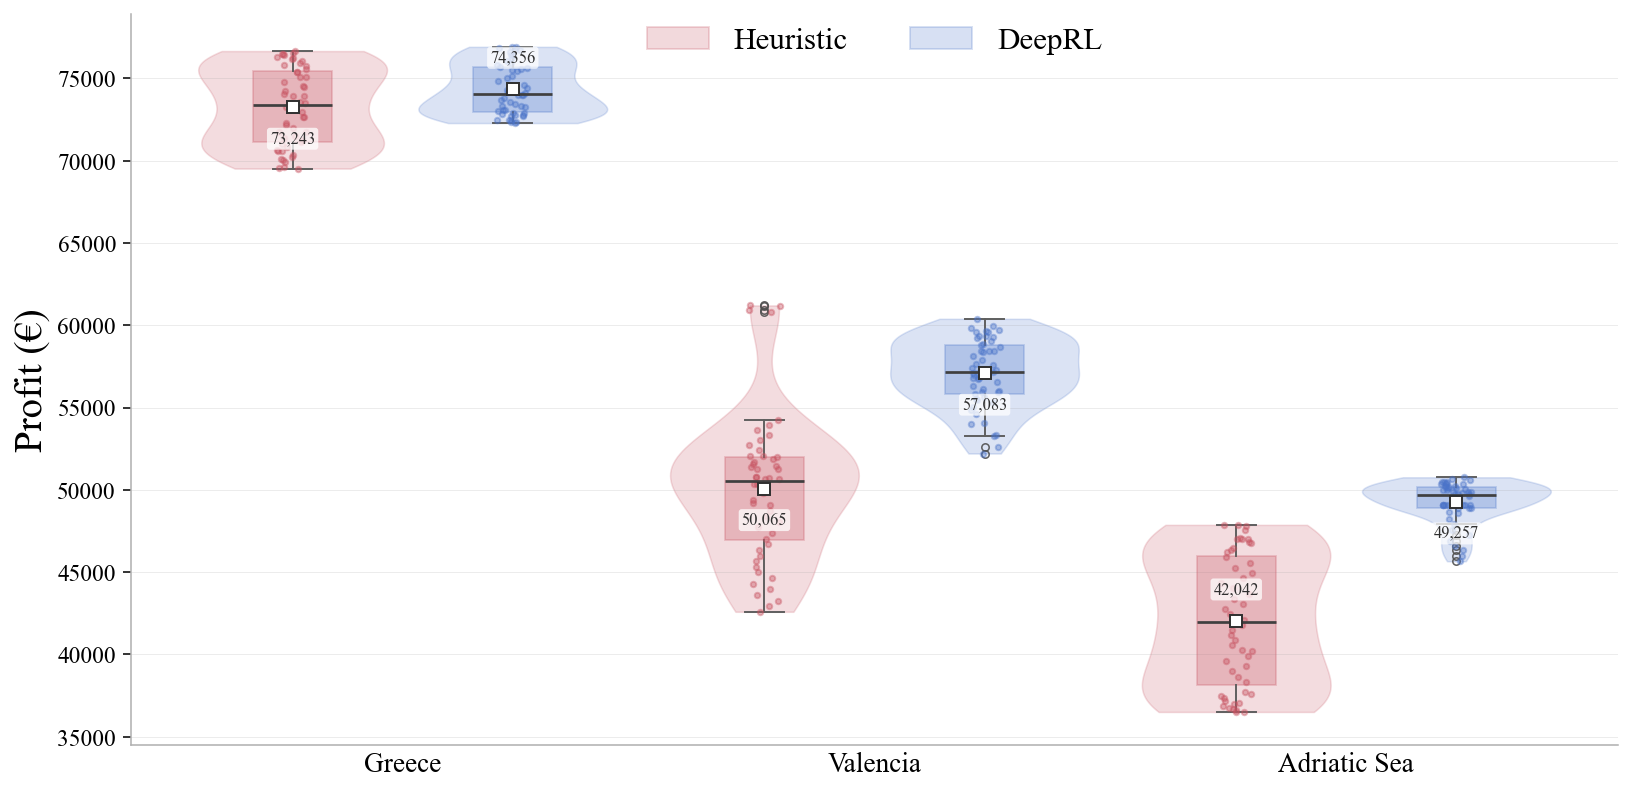


=== TEST PLOT REGION: Valencia | START WEEK: 1 ===
Best heuristic params: {'start_temp_threshold': 16.5, 'target_weight_g': 600.0, 'lookahead_weeks': 3}
Heuristic profit (€): 42,590.42 | Counted blocks: [69, 78, 34]
DeepRL profit   (€): 55,636.16 | Counted blocks: [78, 78, 10]


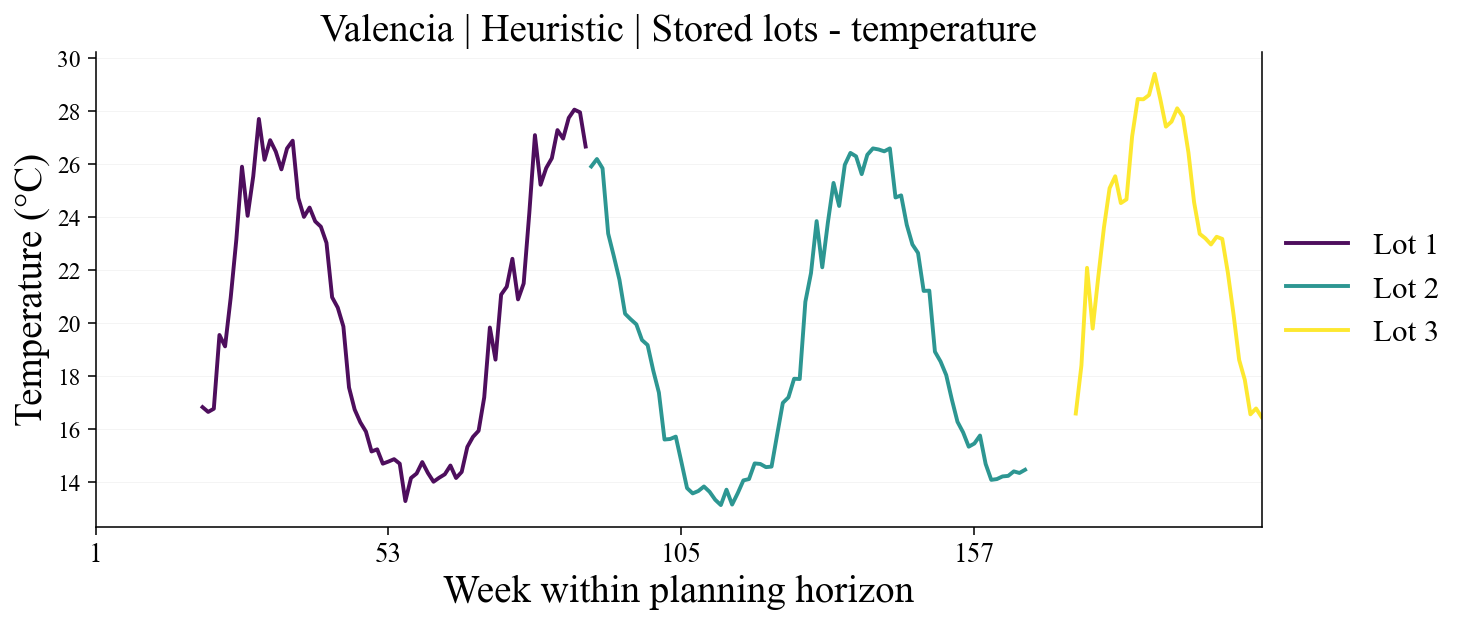

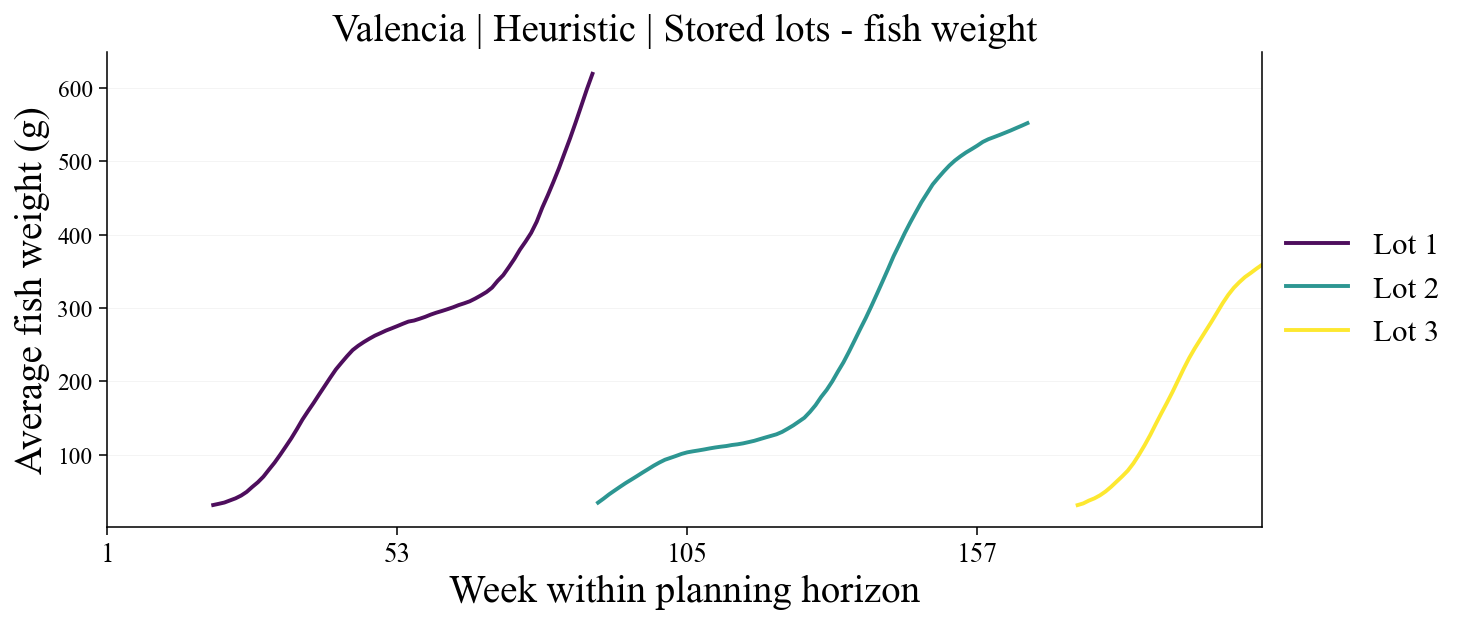

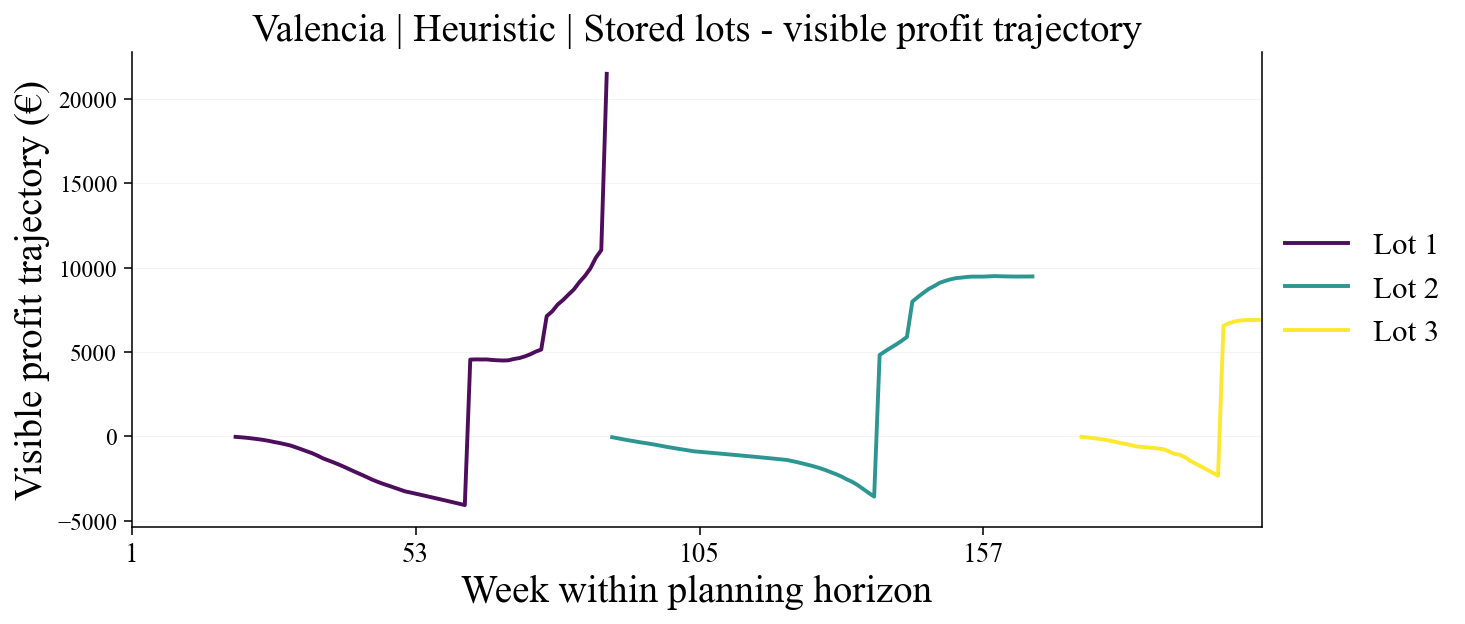

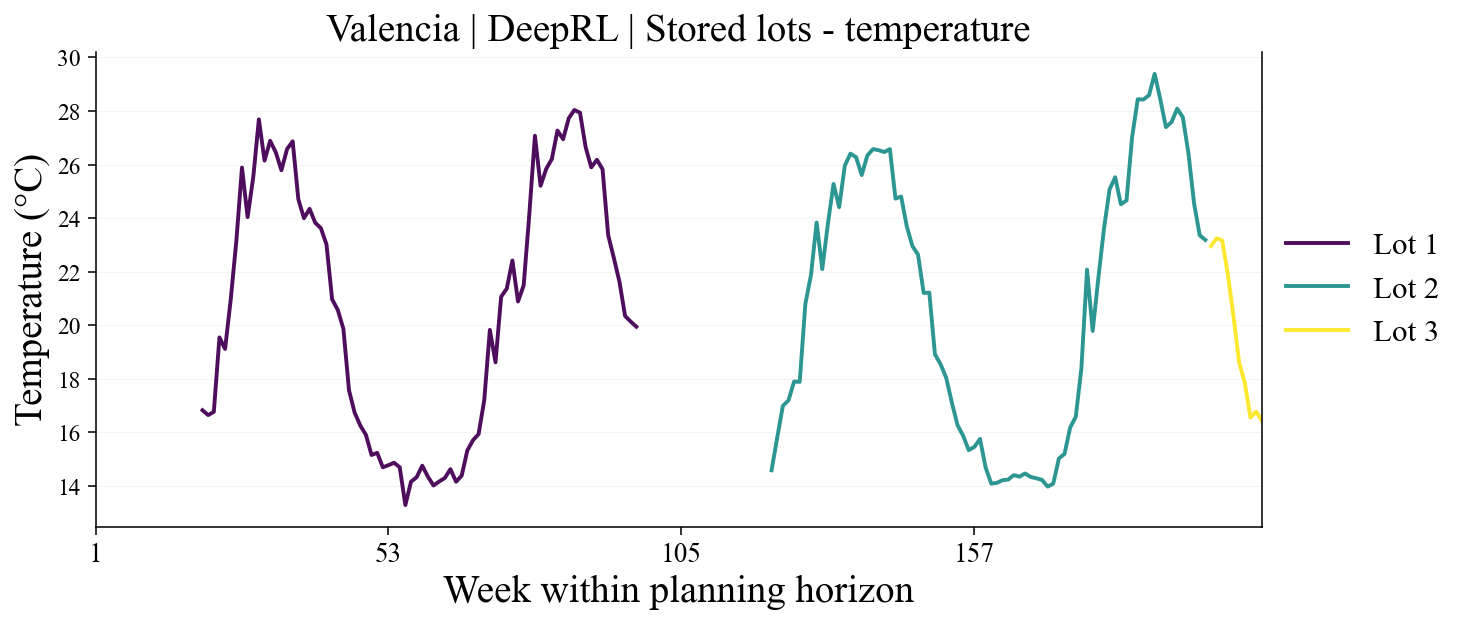

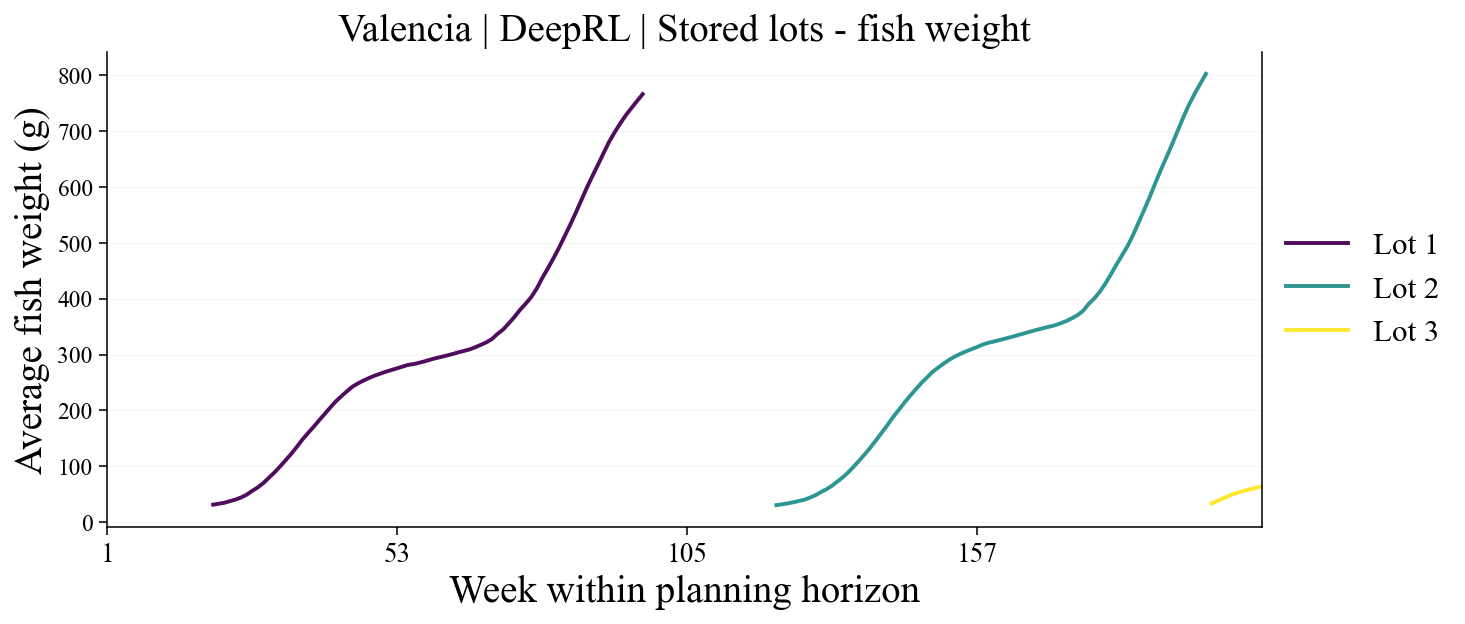

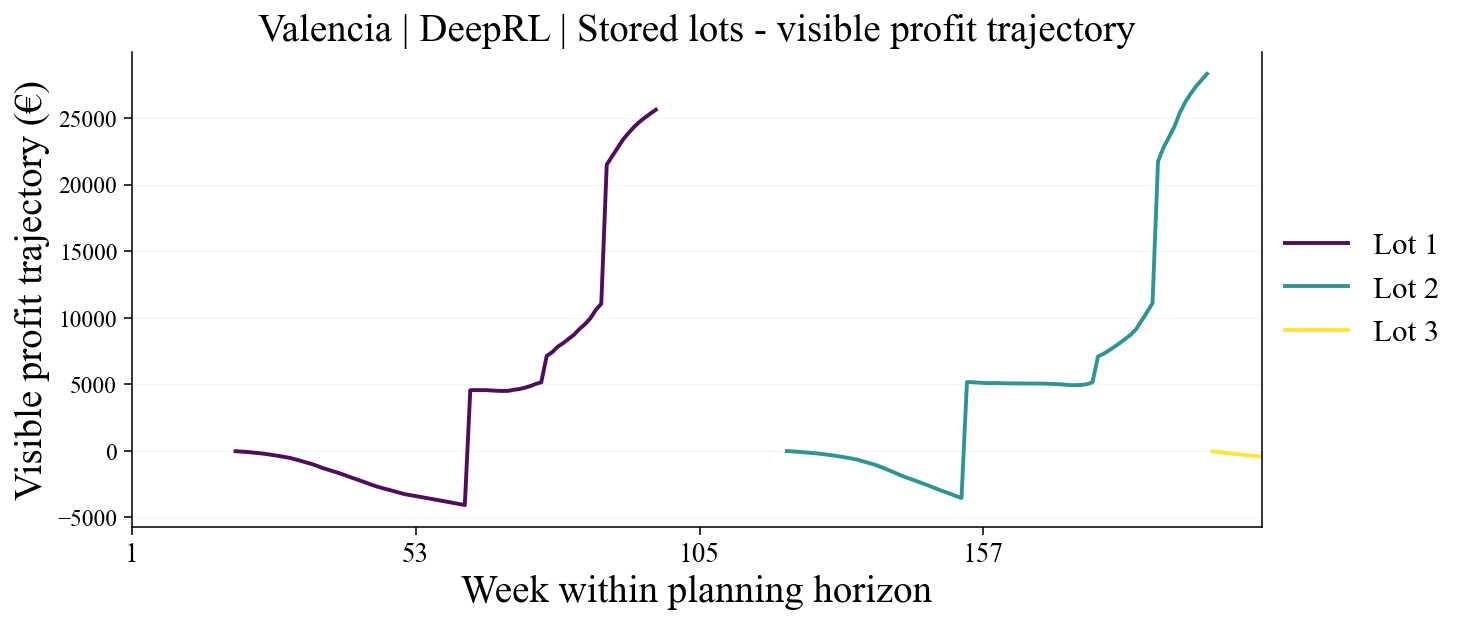

In [24]:
warnings.filterwarnings("ignore", category=UserWarning)

best_heuristic_params_by_region = {
    'Adriatico': {'start_temp_threshold': 17.0, 'target_weight_g': 600.0, 'lookahead_weeks': 3},
    'Valencia': {'start_temp_threshold': 16.5, 'target_weight_g': 600.0, 'lookahead_weeks': 3},
    'Grecia': {'start_temp_threshold': 15.0, 'target_weight_g': 900.0, 'lookahead_weeks': 3},
}

MODEL_PATHS = {
    "Valencia": "best_model_val_fixed_price_Valencia",
    "Adriatico": "best_model_val_fixed_price_Adriatico",
    "Grecia": "best_model_val_fixed_price_Grecia",
}

REGION_LABELS_EN = {
    "Valencia": "Valencia",
    "Adriatico": "Adriatic Sea",
    "Grecia": "Greece",
}

# Region and start week used for detailed plotting on TEST
REGION_TO_PLOT = "Valencia"
START_WEEK_TO_PLOT = 1
PLOT_MAX_HORIZON = 208

REGIONS = ["Grecia", "Valencia", "Adriatico"]
# ==========================================================
# 10) TEST EVALUATION: BEST HEURISTIC VS DEEPRL
# ==========================================================
detail_parts_test = []

for region in REGIONS:
    hp = best_heuristic_params_by_region[region]

    df_heur_test = evaluate_heuristic_policy_region(
        region=region,
        dataset_type="test",
        start_weeks=EVAL_START_WEEKS,
        target_weight_g=float(hp["target_weight_g"]),
        start_temp_threshold=float(hp["start_temp_threshold"]),
        lookahead_weeks=int(hp["lookahead_weeks"]),
        seed=SEED,
        max_weeks=EVAL_MAX_WEEKS,
    )

    df_rl_test = evaluate_deeprl_policy_region(
        region=region,
        dataset_type="test",
        model_path=MODEL_PATHS[region],
        start_weeks=EVAL_START_WEEKS,
        seed=SEED,
        max_weeks=EVAL_MAX_WEEKS,
    )

    detail_parts_test.extend([df_heur_test, df_rl_test])

df_detail_test = pd.concat(detail_parts_test, ignore_index=True)

df_summary_test = (
    df_detail_test
    .groupby(["Region", "Policy"], as_index=False)
    .agg(
        Mean_profit_eur=("Profit_eur", "mean"),
        Std_profit_eur=("Profit_eur", "std"),
        Min_profit_eur=("Profit_eur", "min"),
        Max_profit_eur=("Profit_eur", "max"),
        Median_profit_eur=("Profit_eur", "median"),
        Q1_profit_eur=("Profit_eur", lambda x: x.quantile(0.25)),
        Q3_profit_eur=("Profit_eur", lambda x: x.quantile(0.75)),
    )
    .sort_values(["Region", "Policy"])
    .reset_index(drop=True)
)

heur_mean = (
    df_summary_test[df_summary_test["Policy"] == "Heuristic"][["Region", "Mean_profit_eur"]]
    .rename(columns={"Mean_profit_eur": "Heuristic_mean_profit_eur"})
)
rl_mean = (
    df_summary_test[df_summary_test["Policy"] == "DeepRL"][["Region", "Mean_profit_eur"]]
    .rename(columns={"Mean_profit_eur": "DeepRL_mean_profit_eur"})
)

df_compare_test = heur_mean.merge(rl_mean, on="Region", how="inner")
df_compare_test["Delta_eur"] = (
    df_compare_test["DeepRL_mean_profit_eur"] - df_compare_test["Heuristic_mean_profit_eur"]
)
df_compare_test["Delta_pct_vs_heuristic"] = np.where(
    np.abs(df_compare_test["Heuristic_mean_profit_eur"]) > 1e-8,
    100.0 * df_compare_test["Delta_eur"] / np.abs(df_compare_test["Heuristic_mean_profit_eur"]),
    np.nan,
)

print("\n=== TEST SUMMARY BY REGION AND POLICY ===")
print(df_summary_test)

print("\n=== TEST: DEEPRL VS BEST HEURISTIC ===")
print(df_compare_test)


# ==========================================================
# 11) SAVE RESULTS
# ==========================================================
df_detail_test.to_csv("heuristic_vs_deeprl_test_detail.csv", index=False)
df_summary_test.to_csv("heuristic_vs_deeprl_test_summary.csv", index=False)
df_compare_test.to_csv("heuristic_vs_deeprl_test_compare.csv", index=False)

print("\n[CSV] Saved:")
print("  - heuristic_grid_search_validation.csv")
print("  - heuristic_vs_deeprl_test_detail.csv")
print("  - heuristic_vs_deeprl_test_summary.csv")
print("  - heuristic_vs_deeprl_test_compare.csv")


# ==========================================================
# 12) TEST PROFIT DISTRIBUTION VIOLIN + BOXPLOT
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_test_profit_violinplot(
    df_detail,
    regions,
    policy_order=("Heuristic", "DeepRL"),
):
    POLICY_COLORS = {
        "Heuristic": "#C75260",
        "DeepRL": "#4B74C9",
    }

    fig, ax = plt.subplots(figsize=(12.0, 6.0))

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    positions = []
    data = []
    violin_colors = []
    xtick_positions = []

    base_gap = 3
    inner_gap = 1.4

    for i, region in enumerate(regions):
        x_center = i * base_gap
        xtick_positions.append(x_center + inner_gap / 2.0)

        for j, policy in enumerate(policy_order):
            pos = x_center + j * inner_gap
            pos = float(pos)

            vals = (
                df_detail[
                    (df_detail["Region"] == region) &
                    (df_detail["Policy"] == policy)
                ]["Profit_eur"]
                .to_numpy(dtype=float)
            )

            positions.append(pos)
            data.append(vals)
            violin_colors.append(POLICY_COLORS[policy])

    # -------------------
    # VIOLIN
    # -------------------
    vp = ax.violinplot(
        data,
        positions=positions,
        widths=1.2,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, color in zip(vp["bodies"], violin_colors):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_linewidth(0.8)
        body.set_alpha(0.20)

    # -------------------
    # BOXPLOT
    # -------------------
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showmeans=True,
        meanline=False,
        whis=1.0,
        medianprops=dict(color="#3f3f3f", linewidth=1.4),
        whiskerprops=dict(color="#5f5f5f", linewidth=1.0),
        capprops=dict(color="#5f5f5f", linewidth=1.0),
        meanprops=dict(
            marker="s",
            markerfacecolor="white",
            markeredgecolor="#2f2f2f",
            markersize=6,
            markeredgewidth=1.0,
            zorder=6,
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="none",
            markeredgecolor="#4f4f4f",
            markersize=3.8,
            alpha=0.9,
            markeredgewidth=0.8,
        ),
    )

    for patch, color in zip(bp["boxes"], violin_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_linewidth(0.9)
        patch.set_alpha(0.28)

    # -------------------
    # RAW POINTS
    # -------------------
    rng = np.random.default_rng(123)
    for pos, vals, color in zip(positions, data, violin_colors):
        if len(vals) == 0:
            continue

        jitter = rng.uniform(-0.10, 0.10, size=len(vals))
        ax.scatter(
            np.full(len(vals), pos) + jitter,
            vals,
            s=8,
            color=color,
            alpha=0.40,
            zorder=2,
        )

    # -------------------
    # MEAN ANOTATION
    # -------------------
    for pos, vals in zip(positions, data):
        if len(vals) == 0:
            continue

        mean_val = np.mean(vals)
        median_val = np.median(vals)

        if mean_val >= median_val:
            offset = 12
            va = "bottom"
        else:
            offset = -12
            va = "top"

        ax.annotate(
            f"{mean_val:,.0f}",
            xy=(pos, mean_val),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=8.5,
            color="#2f2f2f",
            zorder=7,
            bbox=dict(
                boxstyle="round,pad=0.18",
                fc="white",
                ec="none",
                alpha=0.75
            ),
        )

    # -------------------
    # AXES
    # -------------------
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels([REGION_LABELS_EN.get(r, r) for r in regions],color="black")
    ax.set_ylabel("Profit (€)", color="black")

    ax.tick_params(axis="x", colors="black", length=0)
    ax.tick_params(axis="y", colors="black", length=4, width=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#B0B0B0")
    ax.spines["bottom"].set_color("#B0B0B0")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.grid(True, axis="y", linewidth=0.5, alpha=0.20, color="#A0A0A0")
    ax.grid(False, axis="x")

    # -------------------
    # LEGEND
    # -------------------
    legend_elements = [
        Patch(facecolor=POLICY_COLORS["Heuristic"], edgecolor=POLICY_COLORS["Heuristic"], alpha=0.22, label="Heuristic"),
        Patch(facecolor=POLICY_COLORS["DeepRL"], edgecolor=POLICY_COLORS["DeepRL"], alpha=0.22, label="DeepRL"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )

    plt.tight_layout()
    plt.show()

plot_test_profit_violinplot(
    df_detail=df_detail_test,
    regions=REGIONS,
    policy_order=("Heuristic", "DeepRL"),
)
# ==========================================================
# 14) SINGLE-POLICY PLOTTING
# ==========================================================
def plot_lots_single_policy(
    df_policy,
    policy_label,
    y_col,
    title,
    y_label,
    x_min,
    x_max,
    cmap_name="viridis",
    linestyle="-",
):


    fig, ax = plt.subplots(figsize=(10.8, 4.8))

    if df_policy is None or df_policy.empty or y_col not in df_policy.columns:
        ax.set_xlabel("Week within planning horizon")
        ax.set_ylabel(y_label)
        set_clean_time_axis(ax, x_min, x_max, step=52)
        style_axes(ax)
        ax.grid(True, axis="y", linewidth=0.45, alpha=0.15)
        ax.grid(False, axis="x")
        plt.tight_layout()
        plt.show()
        return

    cmap = plt.colormaps[cmap_name]

    # Renumber displayed lots consecutively in plotting order
    original_lots = sorted(df_policy["Lot"].unique().tolist())
    displayed_lot_map = {lot: idx + 1 for idx, lot in enumerate(original_lots)}

    # Leave space on the right for a non-overlapping legend
    if len(original_lots) > 0:
        plt.subplots_adjust(right=0.80)

    for i, lot in enumerate(original_lots):
        dfl = df_policy[df_policy["Lot"] == lot]
        if dfl.empty:
            continue

        color = cmap(i / max(1, len(original_lots) - 1))
        displayed_lot_id = displayed_lot_map[lot]

        ax.plot(
            dfl["Week"],
            dfl[y_col],
            linestyle=linestyle,
            linewidth=2.0,
            color=color,
            alpha=0.95,
            label=f"Lot {displayed_lot_id}",
        )

    set_clean_time_axis(ax, x_min, x_max, step=52)
    ax.set_xlabel("Week within planning horizon")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    style_axes(ax)
    ax.grid(True, axis="y", linewidth=0.45, alpha=0.15)
    ax.grid(False, axis="x")

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        borderaxespad=0.0,
        ncol=1,
        title=None,
    )

    plt.tight_layout()
    plt.show()


# ==========================================================
# 15) DETAILED TEST PLOTS FOR ONE REGION AND ONE START WEEK
# ==========================================================
hp_plot = best_heuristic_params_by_region[REGION_TO_PLOT]

heur_profit_eur, heur_blocks, df_heur_plot = simulate_heuristic_episode(
    region=REGION_TO_PLOT,
    dataset_type="test",
    start_week=START_WEEK_TO_PLOT,
    target_weight_g=float(hp_plot["target_weight_g"]),
    start_temp_threshold=float(hp_plot["start_temp_threshold"]),
    lookahead_weeks=int(hp_plot["lookahead_weeks"]),
    seed=SEED,
    max_weeks=PLOT_MAX_HORIZON,
    return_weekly_df=True,
)

rl_profit_eur, rl_blocks, df_rl_plot = simulate_deeprl_episode(
    region=REGION_TO_PLOT,
    dataset_type="test",
    model_path=MODEL_PATHS[REGION_TO_PLOT],
    start_week=START_WEEK_TO_PLOT,
    seed=SEED,
    max_weeks=PLOT_MAX_HORIZON,
    return_weekly_df=True,
)

print(f"\n=== TEST PLOT REGION: {REGION_TO_PLOT} | START WEEK: {START_WEEK_TO_PLOT} ===")
print(f"Best heuristic params: {hp_plot}")
print(f"Heuristic profit (€): {heur_profit_eur:,.2f} | Counted blocks: {heur_blocks}")
print(f"DeepRL profit   (€): {rl_profit_eur:,.2f} | Counted blocks: {rl_blocks}")

# ---------------------------
# HEURISTIC PLOTS
# ---------------------------
plot_lots_single_policy(
    df_policy=df_heur_plot,
    policy_label="Heuristic",
    y_col="Temperature",
    title=f"{REGION_TO_PLOT} | Heuristic | Stored lots - temperature",
    y_label="Temperature (°C)",
    x_min=START_WEEK_TO_PLOT,
    x_max=START_WEEK_TO_PLOT + PLOT_MAX_HORIZON - 1,
    cmap_name="viridis",
)

plot_lots_single_policy(
    df_policy=df_heur_plot,
    policy_label="Heuristic",
    y_col="Weight_end_g",
    title=f"{REGION_TO_PLOT} | Heuristic | Stored lots - fish weight",
    y_label="Average fish weight (g)",
    x_min=START_WEEK_TO_PLOT,
    x_max=START_WEEK_TO_PLOT + PLOT_MAX_HORIZON - 1,
    cmap_name="viridis",
)

plot_lots_single_policy(
    df_policy=df_heur_plot,
    policy_label="Heuristic",
    y_col="Profit_potential_eur",
    title=f"{REGION_TO_PLOT} | Heuristic | Stored lots - visible profit trajectory",
    y_label="Visible profit trajectory (€)",
    x_min=START_WEEK_TO_PLOT,
    x_max=START_WEEK_TO_PLOT + PLOT_MAX_HORIZON - 1,
    cmap_name="viridis",
)

# ---------------------------
# DEEPRL PLOTS
# ---------------------------
plot_lots_single_policy(
    df_policy=df_rl_plot,
    policy_label="DeepRL",
    y_col="Temperature",
    title=f"{REGION_TO_PLOT} | DeepRL | Stored lots - temperature",
    y_label="Temperature (°C)",
    x_min=START_WEEK_TO_PLOT,
    x_max=START_WEEK_TO_PLOT + PLOT_MAX_HORIZON - 1,
    cmap_name="viridis",
)

plot_lots_single_policy(
    df_policy=df_rl_plot,
    policy_label="DeepRL",
    y_col="Weight_end_g",
    title=f"{REGION_TO_PLOT} | DeepRL | Stored lots - fish weight",
    y_label="Average fish weight (g)",
    x_min=START_WEEK_TO_PLOT,
    x_max=START_WEEK_TO_PLOT + PLOT_MAX_HORIZON - 1,
    cmap_name="viridis",
)

plot_lots_single_policy(
    df_policy=df_rl_plot,
    policy_label="DeepRL",
    y_col="Profit_potential_eur",
    title=f"{REGION_TO_PLOT} | DeepRL | Stored lots - visible profit trajectory",
    y_label="Visible profit trajectory (€)",
    x_min=START_WEEK_TO_PLOT,
    x_max=START_WEEK_TO_PLOT + PLOT_MAX_HORIZON - 1,
    cmap_name="viridis",
)

# **Extra: DeepRL Lot-Level Analysis**

This additional analysis examines the DeepRL policy in detail for a selected region and starting week.

The trained policy is simulated over the test horizon, and all generated production lots are identified together with their economic contribution. For visualization and reporting, only **profitable lots** are retained, making the plots focused on the effective production cycles selected by the agent.

For each profitable lot, separate trajectories are plotted for:

- **SST**
- **average fish weight**
- **potential profit**

The plots use the same lot color convention as the Gantt chart and include a calendar-style month band to improve temporal interpretation.

A CSV summary is also exported for the profitable lots, reporting key variables at regular intervals, including temperature, fish weight, surviving population, potential profit, and total block profit. Finally, non-profitable lots are listed separately with their start week, end week, duration, and economic contribution, supporting a more detailed discussion of the agent’s decisions.


=== TEST PLOT REGION: Adriatico | START WEEK: 24 ===
DeepRL total profit (€): 50,432.23
Counted blocks before profitability filter: [78, 78, 5]

=== ALL STORED LOTS (before filtering) ===
   Lot  Sowing_start_week  End_week  Sowing_start_horizon_week  \
0    1                 24       101                          1   
1    7                125       202                        102   
2   17                227       231                        204   

   End_horizon_week  Visible_duration_weeks  Block_profit_eur  Profitable  \
0                78                      78      23640.659140        True   
1               179                      78      25007.427785        True   
2               208                       5       1784.146665        True   

     Lot_type  
0  Profitable  
1  Profitable  
2  Profitable  

Profitable lots kept: [1, 7, 17]
Profitable lots finally represented: [1, 7, 17]


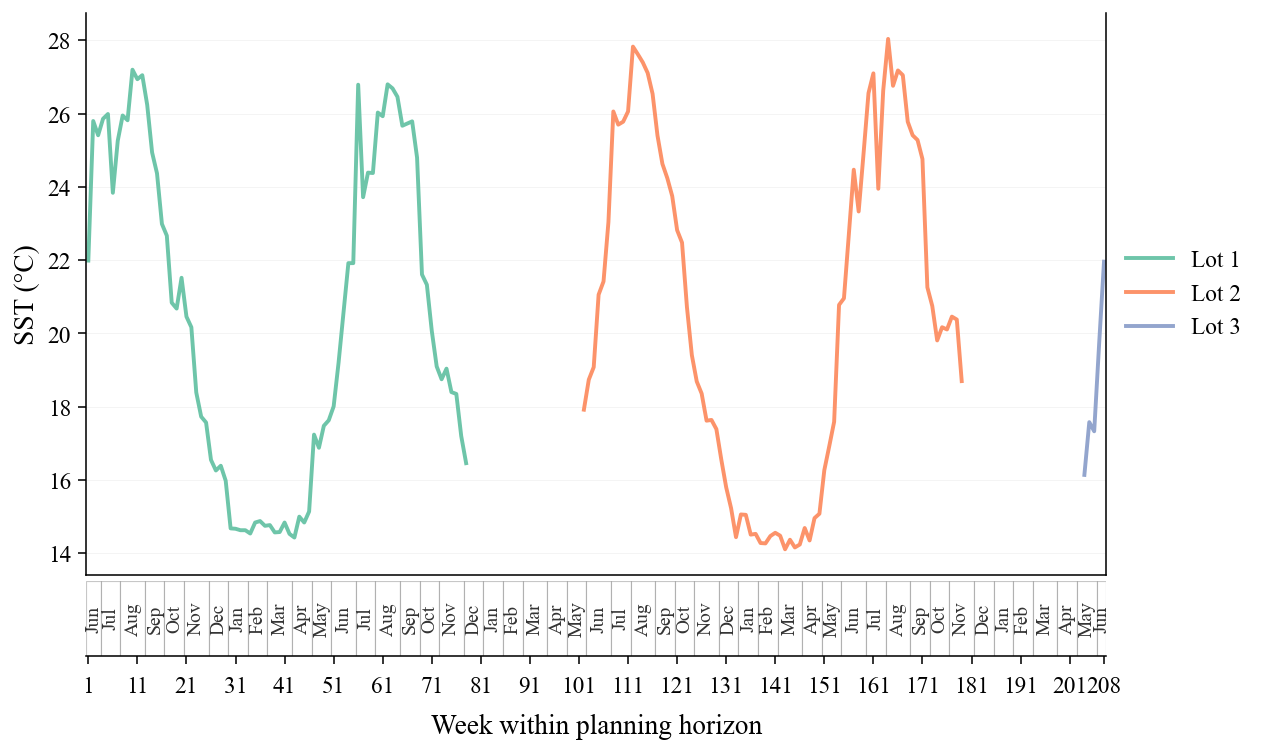

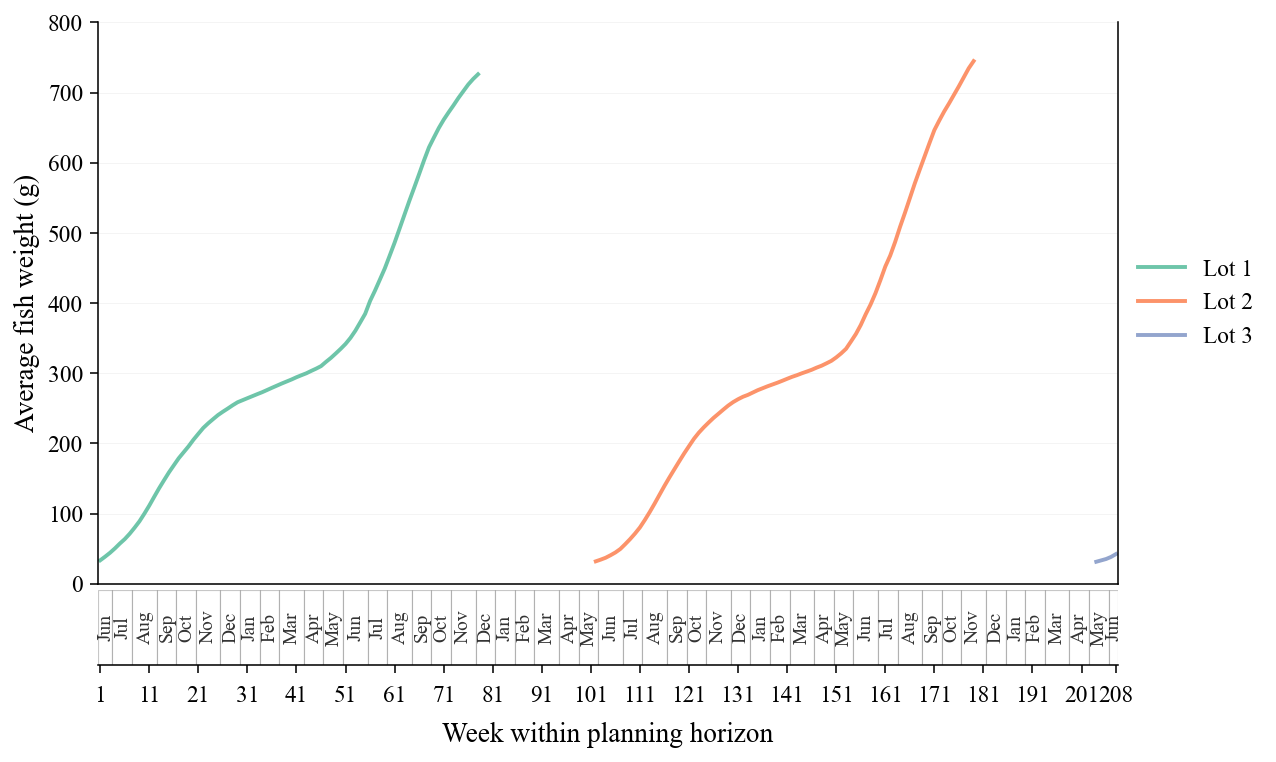

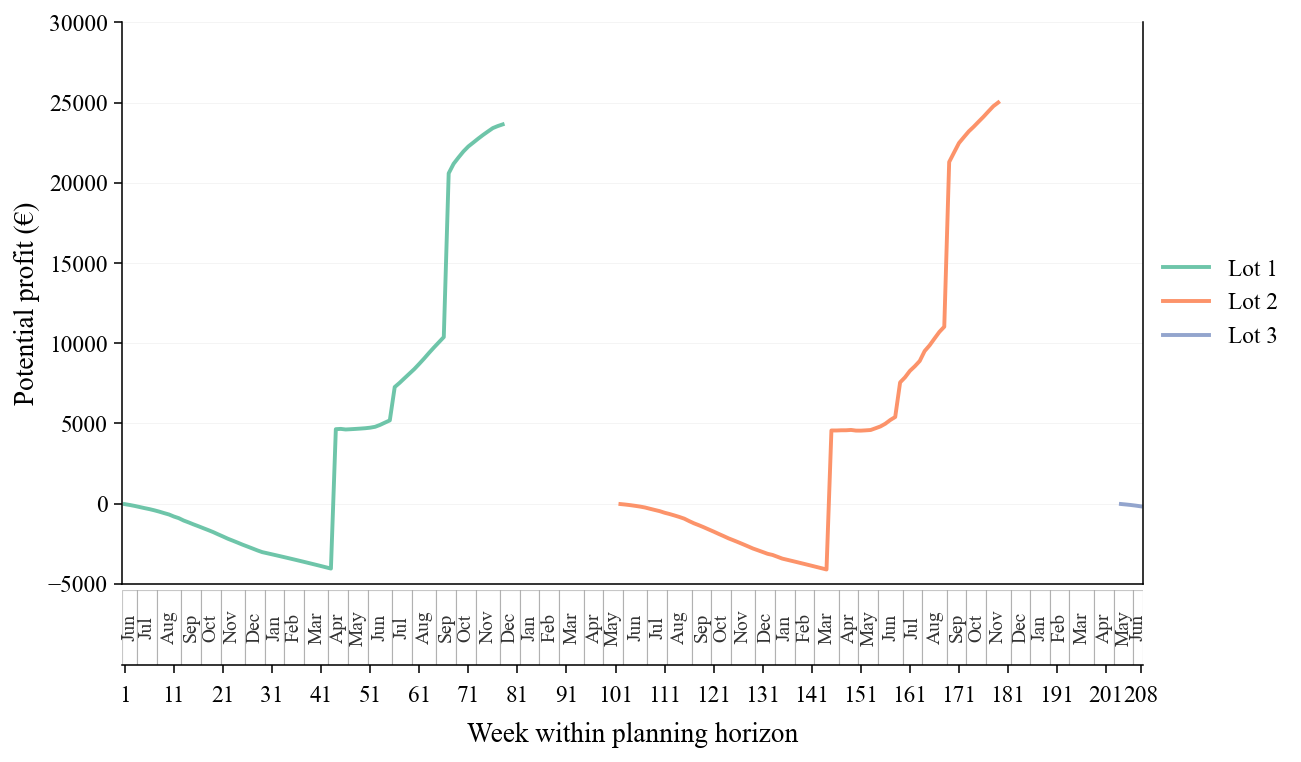


[CSV] Saved: deeprl_profitable_lots_summary_Adriatico_startweek_24.csv
    Lot  Sowing_start_week  Sowing_start_horizon_week  Week_within_lot  \
0     1                 24                          1                1   
1     1                 24                          1                6   
2     1                 24                          1               12   
3     1                 24                          1               18   
4     1                 24                          1               24   
5     1                 24                          1               30   
6     1                 24                          1               36   
7     1                 24                          1               42   
8     1                 24                          1               48   
9     1                 24                          1               54   
10    1                 24                          1               60   
11    1                 24              

In [25]:
# ==========================================================
# DEEPRL ONLY - PROFITABLE LOTS PLOTS + CSV SUMMARY
# Uses the SAME DeepRL episode simulation, but:
#   1) keeps ONLY profitable lots for plotting/CSV
#   2) uses EXACTLY the SAME lot colors as the Gantt
#   3) plots against week within planning horizon (1..208)
#   4) shows a separate calendar-like month band BELOW the plot
#      so it never overlaps with the data
# At the end, it also prints the sowing start / end / duration of
# non-profitable lots for article discussion.
# ==========================================================

warnings.filterwarnings("ignore", category=UserWarning)

# ----------------------------------------------------------
# CONFIG
# ----------------------------------------------------------
REGION_TO_PLOT = "Adriatico"
START_WEEK_TO_PLOT = 24
PLOT_MAX_HORIZON = 208
CSV_NAME = f"deeprl_profitable_lots_summary_{REGION_TO_PLOT}_startweek_{START_WEEK_TO_PLOT}.csv"
SUMMARY_STEP_WEEKS = 6

MODEL_PATHS = {
    "Valencia": "best_model_val_fixed_price_Valencia",
    "Adriatico": "best_model_val_fixed_price_Adriatico",
    "Grecia": "best_model_val_fixed_price_Grecia",
}

# ----------------------------------------------------------
# MONTH NAME HELPERS
# ----------------------------------------------------------
MONTHS_IDX_TO_EN = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}

MONTHS_IDX_TO_EN_SHORT = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

# ----------------------------------------------------------
# SAME COLOR LOGIC AS GANTT
# ----------------------------------------------------------
def lighten_color(color, amount=0.7):
    """
    Lighten a color by mixing it with white.
    Same helper used in the Gantt.
    """
    c = np.array(mcolors.to_rgb(color), dtype=float)
    white = np.array([1.0, 1.0, 1.0], dtype=float)
    return tuple(c + (white - c) * float(amount))


def get_gantt_lot_color(displayed_lot_id):
    """
    Exact same color logic as the Gantt.
    """
    base_cmap = plt.colormaps["Set2"]
    lote_id_for_color = int(displayed_lot_id) - 1
    base_color = base_cmap(lote_id_for_color % base_cmap.N)
    color = lighten_color(base_color, amount=0.00)
    return color

# ----------------------------------------------------------
# TIME HELPERS
# ----------------------------------------------------------
def natural_week_to_week_of_year(week_natural):
    return int(((int(week_natural) - 1) % 52) + 1)


def week_of_year_to_month_idx(week_of_year):
    """
    Same approximate mapping used in the environment.
    """
    if week_of_year <= 4:
        return 1
    elif week_of_year <= 8:
        return 2
    elif week_of_year <= 13:
        return 3
    elif week_of_year <= 17:
        return 4
    elif week_of_year <= 21:
        return 5
    elif week_of_year <= 26:
        return 6
    elif week_of_year <= 30:
        return 7
    elif week_of_year <= 35:
        return 8
    elif week_of_year <= 39:
        return 9
    elif week_of_year <= 43:
        return 10
    elif week_of_year <= 48:
        return 11
    else:
        return 12


def natural_week_to_month_en(week_natural, reference_year=2025):
    week_of_year = natural_week_to_week_of_year(week_natural)
    month_idx = week_of_year_to_month_idx(week_of_year)
    return MONTHS_IDX_TO_EN[month_idx], week_of_year


def natural_week_to_month_en_short(week_natural, reference_year=2025):
    month_en, week_of_year = natural_week_to_month_en(
        week_natural,
        reference_year=reference_year
    )
    month_idx = week_of_year_to_month_idx(week_of_year)
    return MONTHS_IDX_TO_EN_SHORT[month_idx], week_of_year


def horizon_to_natural_week(horizon_week, start_week_natural):
    return int(start_week_natural + horizon_week - 1)


def set_clean_horizon_axis(
    ax,
    x_min,
    x_max,
    step=10,
    tick_fontsize=10,
):
    ticks = list(range(int(x_min), int(x_max) + 1, int(step)))
    if ticks[-1] != int(x_max):
        ticks.append(int(x_max))

    ax.set_xlim(x_min - 0.5, x_max + 0.5)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontsize=tick_fontsize)


def build_month_segments(start_week_natural, x_min, x_max):
    """
    Build contiguous x-intervals belonging to the same month.
    Returns a list of dicts with:
      - x0, x1
      - month_idx
      - month_label
    """
    segments = []

    current_x0 = int(x_min)
    current_nat = horizon_to_natural_week(current_x0, start_week_natural)
    current_month_idx = week_of_year_to_month_idx(
        natural_week_to_week_of_year(current_nat)
    )

    for h in range(int(x_min) + 1, int(x_max) + 1):
        nat_week = horizon_to_natural_week(h, start_week_natural)
        month_idx = week_of_year_to_month_idx(
            natural_week_to_week_of_year(nat_week)
        )

        if month_idx != current_month_idx:
            segments.append({
                "x0": current_x0,
                "x1": h - 1,
                "month_idx": current_month_idx,
                "month_label": MONTHS_IDX_TO_EN_SHORT[current_month_idx],
            })
            current_x0 = h
            current_month_idx = month_idx

    segments.append({
        "x0": current_x0,
        "x1": int(x_max),
        "month_idx": current_month_idx,
        "month_label": MONTHS_IDX_TO_EN_SHORT[current_month_idx],
    })

    return segments


def add_month_calendar_band_axis(
    ax_band,
    start_week_natural,
    x_min,
    x_max,
    month_fontsize=8,
):
    """
    Draw the month band in a completely separate axis below the plot.
    This avoids any overlap with the actual data.
    """
    month_segments = build_month_segments(start_week_natural, x_min, x_max)

    ax_band.set_xlim(x_min - 0.5, x_max + 0.5)
    ax_band.set_ylim(0, 1)

    # Hide y axis
    ax_band.set_yticks([])
    ax_band.set_ylabel("")

    # Keep only bottom x ticks in this lower axis
    ticks = list(range(int(x_min), int(x_max) + 1, 10))
    if ticks[-1] != int(x_max):
        ticks.append(int(x_max))

    ax_band.set_xticks(ticks)
    ax_band.set_xticklabels([str(t) for t in ticks], fontsize=month_fontsize + 2)

    # Draw month rectangles
    for seg in month_segments:
        x0 = seg["x0"] - 0.5
        width = seg["x1"] - seg["x0"] + 1

        rect = Rectangle(
            (x0, 0.0),
            width,
            1.0,
            facecolor=(1.0, 1.0, 1.0, 1.0),
            edgecolor=(0, 0, 0, 0.22),
            linewidth=0.6,
            zorder=1,
        )
        ax_band.add_patch(rect)

        x_center = seg["x0"] + (seg["x1"] - seg["x0"]) / 2.0
        ax_band.text(
            x_center,
            0.5,
            seg["month_label"],
            ha="center",
            va="center",
            rotation=90,
            fontsize=month_fontsize,
            color=(0, 0, 0, 0.80),
            zorder=2,
        )

    # Style for lower band axis
    ax_band.spines["top"].set_visible(False)
    ax_band.spines["right"].set_visible(False)
    ax_band.spines["left"].set_visible(False)
    ax_band.spines["bottom"].set_linewidth(0.8)
    ax_band.tick_params(axis="x", which="major", pad=6, length=4)
    ax_band.grid(False)

# ----------------------------------------------------------
# PLOTTING
# ----------------------------------------------------------
def plot_lots_single_policy(
    df_policy,
    policy_label,
    y_col,
    title,
    y_label,
    x_min,
    x_max,
    start_week_natural,
    linestyle="-",
    tick_fontsize=10,
    label_fontsize=12,
    title_fontsize=12,
    legend_fontsize=10,
    reference_year=2025,
):
    """
    Plot all stored lots of a single policy in an independent figure.

    Main change:
      - The month band is now drawn in a separate lower axis,
        so the data area starts exactly above it and nothing overlaps.
    """

    fig = plt.figure(figsize=(10.8, 5.4))
    gs = fig.add_gridspec(
        nrows=2,
        ncols=1,
        height_ratios=[12, 1.6],
        hspace=0.02
    )

    ax = fig.add_subplot(gs[0])
    ax_band = fig.add_subplot(gs[1], sharex=ax)

    if df_policy is None or df_policy.empty or y_col not in df_policy.columns:
        ax.set_ylabel(y_label, fontsize=label_fontsize)
        ax.tick_params(axis="y", labelsize=tick_fontsize)
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

        set_clean_horizon_axis(
            ax=ax,
            x_min=x_min,
            x_max=x_max,
            step=10,
            tick_fontsize=tick_fontsize,
        )

        add_month_calendar_band_axis(
            ax_band=ax_band,
            start_week_natural=start_week_natural,
            x_min=x_min,
            x_max=x_max,
            month_fontsize=max(7, tick_fontsize - 2),
        )

        ax_band.set_xlabel(
            "Week within planning horizon",
            fontsize=label_fontsize,
            labelpad=8
        )

        style_axes(ax)

        ax.grid(True, axis="y", linewidth=0.45, alpha=0.15)
        ax.grid(False, axis="x")

        plt.subplots_adjust(right=0.80, bottom=0.12, top=0.97)
        plt.show()
        return

    # Renumber displayed lots consecutively in plotting order
    original_lots = sorted(df_policy["Lot"].unique().tolist())
    displayed_lot_map = {lot: idx + 1 for idx, lot in enumerate(original_lots)}

    for lot in original_lots:
        dfl = df_policy[df_policy["Lot"] == lot]
        if dfl.empty:
            continue

        displayed_lot_id = displayed_lot_map[lot]
        color = get_gantt_lot_color(displayed_lot_id)

        ax.plot(
            dfl["Horizon_week"],
            dfl[y_col],
            linestyle=linestyle,
            linewidth=2.0,
            color=color,
            alpha=0.95,
            label=f"Lot {displayed_lot_id}",
        )

    set_clean_horizon_axis(
        ax=ax,
        x_min=x_min,
        x_max=x_max,
        step=10,
        tick_fontsize=tick_fontsize,
    )

    # Upper axis: no x labels, only data
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", labelsize=tick_fontsize)

    # Lower axis: months + week numbers
    add_month_calendar_band_axis(
        ax_band=ax_band,
        start_week_natural=start_week_natural,
        x_min=x_min,
        x_max=x_max,
        month_fontsize=max(7, tick_fontsize - 2),
    )

    ax_band.set_xlabel(
        "Week within planning horizon",
        fontsize=label_fontsize,
        labelpad=8
    )

    ax.set_ylabel(y_label, fontsize=label_fontsize)
    ax.set_title(title, fontsize=title_fontsize)

    style_axes(ax)

    if y_col == "Weight_end_g":
        ax.set_ylim(0, 800)
        ax.set_yticks(np.arange(0, 801, 100))

    elif y_col == "Profit_potential_eur":
        ax.set_ylim(-5000, 30000)
        ax.set_yticks(np.arange(-5000, 30001, 5000))

    ax.grid(True, axis="y", linewidth=0.45, alpha=0.15)
    ax.grid(False, axis="x")

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        borderaxespad=0.0,
        ncol=1,
        title=None,
        fontsize=legend_fontsize,
    )

    plt.subplots_adjust(right=0.80, bottom=0.12, top=0.97)
    plt.show()

# ----------------------------------------------------------
# 1) SIMULATE THE REAL DEEPRL POLICY EPISODE
# ----------------------------------------------------------
rl_profit_eur, rl_blocks, df_rl_plot = simulate_deeprl_episode(
    region=REGION_TO_PLOT,
    dataset_type="test",
    model_path=MODEL_PATHS[REGION_TO_PLOT],
    start_week=START_WEEK_TO_PLOT,
    seed=SEED,
    max_weeks=PLOT_MAX_HORIZON,
    return_weekly_df=True,
)

print(f"\n=== TEST PLOT REGION: {REGION_TO_PLOT} | START WEEK: {START_WEEK_TO_PLOT} ===")
print(f"DeepRL total profit (€): {rl_profit_eur:,.2f}")
print(f"Counted blocks before profitability filter: {rl_blocks}")

# ----------------------------------------------------------
# 2) BASIC VALIDATION
# ----------------------------------------------------------
if df_rl_plot is None or df_rl_plot.empty:
    raise ValueError("df_rl_plot is empty. The DeepRL episode did not store any lots.")

required_cols = [
    "Lot",
    "Week",
    "Block_profit_eur",
    "Temperature",
    "Weight_end_g",
    "Profit_potential_eur",
    "Population",
]
for col in required_cols:
    if col not in df_rl_plot.columns:
        raise ValueError(f"Column '{col}' not found in df_rl_plot.")

df_rl_plot = df_rl_plot.copy().sort_values(["Lot", "Week"]).reset_index(drop=True)

# Add week within planning horizon (1..PLOT_MAX_HORIZON)
df_rl_plot["Horizon_week"] = (df_rl_plot["Week"] - START_WEEK_TO_PLOT + 1).astype(int)

# Safety filter in case something extends beyond the intended horizon
df_rl_plot = df_rl_plot[
    (df_rl_plot["Horizon_week"] >= 1) & (df_rl_plot["Horizon_week"] <= PLOT_MAX_HORIZON)
].copy().reset_index(drop=True)

# ----------------------------------------------------------
# 3) BUILD FULL LOT SUMMARY (ALL LOTS: PROFITABLE + NON-PROFITABLE)
# ----------------------------------------------------------
df_lot_summary_all = (
    df_rl_plot
    .groupby("Lot", as_index=False)
    .agg(
        Sowing_start_week=("Week", "min"),
        End_week=("Week", "max"),
        Sowing_start_horizon_week=("Horizon_week", "min"),
        End_horizon_week=("Horizon_week", "max"),
        Visible_duration_weeks=("Week", "count"),
        Block_profit_eur=("Block_profit_eur", "first"),
    )
    .sort_values("Lot")
    .reset_index(drop=True)
)

df_lot_summary_all["Profitable"] = df_lot_summary_all["Block_profit_eur"] > 0.0
df_lot_summary_all["Lot_type"] = np.where(
    df_lot_summary_all["Profitable"],
    "Profitable",
    "Non-profitable"
)

print("\n=== ALL STORED LOTS (before filtering) ===")
print(df_lot_summary_all)

# ----------------------------------------------------------
# 4) KEEP ONLY PROFITABLE LOTS FOR PLOTTING / CSV
# ----------------------------------------------------------
profitable_lots = (
    df_lot_summary_all.loc[df_lot_summary_all["Profitable"], "Lot"]
    .astype(int)
    .tolist()
)

df_rl_plot_prof = (
    df_rl_plot[df_rl_plot["Lot"].isin(profitable_lots)]
    .copy()
    .sort_values(["Lot", "Week"])
    .reset_index(drop=True)
)

print(f"\nProfitable lots kept: {profitable_lots}")

# ----------------------------------------------------------
# 5) SAFETY CHECK: AT MOST 4 PROFITABLE LOTS
# ----------------------------------------------------------
unique_profitable_lots = sorted(df_rl_plot_prof["Lot"].unique().tolist())

if len(unique_profitable_lots) > 4:
    print(
        f"[WARNING] {len(unique_profitable_lots)} profitable lots were found. "
        f"Keeping only the first 4 stored lots to match the intended horizon interpretation."
    )
    kept_lots = unique_profitable_lots[:4]

    df_rl_plot_prof = (
        df_rl_plot_prof[df_rl_plot_prof["Lot"].isin(kept_lots)]
        .copy()
        .sort_values(["Lot", "Week"])
        .reset_index(drop=True)
    )
    unique_profitable_lots = kept_lots

print(f"Profitable lots finally represented: {unique_profitable_lots}")

# ----------------------------------------------------------
# 6) SAME STYLE PLOTS (ONLY IF THERE ARE PROFITABLE LOTS)
# ----------------------------------------------------------
if len(unique_profitable_lots) > 0:
    plot_lots_single_policy(
        df_policy=df_rl_plot_prof,
        policy_label="DeepRL",
        y_col="Temperature",
        title="",
        y_label="SST (°C)",
        x_min=1,
        x_max=PLOT_MAX_HORIZON,
        start_week_natural=START_WEEK_TO_PLOT,
        tick_fontsize=12,
        label_fontsize=14,
        title_fontsize=14,
        legend_fontsize=12,
    )

    plot_lots_single_policy(
        df_policy=df_rl_plot_prof,
        policy_label="DeepRL",
        y_col="Weight_end_g",
        title="",
        y_label="Average fish weight (g)",
        x_min=1,
        x_max=PLOT_MAX_HORIZON,
        start_week_natural=START_WEEK_TO_PLOT,
        tick_fontsize=12,
        label_fontsize=14,
        title_fontsize=14,
        legend_fontsize=12,
    )

    plot_lots_single_policy(
        df_policy=df_rl_plot_prof,
        policy_label="DeepRL",
        y_col="Profit_potential_eur",
        title="",
        y_label="Potential profit (€)",
        x_min=1,
        x_max=PLOT_MAX_HORIZON,
        start_week_natural=START_WEEK_TO_PLOT,
        tick_fontsize=12,
        label_fontsize=14,
        title_fontsize=14,
        legend_fontsize=12,
    )

else:
    print("\n[INFO] No profitable lots were found for plotting.")

# ----------------------------------------------------------
# 7) CSV SUMMARY EVERY 6 WEEKS (+ START WEEK + FINAL WEEK)
#    Only for profitable lots
# ----------------------------------------------------------
summary_parts = []

for lot in unique_profitable_lots:
    dfl = (
        df_rl_plot_prof[df_rl_plot_prof["Lot"] == lot]
        .copy()
        .sort_values("Week")
        .reset_index(drop=True)
    )

    if dfl.empty:
        continue

    n = len(dfl)
    sowing_start_week = int(dfl["Week"].iloc[0])
    sowing_start_horizon_week = int(dfl["Horizon_week"].iloc[0])

    keep_idx = [0]
    keep_idx.extend(list(range(SUMMARY_STEP_WEEKS - 1, n, SUMMARY_STEP_WEEKS)))
    if (n - 1) not in keep_idx:
        keep_idx.append(n - 1)

    keep_idx = sorted(set(keep_idx))
    dfl_keep = dfl.iloc[keep_idx].copy()

    dfl_keep["Week_within_lot"] = [idx + 1 for idx in keep_idx]
    dfl_keep["Sowing_start_week"] = sowing_start_week
    dfl_keep["Sowing_start_horizon_week"] = sowing_start_horizon_week

    month_info = dfl_keep["Week"].apply(natural_week_to_month_en)
    dfl_keep["Moment_of_year"] = [x[0] for x in month_info]
    dfl_keep["Week_of_year"] = [x[1] for x in month_info]

    dfl_keep["Survivors_end_floor"] = np.floor(dfl_keep["Population"]).astype(int)

    dfl_keep["Block_profit_eur"] = dfl_keep["Block_profit_eur"].astype(float).round(2)
    dfl_keep["Temperature"] = dfl_keep["Temperature"].astype(float).round(2)
    dfl_keep["Weight_end_g"] = dfl_keep["Weight_end_g"].astype(float).round(2)
    dfl_keep["Profit_potential_eur"] = dfl_keep["Profit_potential_eur"].astype(float).round(2)

    dfl_keep = dfl_keep[[
        "Lot",
        "Sowing_start_week",
        "Sowing_start_horizon_week",
        "Week_within_lot",
        "Horizon_week",
        "Week",
        "Week_of_year",
        "Moment_of_year",
        "Temperature",
        "Weight_end_g",
        "Survivors_end_floor",
        "Profit_potential_eur",
        "Block_profit_eur",
    ]].rename(columns={
        "Horizon_week": "Week_within_horizon",
        "Week": "Natural_week_index",
        "Temperature": "Temperature_C",
        "Weight_end_g": "Fish_weight_end_g",
        "Profit_potential_eur": "Potential_profit_end_eur",
    })

    summary_parts.append(dfl_keep)

if len(summary_parts) > 0:
    df_rl_summary_csv = pd.concat(summary_parts, ignore_index=True)
    df_rl_summary_csv.to_csv(CSV_NAME, index=False)

    print(f"\n[CSV] Saved: {CSV_NAME}")
    print(df_rl_summary_csv)
else:
    df_rl_summary_csv = pd.DataFrame()
    print("\n[INFO] No profitable lots available for CSV export.")

# ----------------------------------------------------------
# 8) PROFITABLE LOTS: BLOCK-LEVEL CONTRIBUTION
# ----------------------------------------------------------
if len(unique_profitable_lots) > 0:
    df_block_profit_table = (
        df_rl_plot_prof.groupby("Lot", as_index=False)["Block_profit_eur"]
        .first()
        .sort_values("Lot")
        .reset_index(drop=True)
    )

    print("\n=== PROFITABLE LOTS: BLOCK-LEVEL CONTRIBUTION (€) ===")
    print(df_block_profit_table)

# ----------------------------------------------------------
# 9) FINAL EXTRA SUMMARY:
#    print sowing start / end / duration of NON-PROFITABLE lots
# ----------------------------------------------------------
df_non_profitable_lots = (
    df_lot_summary_all[~df_lot_summary_all["Profitable"]]
    .copy()
    .sort_values("Lot")
    .reset_index(drop=True)
)

print("\n=== NON-PROFITABLE LOTS: SOWING START / END / DURATION ===")
if df_non_profitable_lots.empty:
    print("No non-profitable lots were stored in this DeepRL episode.")
else:
    for _, row in df_non_profitable_lots.iterrows():
        lot_id = int(row["Lot"])
        sow_week = int(row["Sowing_start_week"])
        end_week = int(row["End_week"])
        sow_horizon_week = int(row["Sowing_start_horizon_week"])
        end_horizon_week = int(row["End_horizon_week"])
        duration = int(row["Visible_duration_weeks"])
        block_profit = float(row["Block_profit_eur"])

        print(
            f"Lot {lot_id}: "
            f"sowing start week = {sow_week} (horizon {sow_horizon_week}), "
            f"end week = {end_week} (horizon {end_horizon_week}), "
            f"duration = {duration} weeks, "
            f"block profit = {block_profit:,.2f} €"
        )

# ----------------------------------------------------------
# 10) OPTIONAL: PRINT ALL LOTS IN ARTICLE-FRIENDLY FORMAT
# ----------------------------------------------------------
print("\n=== ALL LOTS: ARTICLE-FRIENDLY SUMMARY ===")
for _, row in df_lot_summary_all.iterrows():
    lot_id = int(row["Lot"])
    sow_week = int(row["Sowing_start_week"])
    end_week = int(row["End_week"])
    sow_horizon_week = int(row["Sowing_start_horizon_week"])
    end_horizon_week = int(row["End_horizon_week"])
    duration = int(row["Visible_duration_weeks"])
    block_profit = float(row["Block_profit_eur"])
    lot_type = row["Lot_type"]

    print(
        f"Lot {lot_id} | {lot_type} | "
        f"start={sow_week} (h={sow_horizon_week}), "
        f"end={end_week} (h={end_horizon_week}), "
        f"duration={duration} weeks, "
        f"block_profit={block_profit:,.2f} €"
    )